This is the main block of the analysis for the _radon @ LPR paper_.
<br>
Here, we compute the amount of radon inside the detector, as well as the amount of Rn-induced $^{214}\text{Bi}$ activity at the cathode.

-----

Data collection conditions for $\alpha$ runs:

- **HV @ Cathode = 23 kV**
- **HV @ EL Gate = 7.5 kV**
- **Pressure  = 4 bar**

-----

The final two datasets are stored on the Gluon servers.
<br>
You can find them in the folder: _/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/pkl/_

- **Rn_background** dataset has included the $S2w = (50,\,250)\,\mu\text{s}$ cut.
- **s2w_no_cuts** is the most alpha populated sample, perfect for spatial distribution. No lower cuts were made on $S2w$.

**NOTE:** _the current version of this notebook is made for working with s2w_no_cuts dataset!_

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from   iminuit import Minuit
from   iminuit.cost import LeastSquares
from   matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from   PIL import Image
import scipy
from   scipy.optimize import curve_fit
from   scipy.signal import find_peaks

# Styling Plot
# crudo.pt.ccortesp_plot_style()
crudo.pt.papers_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

## Global Definitions

The subsequent definition of global variables is a roadmap through the following $\alpha$ analysis for the $^{222}Rn$-induced background

In [ ]:
# Dataframe name to analyze
DF_NAME = 's2w_no_cuts'

# Trigger rate for Rn periods from the trigger fit
TRG_RATE_HIGH_RN_CV, TRG_RATE_HIGH_RN_ERR = 0.0, 0.0
TRG_RATE_LOW_RN_CV, TRG_RATE_LOW_RN_ERR   = 0.0, 0.0

# Lifetime
LIFETIME = 0.0  # In [μs]

# Run number definition of High-Rn and Low-Rn periods
HIGH_RN_RUNS = [14739]
LOW_RN_RUNS  = [14834, 14835, 14837, 14838, 14839, 14840]

# Alpha threshold
ALPHA_THRESHOLD = None       # In [PE]. It can be None or 900 e.g

# Directory with important information
ANA_DATA = {'High_Rn': {},  'Low_Rn' : {}}

# Alpha trigger count efficiency (not all the OK triggers are alphas events) ---> numbers given by Pau!
ALPHA_TRG_EFF_HIGH = 0.7542
ALPHA_TRG_EFF_LOW  = 0.3056
TRG_EFF_ERR = 0.1   # Relative error

# Detector volumes in [m³]
EL_GAP_VOLUME, _ = crudo.pt.selection_volume(crudo.pt.EL_hei, 1, crudo.pt.EL_rad, 1)
EL_GAP_VOLUME *= 1e-9 
DRIFT_VOLUME, _  = crudo.pt.selection_volume(crudo.pt.N100_hei, 1, crudo.pt.N100_rad, 1)    # 
DRIFT_VOLUME *= 1e-9
BUFFER_VOLUME, _ = crudo.pt.selection_volume(crudo.pt.Buffer_hei, 1, crudo.pt.N100_rad, 1)
BUFFER_VOLUME *= 1e-9
print(f'EL gap volume: {EL_GAP_VOLUME:.4f} m³')
print(f'Drift volume: {DRIFT_VOLUME:.4f} m³')
print(f'Buffer gap volume: {BUFFER_VOLUME:.4f} m³')

EL gap volume: 0.0092 m³
Drift volume: 0.9014 m³
Buffer gap volume: 0.1830 m³


## Data

In [3]:
# α runs!
RUNS_INFO = [
                # --- Cold-Getter: Jan 17th --- #5
                {"run_number": 14714, "duration": 64574, "OK": 1909287, "LOST": 1728359, "real_rate": 56.333},
                # {"run_number": 14715, "duration": 84365, "OK": 2469062, "LOST": 2239303, "real_rate": 55.809},      # Waveforms in magnetic tape, not processed
                {"run_number": 14716, "duration": 17036, "OK": 495769 , "LOST": 451306 , "real_rate": 55.592},
                {"run_number": 14720, "duration": 48518, "OK": 1432110, "LOST": 1294941, "real_rate": 56.207},      # Estimated from fit
                {"run_number": 14733, "duration": 53881, "OK": 1587637, "LOST": 1429629, "real_rate": 55.998},
                {"run_number": 14735, "duration": 84987, "OK": 2508569, "LOST": 2267982, "real_rate": 56.203},
                {"run_number": 14737, "duration": 72705, "OK": 2153786, "LOST": 1960347, "real_rate": 56.586},
                {"run_number": 14739, "duration": 87138, "OK": 2576630, "LOST": 2334343, "real_rate": 56.358},
                {"run_number": 14741, "duration": 87755, "OK": 2592615, "LOST": 2349583, "real_rate": 56.318},
                {"run_number": 14743, "duration": 82332, "OK": 2437984, "LOST": 2220643, "real_rate": 56.583},
                {"run_number": 14745, "duration": 60990, "OK": 1803415, "LOST": 1636317, "real_rate": 56.398},
                
                # --- Hot-Getter: Jan 27th --- #
                {"run_number": 14753, "duration": 86308, "OK": 2188547, "LOST": 1532351, "real_rate": 43.111},
                {"run_number": 14765, "duration": 55978, "OK": 1259832, "LOST": 735202 , "real_rate": 35.639},
                # {"run_number": 14776, "duration": 47397, "OK": 957081 , "LOST": 481810 , "real_rate": 30.358},      # Data removed
                {"run_number": 14780, "duration": 88503, "OK": 1600797, "LOST": 682246 , "real_rate": 25.796},
                # Feb 2025
                {"run_number": 14782, "duration": 85654, "OK": 1382153, "LOST": 506234 , "real_rate": 22.046},
                {"run_number": 14784, "duration": 57290, "OK": 842541 , "LOST": 273581 , "real_rate": 19.481},
                {"run_number": 14789, "duration": 74148, "OK": 976360 , "LOST": 277504 , "real_rate": 16.910},
                # --- Zero Suppression --- #
                {"run_number": 14803, "duration": 71721, "OK": 933727 , "LOST": 104677 , "real_rate": 14.478},
                {"run_number": 14804, "duration": 65116, "OK": 680552 , "LOST": 156995 , "real_rate": 12.862},
                # --- NO Zero Suppression --- #
                {"run_number": 14811, "duration": 84651, "OK": 782816 , "LOST": 147773 , "real_rate": 10.993},
                {"run_number": 14814, "duration": 6344 , "OK": 55679  , "LOST": 10155  , "real_rate": 10.377},
                {"run_number": 14815, "duration": 86232, "OK": 717786 , "LOST": 121527 , "real_rate": 9.733 },
                {"run_number": 14816, "duration": 86580, "OK": 659265 , "LOST": 101374 , "real_rate": 8.785 },
                {"run_number": 14817, "duration": 49662, "OK": 352203 , "LOST": 50474  , "real_rate": 8.108 },
                {"run_number": 14828, "duration": 53609, "OK": 300827 , "LOST": 100405 , "real_rate": 7.484 },
                {"run_number": 14829, "duration": 73042, "OK": 387003 , "LOST": 121249 , "real_rate": 6.958 },
                {"run_number": 14834, "duration": 5779 , "OK": 32864  , "LOST": 3887   , "real_rate": 6.359 },    # Low-Rn here after
                {"run_number": 14835, "duration": 11713, "OK": 66515  , "LOST": 7358   , "real_rate": 6.306 },
                {"run_number": 14837, "duration": 55751, "OK": 294175 , "LOST": 31034  , "real_rate": 5.833 },
                {"run_number": 14838, "duration": 87854, "OK": 431766 , "LOST": 42219  , "real_rate": 5.395 },
                {"run_number": 14839, "duration": 84881, "OK": 401004 , "LOST": 37747  , "real_rate": 5.169 },
                {"run_number": 14840, "duration": 56174, "OK": 260266 , "LOST": 23627  , "real_rate": 5.054 },
            ]

### Reconstructed

In [4]:
RECO_DICT = {}

for run in RUNS_INFO:

    run_id = run['run_number']
    # Load and assign the data
    RECO_DICT[run_id] = crudo.dm.load_run_data(run_id, key='/DST/Events', trigger2=False)

/DST/Events: Run 14714 successfully loaded with data shape: (295774, 26)
/DST/Events: Run 14716 successfully loaded with data shape: (147883, 26)
/DST/Events: Run 14720 successfully loaded with data shape: (427675, 26)
/DST/Events: Run 14733 successfully loaded with data shape: (246994, 26)
/DST/Events: Run 14735 successfully loaded with data shape: (380009, 26)
/DST/Events: Run 14737 successfully loaded with data shape: (337148, 26)
/DST/Events: Run 14739 successfully loaded with data shape: (403582, 26)
/DST/Events: Run 14741 successfully loaded with data shape: (405333, 26)
/DST/Events: Run 14743 successfully loaded with data shape: (381001, 26)
/DST/Events: Run 14745 successfully loaded with data shape: (280653, 26)
/DST/Events: Run 14753 successfully loaded with data shape: (302638, 26)
/DST/Events: Run 14765 successfully loaded with data shape: (244159, 26)
/DST/Events: Run 14780 successfully loaded with data shape: (128058, 26)
/DST/Events: Run 14782 successfully loaded with dat

Compute the efficiency of reconstructed events (after Sophronia) wrt the number of OK triggers

In [5]:
for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id = entry["run_number"]
    run_OK = entry["OK"]

    # Skip runs without raw data
    if RECO_DICT[run_id].empty:
        print(f"Run {run_id}: No raw data available")
        continue

    # Number of reconstructed events (after Sophronia)
    reco_evt_CV  = RECO_DICT[run_id]['event'].nunique()         if run_OK != -1 else -1
    reco_eff     = reco_evt_CV / run_OK                         if run_OK != -1 else -1
    reco_evt_err = np.sqrt(run_OK * reco_eff * (1 - reco_eff))  if run_OK != -1 else -1

    # Store and print information
    RUNS_INFO[i]["reco_evt_CV"]  = reco_evt_CV
    RUNS_INFO[i]["reco_evt_err"] = reco_evt_err
    print(f"Run {run_id}: ({reco_evt_CV} ± {reco_evt_err:.2f}) reconstructed events || ({reco_eff:.2%})")

Run 14714: (249139 ± 465.43) reconstructed events || (13.05%)
Run 14716: (58019 ± 226.34) reconstructed events || (11.70%)
Run 14720: (165556 ± 382.65) reconstructed events || (11.56%)
Run 14733: (203652 ± 421.34) reconstructed events || (12.83%)
Run 14735: (320146 ± 528.48) reconstructed events || (12.76%)
Run 14737: (284140 ± 496.64) reconstructed events || (13.19%)
Run 14739: (339737 ± 543.09) reconstructed events || (13.19%)
Run 14741: (341117 ± 544.28) reconstructed events || (13.16%)
Run 14743: (321175 ± 528.08) reconstructed events || (13.17%)
Run 14745: (236082 ± 452.96) reconstructed events || (13.09%)
Run 14753: (263681 ± 481.57) reconstructed events || (12.05%)
Run 14765: (120241 ± 329.80) reconstructed events || (9.54%)
Run 14780: (118417 ± 331.15) reconstructed events || (7.40%)
Run 14782: (152523 ± 368.36) reconstructed events || (11.04%)
Run 14784: (89383 ± 282.67) reconstructed events || (10.61%)
Run 14789: (93077 ± 290.18) reconstructed events || (9.53%)
Run 14803: (24

### Selected

Compute the efficiency of selected events wrt the number of reconstructed events.

In [6]:
with open(f"/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/pkl/{DF_NAME}.pkl", "rb") as file:
    SEL_DATA = pickle.load(file)
            
# This is the number of events you work with
for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id = entry["run_number"]
    run_OK = entry["OK"]

    # Skip runs without raw data
    if RECO_DICT[run_id].empty:
        print(f"Run {run_id}: No raw data available")
        continue

    # Number of selected events
    reco_evt_CV = RECO_DICT[run_id]['event'].nunique()           if run_OK != -1 else -1
    sel_evt_CV  = SEL_DATA[run_id]['event'].nunique()            if run_OK != -1 else -1
    sel_eff     = sel_evt_CV / reco_evt_CV                       if run_OK != -1 else -1
    sel_evt_err = np.sqrt(reco_evt_CV * sel_eff * (1 - sel_eff)) if run_OK != -1 else -1

    # Store and print information
    RUNS_INFO[i]["sel_evt_CV"]  = sel_evt_CV
    RUNS_INFO[i]["sel_evt_err"] = sel_evt_err
    print(f"Run {run_id}: ({sel_evt_CV} ± {sel_evt_err:.2f}) selected events || ({sel_eff:.2%})")

Run 14714: (70293 ± 224.63) selected events || (28.21%)
Run 14716: (10933 ± 94.20) selected events || (18.84%)
Run 14720: (30787 ± 158.31) selected events || (18.60%)
Run 14733: (56598 ± 202.16) selected events || (27.79%)
Run 14735: (90465 ± 254.76) selected events || (28.26%)
Run 14737: (80106 ± 239.84) selected events || (28.19%)
Run 14739: (96087 ± 262.51) selected events || (28.28%)
Run 14741: (96978 ± 263.45) selected events || (28.43%)
Run 14743: (90420 ± 254.88) selected events || (28.15%)
Run 14745: (66399 ± 218.46) selected events || (28.13%)
Run 14753: (79061 ± 235.28) selected events || (29.98%)
Run 14765: (27755 ± 146.11) selected events || (23.08%)
Run 14780: (39659 ± 162.41) selected events || (33.49%)
Run 14782: (55110 ± 187.61) selected events || (36.13%)
Run 14784: (32390 ± 143.71) selected events || (36.24%)
Run 14789: (32979 ± 145.92) selected events || (35.43%)
Run 14803: (82392 ± 234.66) selected events || (33.17%)
Run 14804: (58423 ± 198.14) selected events || (3

## Masks

#### Exclusion dictionaries due to lack of information

In [7]:
# They have not yet been processed
NO_data = {
            14715: "NO processed",
            14776: "Data removed",
          }

# They have problems with the reconstruction
NO_reco = {
            14716: "Glowing?",
            14720: "Glowing?",
            14765: "Glowing?",
          }
NO_reco = {**NO_data, **NO_reco}

#### Active volume and cathode surroundings masks!

In [8]:
# Dictionaries with masks!
DT_stop   = {run["run_number"]: {} for run in RUNS_INFO}
AV_mask   = {run["run_number"]: {} for run in RUNS_INFO}
cath_mask = {run["run_number"]: {} for run in RUNS_INFO}

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id   = entry["run_number"]
    run_rate = entry["real_rate"]
    sel_df   = SEL_DATA[run_id]

    print(f'Run {run_id}:')
    # Time mask
    DT_stop[run_id] = crudo.tf.get_cathode_limit(sel_df, n_bins=80, step_back=1)
    # Active volume
    AV_mask[run_id] = (sel_df['DT'] >= 0) & (sel_df['DT'] < DT_stop[run_id])
    # Cathode surroundings
    cath_mask[run_id] = sel_df['DT'] >= DT_stop[run_id]

Run 14714:
Cathode limit = 1321.82 μs
Run 14716:
Cathode limit = 1320.90 μs
Run 14720:
Cathode limit = 1320.47 μs
Run 14733:
Cathode limit = 1316.15 μs
Run 14735:
Cathode limit = 1318.06 μs
Run 14737:
Cathode limit = 1317.45 μs
Run 14739:
Cathode limit = 1320.61 μs
Run 14741:
Cathode limit = 1320.36 μs
Run 14743:
Cathode limit = 1319.18 μs
Run 14745:
Cathode limit = 1320.22 μs
Run 14753:
Cathode limit = 1318.90 μs
Run 14765:
Cathode limit = 1319.41 μs
Run 14780:
Cathode limit = 1320.27 μs
Run 14782:
Cathode limit = 1320.69 μs
Run 14784:
Cathode limit = 1326.87 μs
Run 14789:
Cathode limit = 1320.44 μs
Run 14803:
Cathode limit = 1320.53 μs
Run 14804:
Cathode limit = 1321.26 μs
Run 14811:
Cathode limit = 1318.70 μs
Run 14814:
Cathode limit = 1316.32 μs
Run 14815:
Cathode limit = 1318.84 μs
Run 14816:
Cathode limit = 1321.77 μs
Run 14817:
Cathode limit = 1314.75 μs
Run 14828:
Cathode limit = 1321.74 μs
Run 14829:
Cathode limit = 1325.35 μs
Run 14834:
Cathode limit = 1325.08 μs
Run 14835:
C

## ELOG Issues

Sometimes, there are problems with the ELOG writing of the trigger values.
<br>
I estimate them from fits to the trigger real rate.

In [9]:
# Global
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # Skip runs without elog information
    if run_id in {14720}:  
        print(f"Skipping run {run_id}...")  
        continue

    Run_numbers.append(run_id)  # I need the ids for plotting
    
    # Mean date + error for each run
    date_CV = SEL_DATA[run_id]['time'].mean()
    Date.append(date_CV)
    date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
    Date_err.append(date_error)
    
    # Real rate + error for each run
    run_trigg = run_OK + run_LOST
    rate_CV   = run_trigg / run_long
    Rate.append(rate_CV)
    rate_stat = np.sqrt(run_trigg) / run_long
    Rate_err.append(rate_stat)
  
# ----- Fit ----- #
# Preliminary
Date     = np.array(Date)
Date_err = np.array(Date_err)
Rate     = np.array(Rate)
Rate_err = np.array(Rate_err)

# Masking: select specific data
HG_time = (Date >= 1737975600)
CG_time = (Date <  1737975600)

x_data = Date[CG_time]
y_data = Rate[CG_time]
y_err  = Rate_err[CG_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# Define the cost function + initial guess
least_squares = LeastSquares(x_shift, y_data, y_err, crudo.ff.linear_func)
init_guess    = [10, y_data.max()]
print(f'\nInitial guess: m = {init_guess[0]:.4f} Hz/hr, b = {init_guess[1]:.4f} Hz')
# print(f'\nInitial guess: N0 = {init_guess[0]:.4f} Hz, tau = {init_guess[1]:.4f} hr, b = {init_guess[2]:.4f} Hz')

# Define the Minuit object
m = Minuit(least_squares, *init_guess)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f"\nFit results:")
print(f"  m = ({popt['m']:.4f} ± {perr['m']:.4f}) Hz/hr")
# print(f"  N0  = ({popt['N0']:.4f} ± {perr['N0']:.4f}) Hz")
# print(f"  tau = ({popt['tau']:.4f} ± {perr['tau']:.4f}) hr")
print(f"  b = ({popt['b']:.4f} ± {perr['b']:.4f}) Hz")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_shift) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")  

Skipping run 14720...

Initial guess: m = 10.0000 Hz/hr, b = 56.5867 Hz

Fit results:
  m = (0.0017 ± 0.0002) Hz/hr
  b = (56.1317 ± 0.0212) Hz
χ² / ndof = 51.9212


In [10]:
# ----- Estimation for Run of Interest ----- #
Run_ID = 14720
run_index = next((index for index, run in enumerate(RUNS_INFO) if run["run_number"] == Run_ID), None)
run_duration = RUNS_INFO[run_index]["duration"]

run_date = (SEL_DATA[Run_ID]['time'].mean() - x_data[0]) / 3600        # Shifted time for the run
run_rate = crudo.ff.linear_func(run_date, *popt)                       # Real rate from the fit
print(f"\nEstimated real rate for Run {Run_ID}: {run_rate:.3f} Hz")   


Estimated real rate for Run 14720: 56.207 Hz


# Rate Plots

### Trigger

After starting the hot-getter, we want to characterize the rate decay in the trigger system. 
<br>
It should be consistent with the half-life of the $^{222}\text{Rn}$ and let us define the baseline level of intrinsic $^{222}\text{Rn}$ in the detector.

In [11]:
# ----- Error Band Determination ----- #
# The error band is determined by the standard deviation of the real rate of the Cold-Getter (CG) runs
CG_rate = []

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]

    # Run date
    date_CV = SEL_DATA[run_id]['time'].mean()

    # Run real rate (just for the CG runs)
    if date_CV < 1737975600:
        run_trigg = run_OK + run_LOST
        rate_CV   = run_trigg / run_long
        CG_rate.append(rate_CV)
        # print(f'Run {run_id}: {rate_CV:.4f} Hz')

# CG data
CG_sigma = np.std(CG_rate)
print(f'Cold-getter regime: σ = {CG_sigma:.4f} Hz')

Cold-getter regime: σ = 0.2772 Hz


In [12]:
# ----- Radon Decay Data ----- #
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]

    if run_id in [14716, 14835, 14814]:  
        print(f"Skipping run {run_id}... plotting purposes")  
        continue

    Run_numbers.append(run_id)
    
    # Mean date + error for each run
    date_CV = SEL_DATA[run_id]['time'].mean()
    Date.append(date_CV)
    date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
    Date_err.append(date_error)
    
    # Real rate + error for each run
    run_trigg = run_OK + run_LOST
    rate_CV   = run_trigg / run_long
    Rate.append(rate_CV)
    rate_stat = np.sqrt(run_trigg) / run_long
    Rate_err.append(np.sqrt(rate_stat**2 + CG_sigma**2))    # Total error (including CG error), to be considered as stat in the future

    print(f"Run {run_id}: Rate = {rate_CV:.4f} ± {np.sqrt(rate_stat**2 + CG_sigma**2):.4f} Hz")

    # Store information for high radon period
    if run_id == 14739:
        TRG_RATE_HIGH_RN_CV  = rate_CV
        TRG_RATE_HIGH_RN_ERR = np.sqrt(rate_stat**2 + CG_sigma**2)

Run 14714: Rate = 56.3330 ± 0.2788 Hz
Skipping run 14716... plotting purposes
Run 14720: Rate = 56.2070 ± 0.2793 Hz
Run 14733: Rate = 55.9987 ± 0.2791 Hz
Run 14735: Rate = 56.2033 ± 0.2784 Hz
Run 14737: Rate = 56.5867 ± 0.2786 Hz
Run 14739: Rate = 56.3586 ± 0.2784 Hz
Run 14741: Rate = 56.3181 ± 0.2784 Hz
Run 14743: Rate = 56.5834 ± 0.2785 Hz
Run 14745: Rate = 56.3983 ± 0.2789 Hz
Run 14753: Rate = 43.1119 ± 0.2781 Hz
Run 14765: Rate = 35.6396 ± 0.2784 Hz
Run 14780: Rate = 25.7962 ± 0.2778 Hz
Run 14782: Rate = 22.0467 ± 0.2777 Hz
Run 14784: Rate = 19.4820 ± 0.2778 Hz
Run 14789: Rate = 16.9103 ± 0.2776 Hz
Run 14803: Rate = 14.4784 ± 0.2776 Hz
Run 14804: Rate = 12.8624 ± 0.2776 Hz
Run 14811: Rate = 10.9932 ± 0.2775 Hz
Skipping run 14814... plotting purposes
Run 14815: Rate = 9.7332 ± 0.2774 Hz
Run 14816: Rate = 8.7854 ± 0.2774 Hz
Run 14817: Rate = 8.1084 ± 0.2775 Hz
Run 14828: Rate = 7.4844 ± 0.2775 Hz
Run 14829: Rate = 6.9584 ± 0.2774 Hz
Run 14834: Rate = 6.3594 ± 0.2792 Hz
Skipping run 1

In [13]:
# ----- Exponential + Constant Fit ----- #
# Preliminary
Date     = np.array(Date)
Date_err = np.array(Date_err)
Rate     = np.array(Rate)
Rate_err = np.array(Rate_err)

# Masking: select specific data
HG_time = (Date >= 1737975600)

x_data = Date[HG_time]
y_data = Rate[HG_time]
y_err  = Rate_err[HG_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# Define the cost function + initial guess
least_squares = LeastSquares(x_shift, y_data, y_err, crudo.ff.exponential_decay)
init_guess    = [y_data.max(), (x_shift.max() - x_shift.min()) / 2, y_data.min()]
print(f'Initial guess: N0 = {init_guess[0]:.4f} Hz, tau = {init_guess[1]:.4f} hr, b = {init_guess[2]:.4f} Hz')

# Define the Minuit object
m = Minuit(least_squares, *init_guess)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f"\nFit results:")
print(f"  N0  = ({popt['N0']:.4f} ± {perr['N0']:.4f}) Hz")
print(f"  tau = ({popt['tau']:.4f} ± {perr['tau']:.4f}) hr")
print(f"  b   = ({popt['b']:.4f} ± {perr['b']:.4f}) Hz")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_shift) - m.nfit
print(f"\nχ² / ndof = {chi2 / ndof:.4f}")

# Half-life
CV_lambda    = (popt['tau'] * np.log(2)) / 24  # In [d] to compare
Error_lambda = (perr['tau'] * np.log(2)) / 24
print(f"\nHalf-life = ({CV_lambda:.4f} ± {Error_lambda:.4f}) d")

# Low-Rn trigger rate
TRG_RATE_LOW_RN_CV  = popt['b']
TRG_RATE_LOW_RN_ERR = perr['b']
print(f"Estimated low-Rn trigger rate: ({TRG_RATE_LOW_RN_CV:.4f} ± {TRG_RATE_LOW_RN_ERR:.4f}) Hz")

# Fit
x_fit = np.linspace(x_shift.min(), x_shift.max(), 1000) * 3600 + x_data[0]  # In [s]
y_fit = crudo.ff.exponential_decay(np.linspace(x_shift.min(), x_shift.max(), 1000), *popt)

Initial guess: N0 = 43.1119 Hz, tau = 228.6186 hr, b = 5.0538 Hz

Fit results:
  N0  = (39.1935 ± 0.2382) Hz
  tau = (130.4629 ± 2.0467) hr
  b   = (3.8927 ± 0.1722) Hz

χ² / ndof = 0.1232

Half-life = (3.7679 ± 0.0591) d
Estimated low-Rn trigger rate: (3.8927 ± 0.1722) Hz


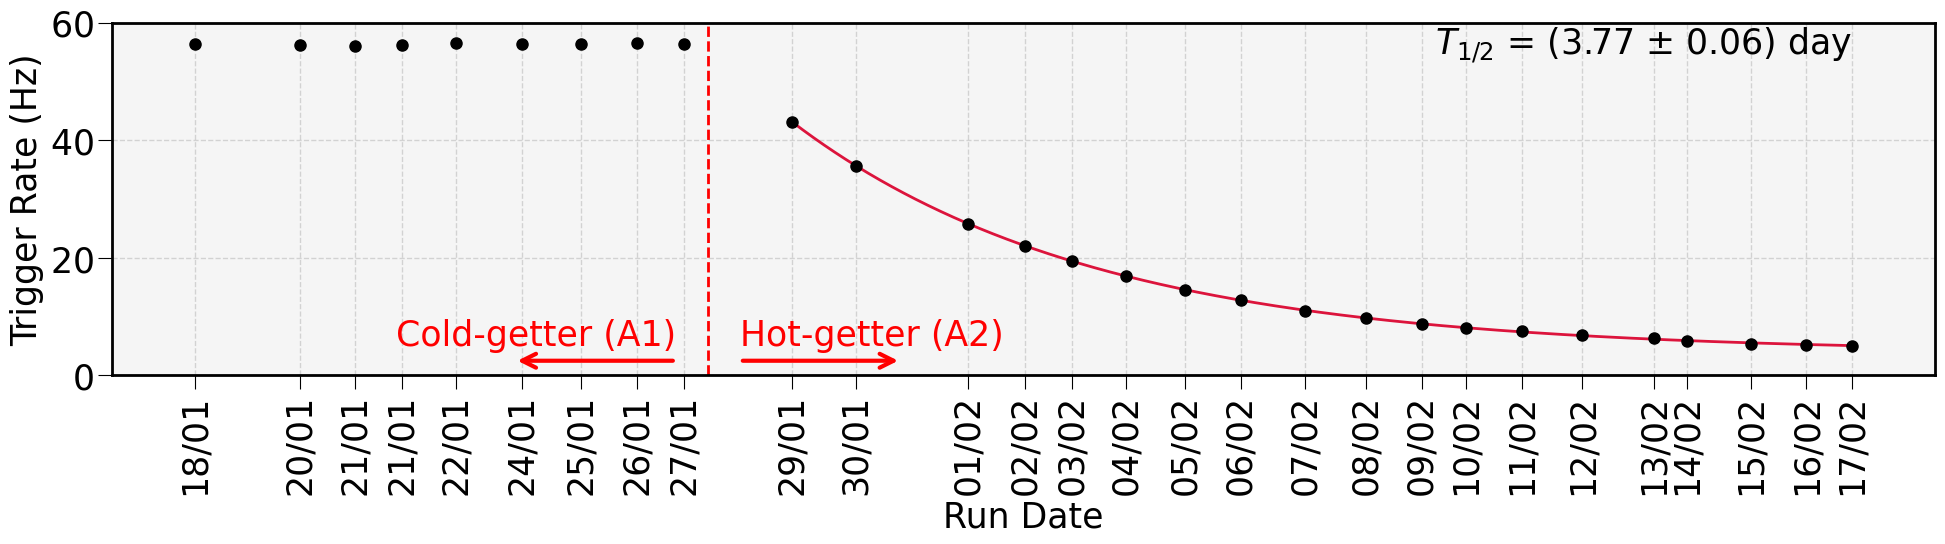

In [14]:
# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(20, 6))

# Data
plt.errorbar(Date, Rate, xerr=Date_err, yerr=Rate_err, fmt='o', c='black', ecolor='black')
# for x, y, run_id in zip(Date, Rate, Run_numbers):
#     plt.text(x, y, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')  # Run number near the point

# Fit
plt.plot(x_fit, y_fit, color=crudo.pt.hist_colors[(1) % len(crudo.pt.hist_colors)], label=f'Fit\nχ² / ndof = {chi2 / ndof:.4f}')

# ----- Styling ----- #
# Important text
plt.axvline(x=1737975600, c='red', ls='--')
plt.text(1737975600+5e4, 4.0, 'Hot-getter (A2)', c='red', va='bottom', ha='left')
ax.annotate('', xytext=(1737975600+5e4, 2.5), xy=(1737975600+3e5, 2.5), arrowprops=dict(arrowstyle='->',  ec='red', fc='red'))
plt.text(1737975600-5e4, 4.0, 'Cold-getter (A1)', c='red', va='bottom', ha='right')
ax.annotate('', xytext=(1737975600-5e4, 2.5), xy=(1737975600-3e5, 2.5), arrowprops=dict(arrowstyle='->',  ec='red', fc='red'))
plt.text(Date.max(), 53, r'$T_{1/2}$'f' = ({CV_lambda:.2f} ± {Error_lambda:.2f}) day', va='bottom', ha='right')

# # Preliminary logo
# LOGO_BOX    = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (Date.max(), Rate.max())
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(-67, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

# Axes
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]  # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, rotation=90, ha='center')
plt.ylabel('Trigger Rate (Hz)')
plt.ylim(0, 60)
# plt.title('Trigger Real Rate')
# plt.legend(loc='upper right', fontsize=8)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Radon_LPR/images/Trigger_Rate_Evolution.pdf')
# plt.savefig(f'/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/Trigger_Rate_Evolution.pdf')
plt.tight_layout()
plt.show()

### DAQ Efficiency

In [15]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)

#     # Plot
#     plt.errorbar(Date_CV, DAQe_CV, xerr=Date_error, yerr=DAQe_error, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, DAQe_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0.9, 'Hot-getter recirculation', c='red', va='top', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('DAQ Efficiency')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

### Reconstructed Events

Este plot no está corregido por la eficiencia de reconstrucción.

In [16]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_long = entry["duration"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)
    
#     # Reco events
#     reco_evts  = entry['reco_evt_CV'];  reco_evts = int(reco_evts)
#     reco_CV, reco_var = scipy.stats.binom.stats(n=run_OK, p=reco_evts/run_OK, moments='mv')
    
#     # Reco rate + error for each run
#     rate_CV  = reco_CV / (run_long * DAQe_CV)
#     rate_err = rate_CV * np.sqrt((np.sqrt(reco_var) / reco_CV)**2 + (DAQe_error / DAQe_CV)**2)

#     # Plot
#     plt.errorbar(Date_CV, rate_CV, xerr=Date_error, yerr=rate_err, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, rate_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0.5, 'Hot-getter recirculation', c='red', va='bottom', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('Rate (Hz)')
# # plt.title(r'Reconstructed Events')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

### $\alpha$ Candidates

Este plot no está corregido por la eficiencia de selección.

In [17]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_long = entry["duration"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)
    
#     # Reco events
#     reco_evts  = entry['sel_evt_CV'];  reco_evts = int(reco_evts)
#     reco_CV, reco_var = scipy.stats.binom.stats(n=run_OK, p=reco_evts/run_OK, moments='mv')
    
#     # Reco rate + error for each run
#     rate_CV  = reco_CV / (run_long * DAQe_CV)
#     rate_err = rate_CV * np.sqrt((np.sqrt(reco_var) / reco_CV)**2 + (DAQe_error / DAQe_CV)**2)

#     # Plot
#     plt.errorbar(Date_CV, rate_CV, xerr=Date_error, yerr=rate_err, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, rate_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0, 'Hot-getter recirculation', c='red', va='bottom', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('Rate (Hz)')
# # plt.title(r'$\alpha$ Candidates')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

# Fits
To fit data we just use the population of the detector's center, where the information is quite uniform.

From later analysis, we know that alpha population with $S2w\gt50$ have a well-reconstructed energy.
<br>
Therefore, we consider this cut as another mask in case we are using _s2w_no_cuts_ dataset.

In [18]:
# Store fits information
FIT_PARAMETERS = {run["run_number"]: {} for run in RUNS_INFO}

# Limits for masking
if DF_NAME == 's2w_no_cuts':
    s2w_lim = 50    # In [μs]
else:
    s2w_lim = 10    # In [μs], nominal value in IC reconstruction

### $S1e$ vs DT

Run 14714 Fit: m = (0.57 ± 0.00) PE/μs, b = (791.61 ± 1.76) PE
χ² / ndof = 1.5956


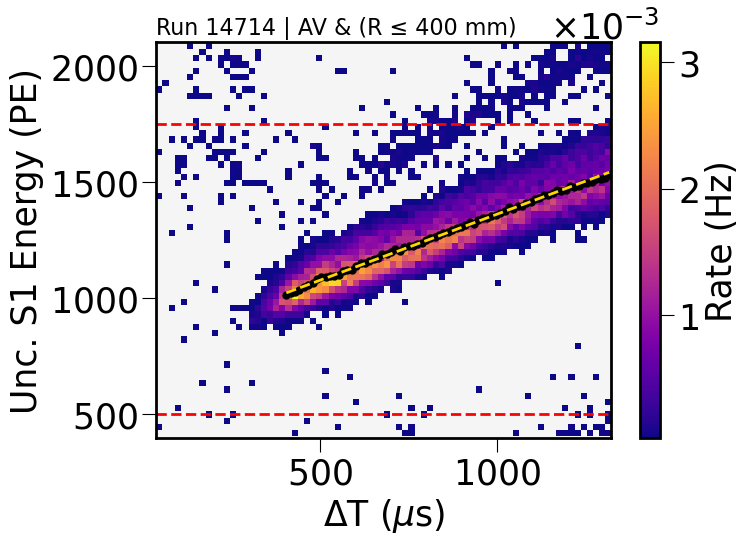

Run 14716 Fit: m = (0.58 ± 0.01) PE/μs, b = (785.81 ± 4.82) PE
χ² / ndof = 1.4104


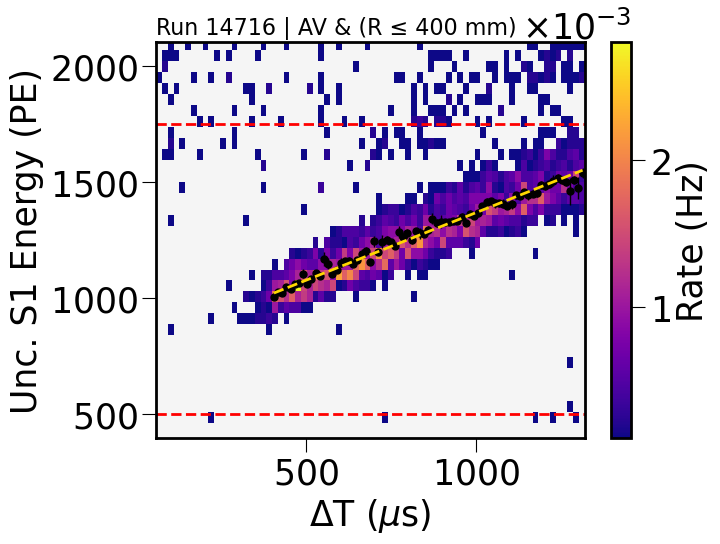

Run 14720 Fit: m = (0.54 ± 0.01) PE/μs, b = (825.46 ± 4.69) PE
χ² / ndof = 1.2454


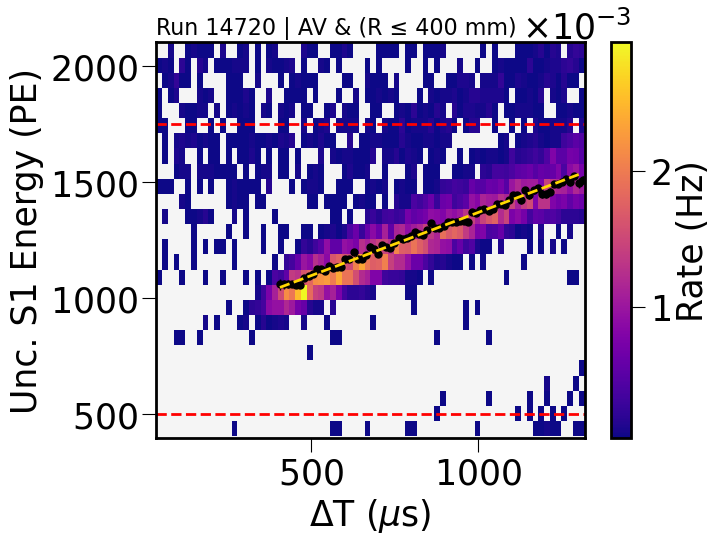

Run 14733 Fit: m = (0.57 ± 0.00) PE/μs, b = (791.74 ± 1.91) PE
χ² / ndof = 1.6118


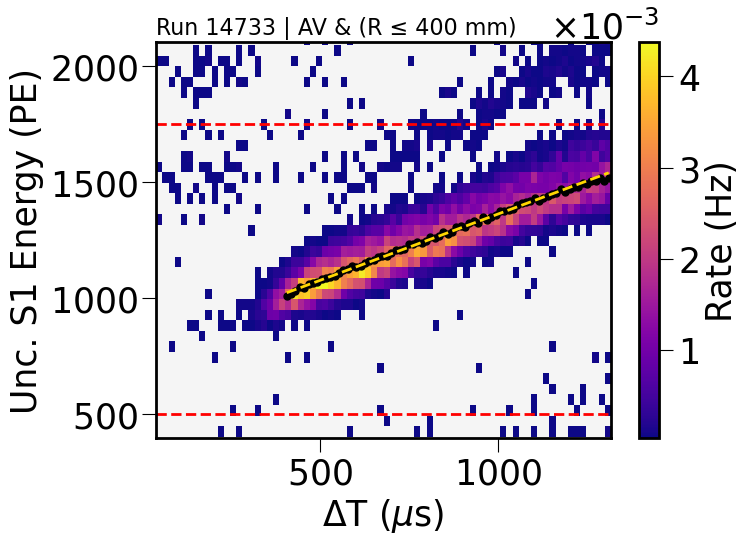

Run 14735 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.80 ± 1.56) PE
χ² / ndof = 1.9630


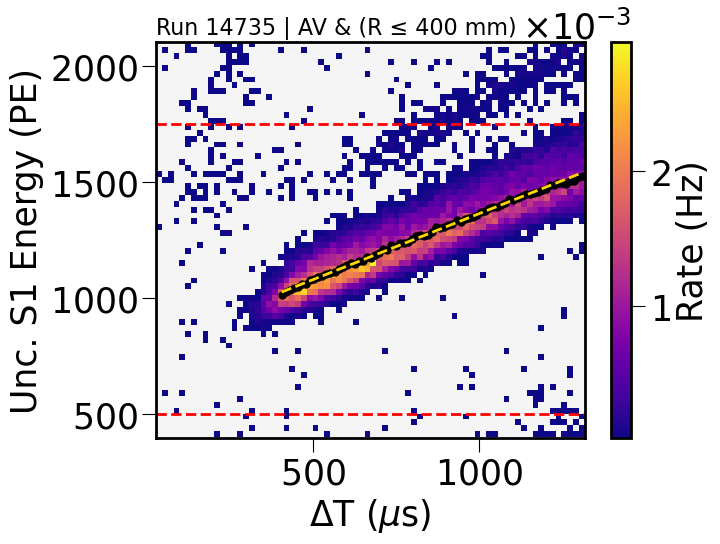

Run 14737 Fit: m = (0.56 ± 0.00) PE/μs, b = (799.04 ± 1.60) PE
χ² / ndof = 1.8549


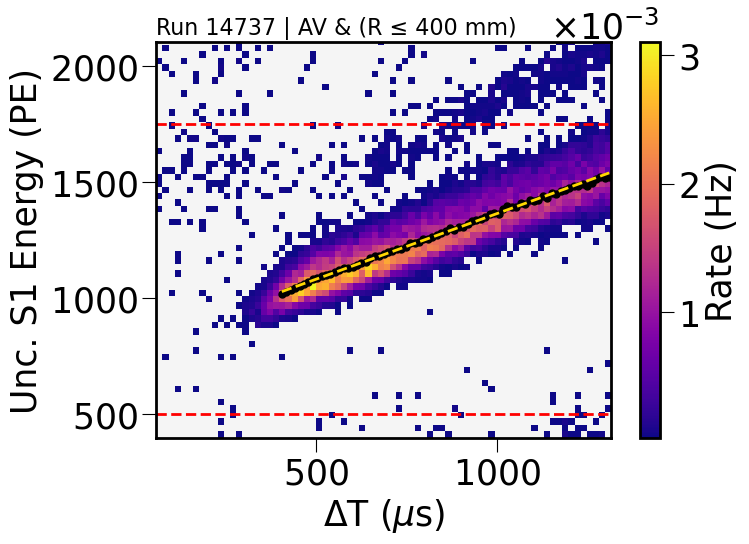

Run 14739 Fit: m = (0.57 ± 0.00) PE/μs, b = (796.53 ± 1.49) PE
χ² / ndof = 1.8023


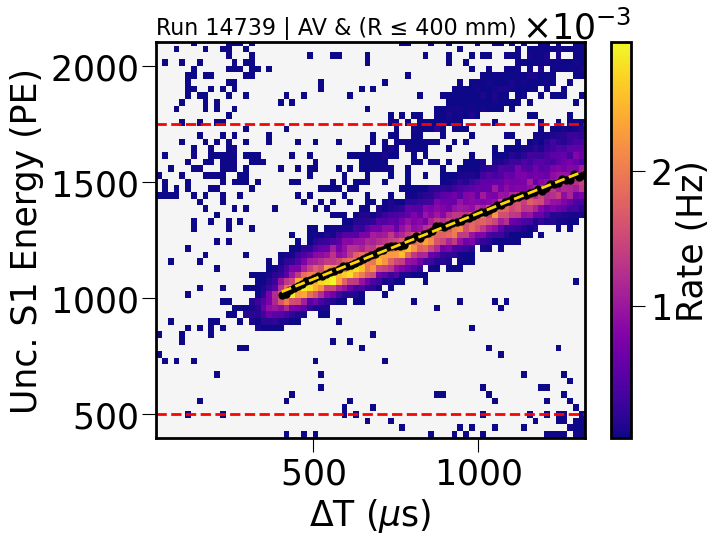

Run 14741 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.20 ± 1.46) PE
χ² / ndof = 2.2537


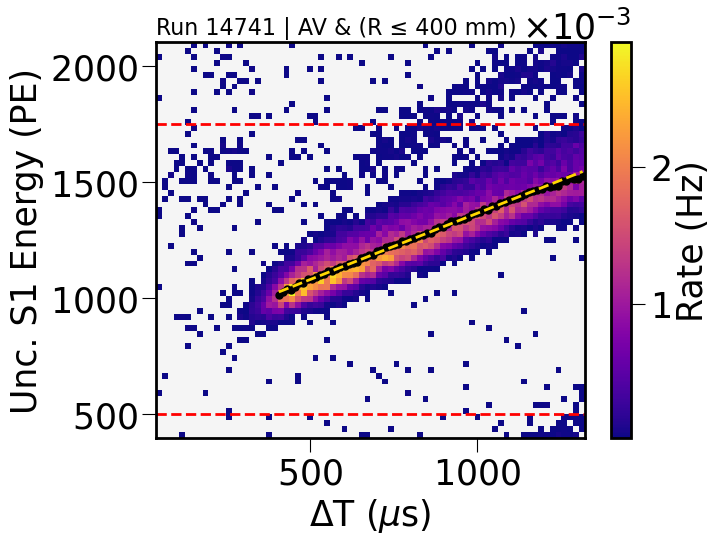

Run 14743 Fit: m = (0.57 ± 0.00) PE/μs, b = (794.70 ± 1.52) PE
χ² / ndof = 2.6609


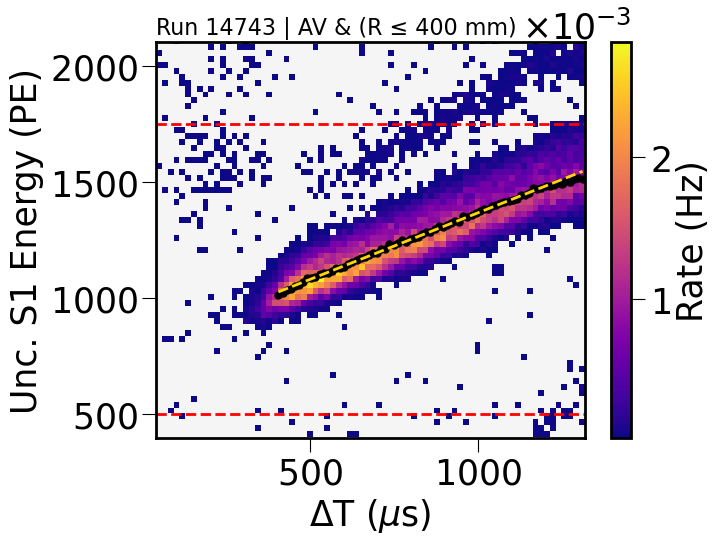

Run 14745 Fit: m = (0.57 ± 0.00) PE/μs, b = (796.95 ± 1.78) PE
χ² / ndof = 1.8820


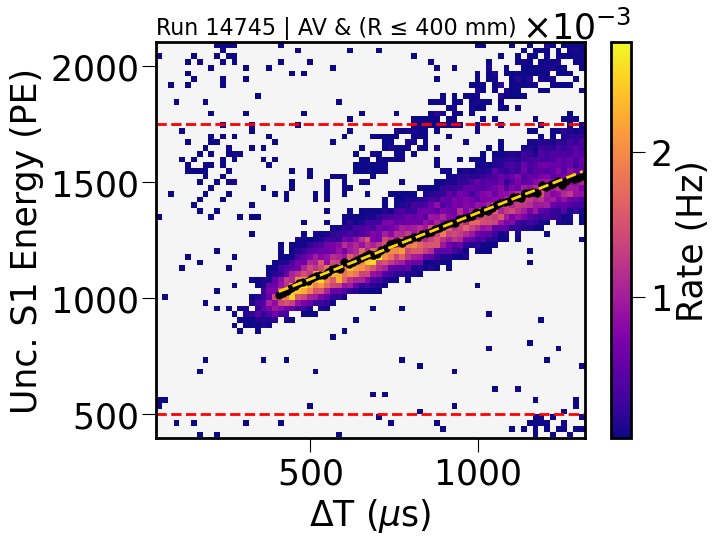

Run 14753 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.32 ± 1.61) PE
χ² / ndof = 2.0783


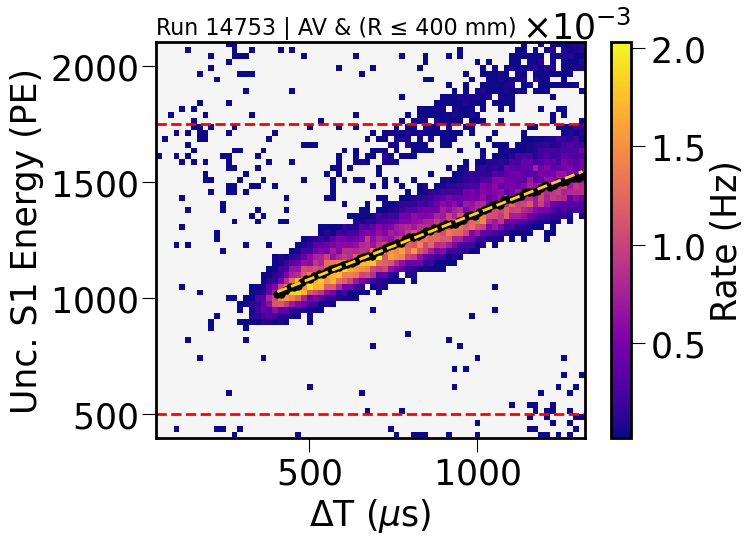

Run 14765 Fit: m = (0.53 ± 0.00) PE/μs, b = (829.13 ± 4.10) PE
χ² / ndof = 1.0793


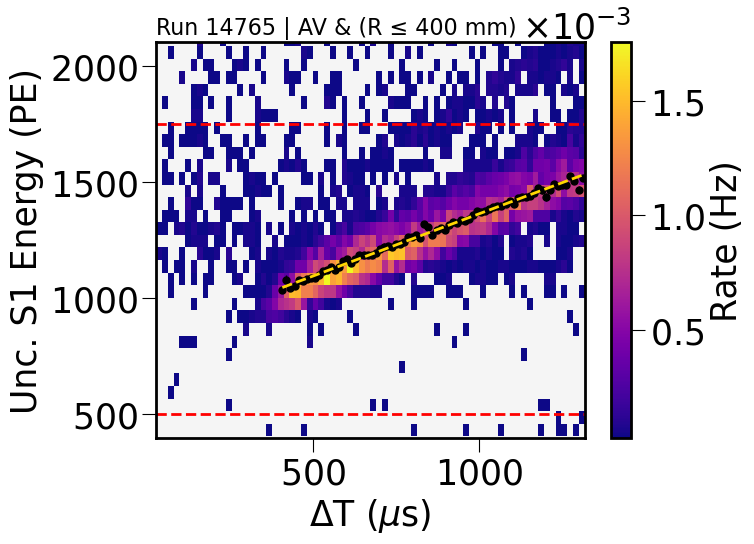

Run 14780 Fit: m = (0.56 ± 0.00) PE/μs, b = (835.96 ± 2.87) PE
χ² / ndof = 1.1536


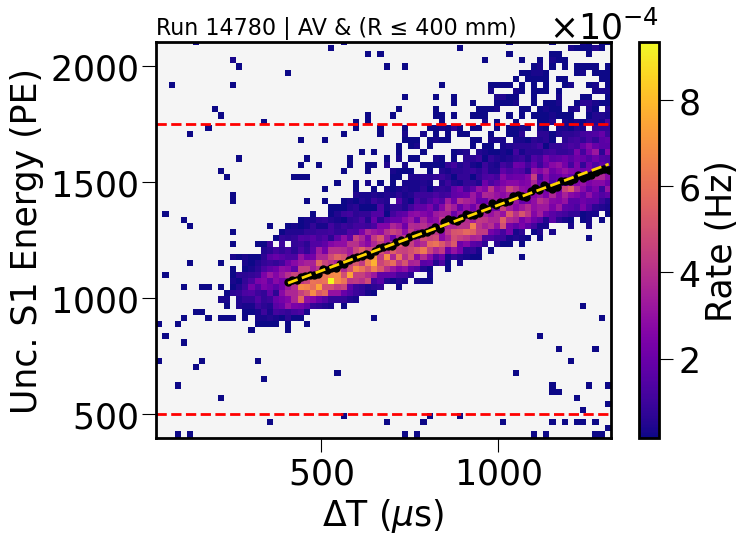

Run 14782 Fit: m = (0.58 ± 0.00) PE/μs, b = (795.10 ± 1.85) PE
χ² / ndof = 1.9721


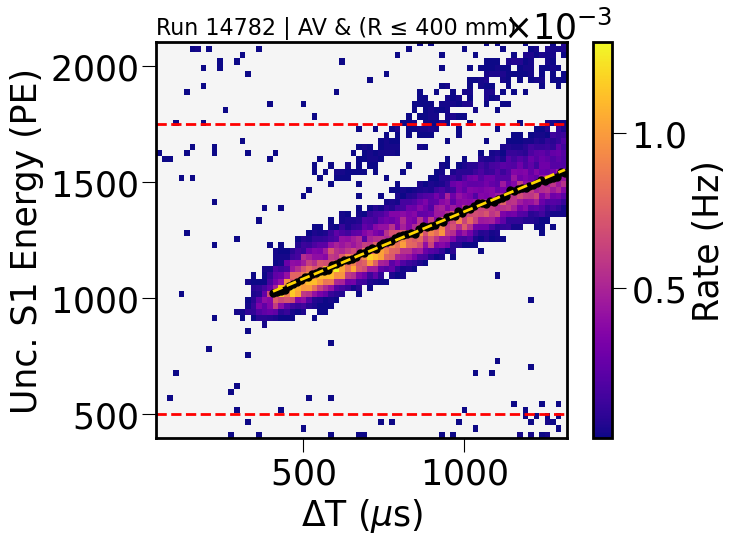

Run 14784 Fit: m = (0.57 ± 0.00) PE/μs, b = (798.71 ± 2.35) PE
χ² / ndof = 1.2479


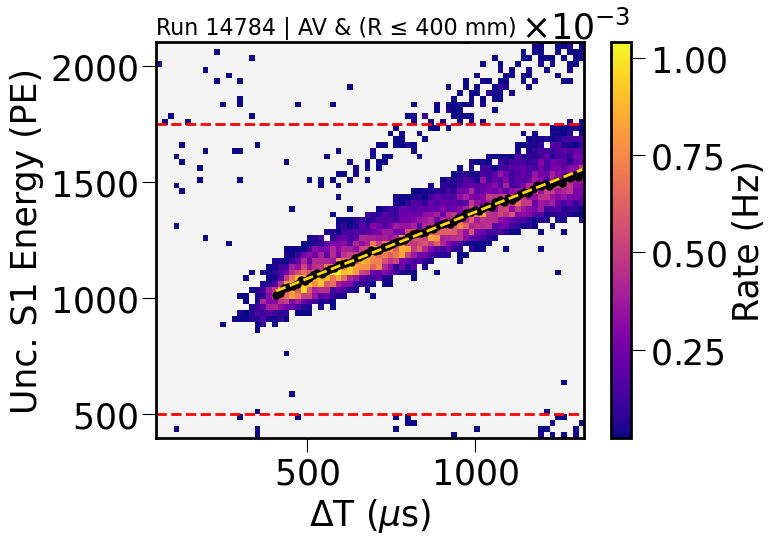

Run 14789 Fit: m = (0.58 ± 0.00) PE/μs, b = (795.51 ± 2.38) PE
χ² / ndof = 1.2913


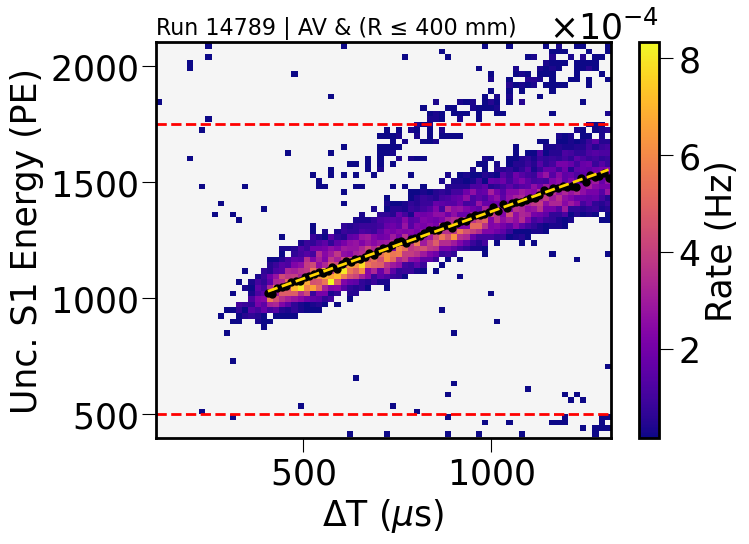

Run 14803 Fit: m = (0.50 ± 0.00) PE/μs, b = (699.88 ± 0.99) PE
χ² / ndof = 2.4466


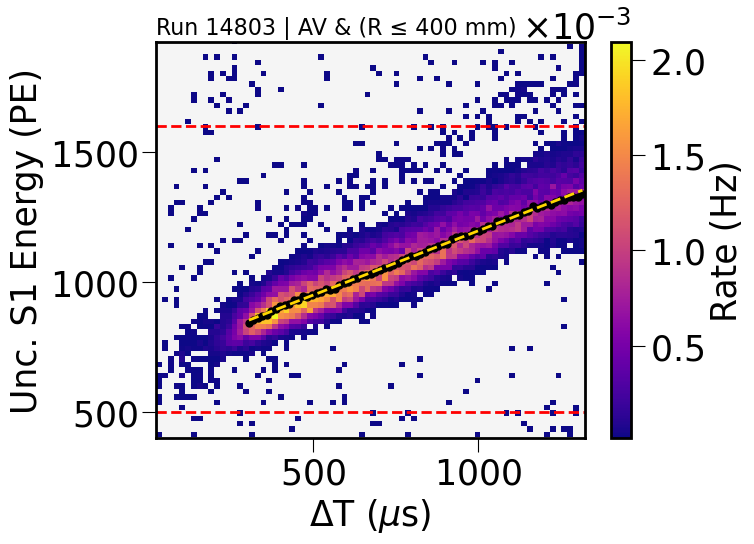

Run 14804 Fit: m = (0.50 ± 0.00) PE/μs, b = (699.94 ± 1.14) PE
χ² / ndof = 1.4258


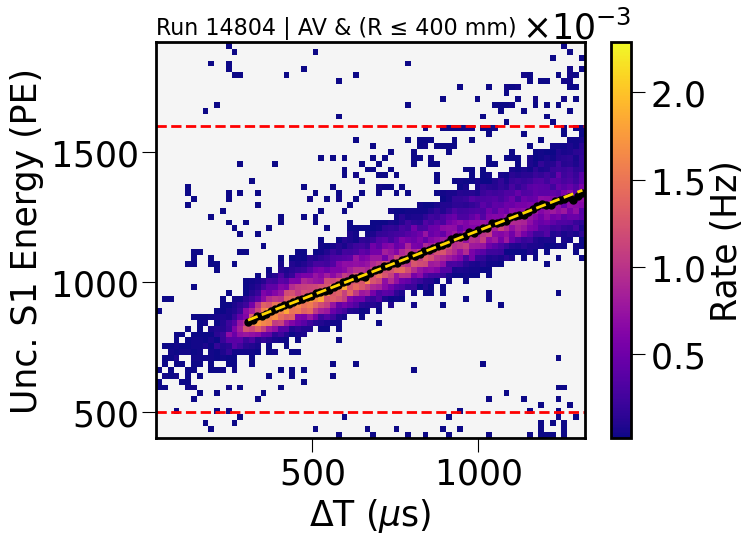

Run 14811 Fit: m = (0.49 ± 0.00) PE/μs, b = (700.72 ± 1.46) PE
χ² / ndof = 1.3355


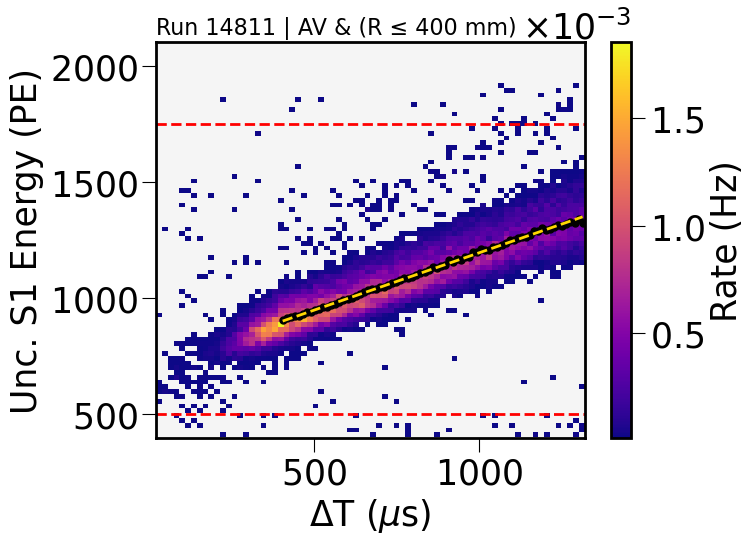

Run 14814 Fit: m = (0.49 ± 0.01) PE/μs, b = (700.33 ± 3.86) PE
χ² / ndof = 1.4695


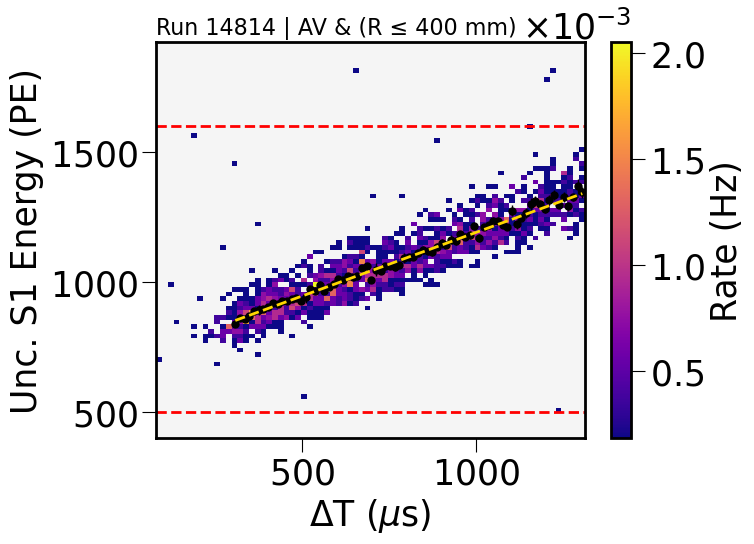

Run 14815 Fit: m = (0.50 ± 0.00) PE/μs, b = (697.47 ± 1.24) PE
χ² / ndof = 1.5860


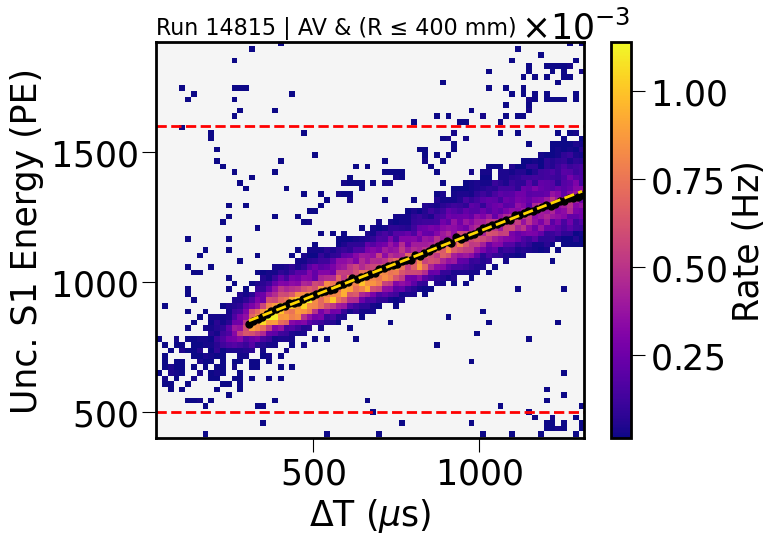

Run 14816 Fit: m = (0.49 ± 0.00) PE/μs, b = (699.75 ± 1.37) PE
χ² / ndof = 1.3509


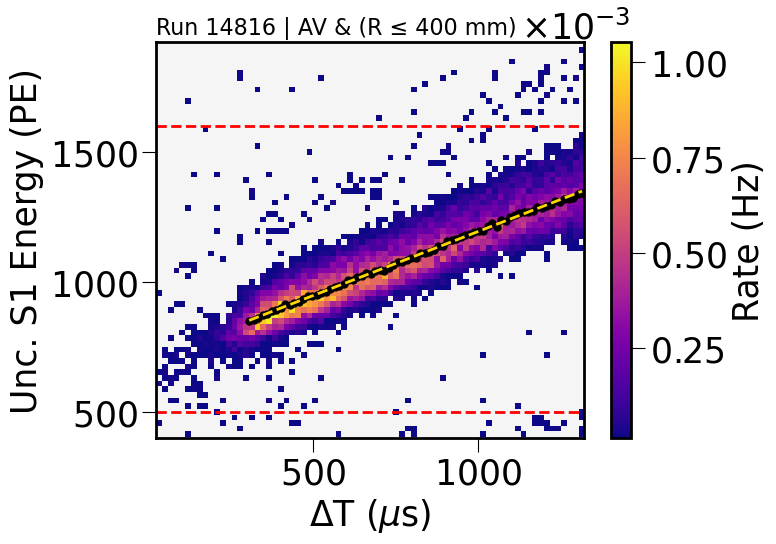

Run 14817 Fit: m = (0.49 ± 0.00) PE/μs, b = (699.96 ± 1.84) PE
χ² / ndof = 1.0837


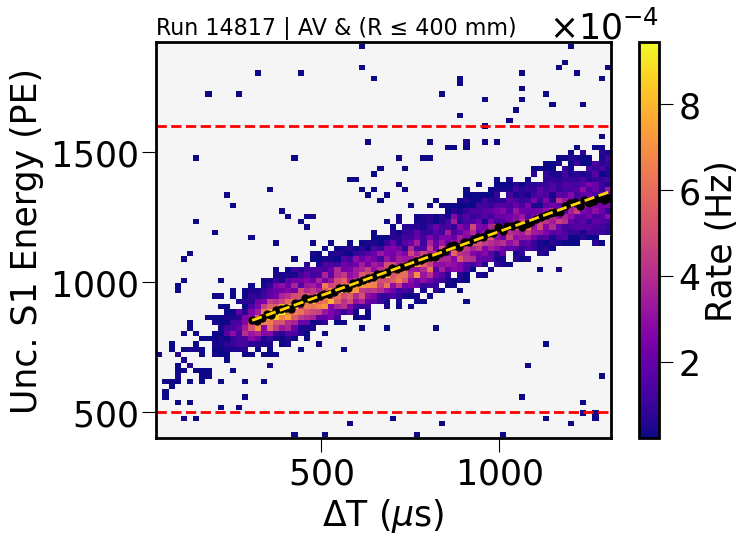

Run 14828 Fit: m = (0.50 ± 0.01) PE/μs, b = (694.12 ± 4.93) PE
χ² / ndof = 1.0750


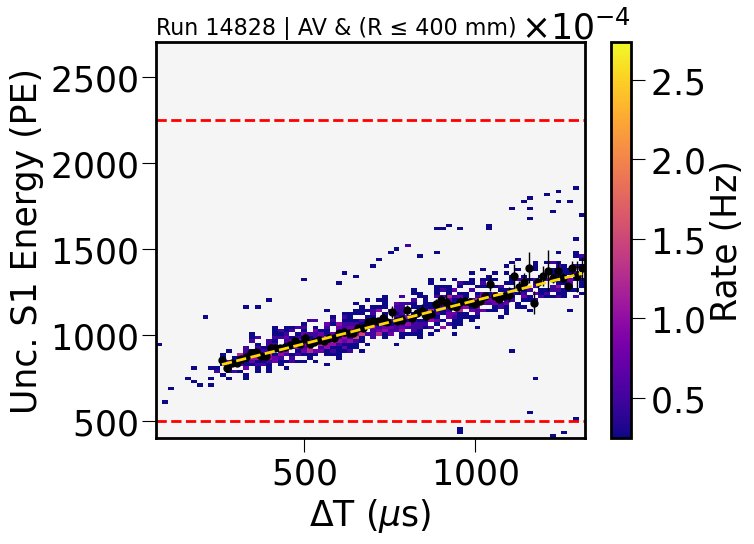

Run 14829 Fit: m = (0.60 ± 0.01) PE/μs, b = (884.53 ± 6.84) PE
χ² / ndof = 1.7579


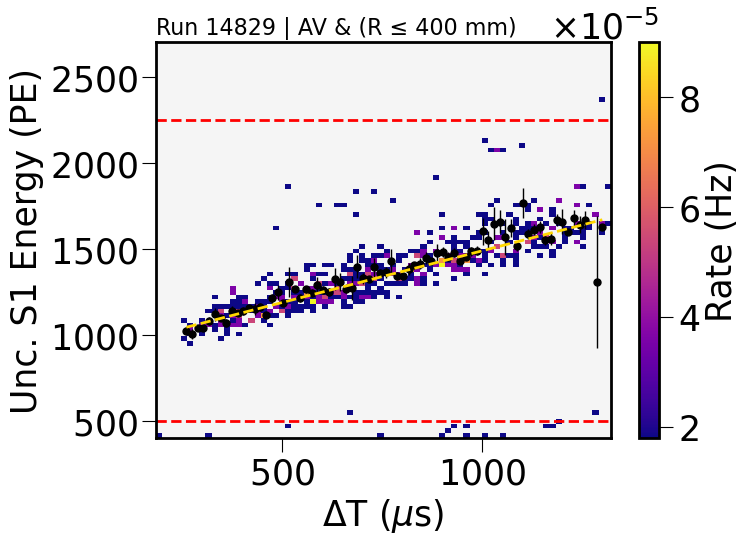

Run 14834 Fit: m = (0.71 ± 0.01) PE/μs, b = (790.45 ± 3.13) PE
χ² / ndof = 5.4379


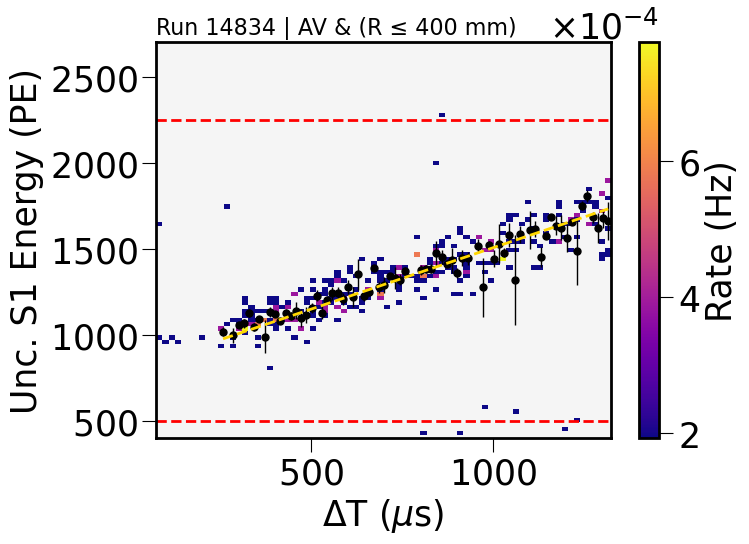

Run 14835 Fit: m = (0.64 ± 0.01) PE/μs, b = (858.64 ± 6.66) PE
χ² / ndof = 1.8514


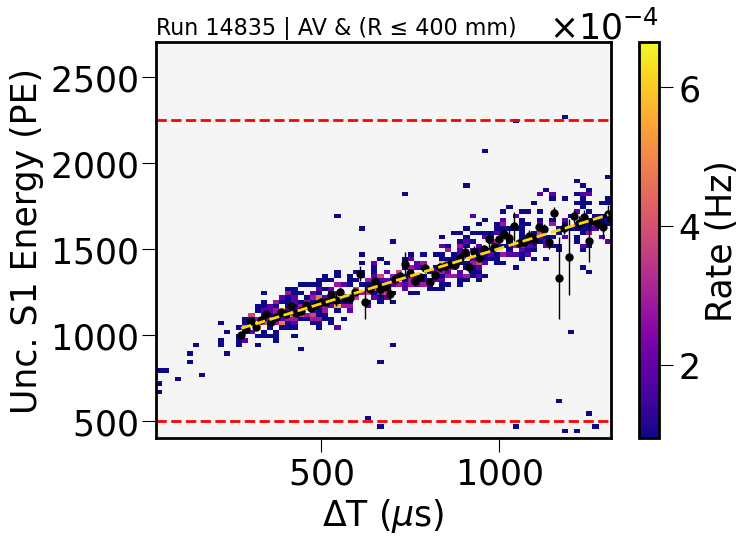

Run 14837 Fit: m = (0.62 ± 0.00) PE/μs, b = (878.64 ± 3.48) PE
χ² / ndof = 1.7596


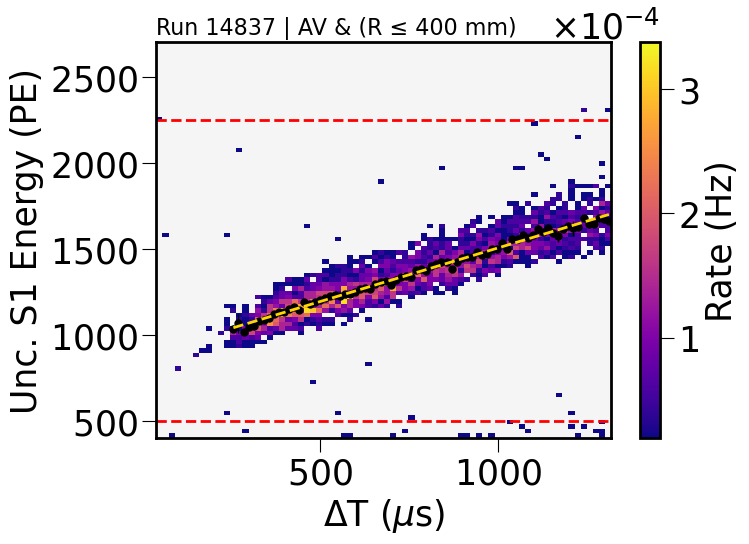

Run 14838 Fit: m = (0.62 ± 0.01) PE/μs, b = (879.39 ± 3.63) PE
χ² / ndof = 1.0782


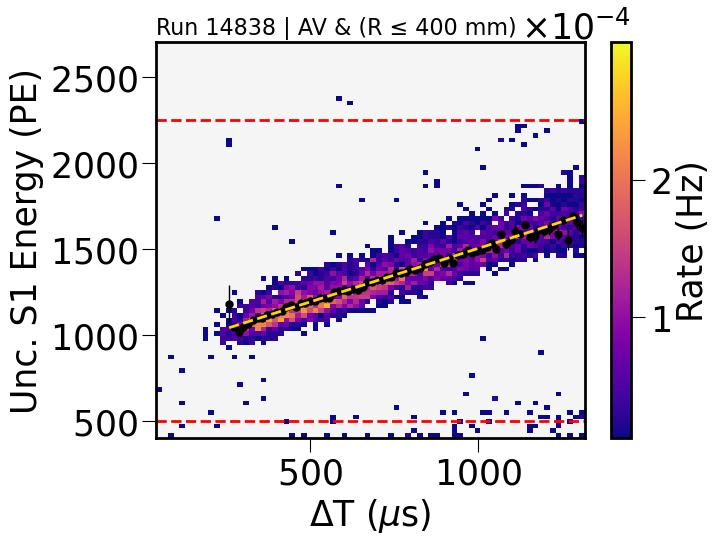

Run 14839 Fit: m = (0.64 ± 0.01) PE/μs, b = (871.25 ± 3.64) PE
χ² / ndof = 1.2073


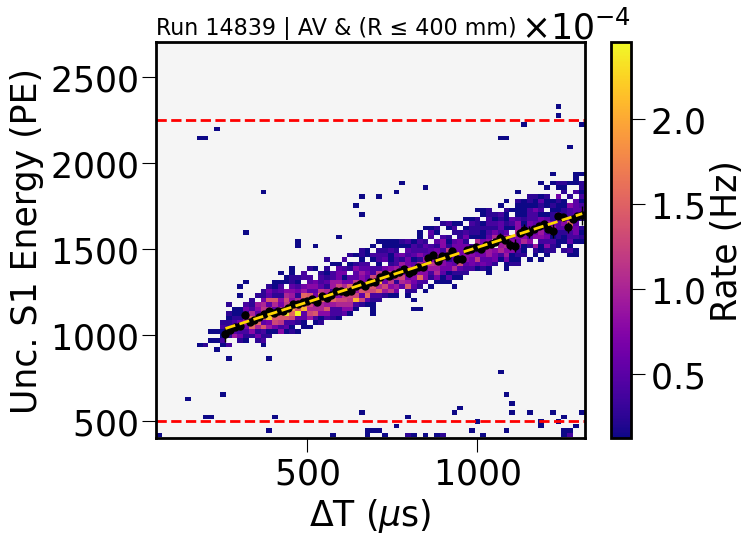

Run 14840 Fit: m = (0.62 ± 0.01) PE/μs, b = (879.86 ± 4.95) PE
χ² / ndof = 1.1224


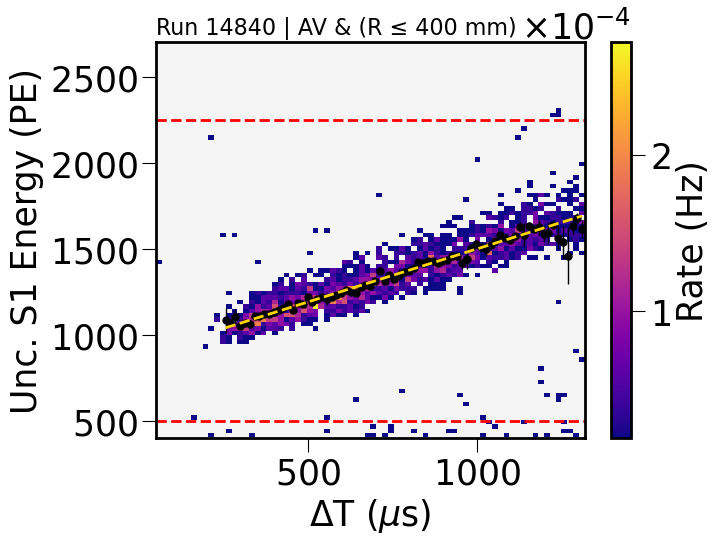

In [19]:
# Global
rad_lim = 400
n_bins  = 75

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)

    # Variables    
    E1 = SEL_DATA[run_id]['S1e']
    DT = SEL_DATA[run_id]['DT']
    R  = SEL_DATA[run_id]['R']
    W2 = SEL_DATA[run_id]['S2w']

    # Masking
    rad_mask = (R  < rad_lim)
    s2w_mask = (W2 > s2w_lim)
    E1_mask  = E1[AV_mask[run_id] & rad_mask & s2w_mask]
    DT_mask  = DT[AV_mask[run_id] & rad_mask & s2w_mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1_mask, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map         = S1e_DT_map / (run_long * DAQe_CV)                           
    S1e_DT_map         = np.ma.masked_where(S1e_DT_map==0, S1e_DT_map)                # Zero values masked

    # ----- Linear Fit ----- #
    # Preliminary
    DT_down = 400;    DT_up = DT_mask.max()
    E1_down = 500;    E1_up = 1750
    if run_id in {14803, 14804, 14814, 14815, 14816, 14817}:
        DT_down = 300;    DT_up = DT_mask.max()
        E1_down = 500;    E1_up = 1600
    if run_id in {14828, 14829, 14834, 14835, 14837, 14838, 14839, 14840}:
        DT_down = 250;    DT_up = DT_mask.max()
        E1_down = 500;    E1_up = 2250

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E1_mask >= E1_down) & (E1_mask <= E1_up)
    DT_fit = DT_mask[fit_region_mask]
    E1_fit = E1_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S1e_means, S1e_errors = crudo.ff.prefit_2D(DT_fit, E1_fit, bins=n_bins)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S1e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S1e_means  = S1e_means[valid_points];       S1e_errors = S1e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S1e_means, S1e_errors, crudo.ff.linear_func)
    init_guess = [10, S1e_means.min()]
    # print(f'\nInitial guess: m = {init_guess[0]:.4f} PE/μs, b = {init_guess[1]:.4f} PE')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Run {run_id} Fit: m = ({popt[0]:.2f} ± {perr[0]:.2f}) PE/μs, b = ({popt[1]:.2f} ± {perr[1]:.2f}) PE')    
    FIT_PARAMETERS[run_id]["S1e"] = {"m_CV": popt[0], "m_err": perr[0], "b_CV": popt[1], "b_err": perr[1]}

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))

    # Data
    plt.pcolormesh(ex, ey, S1e_DT_map.T, cmap='plasma', shading='auto')    
    cbar = plt.colorbar(label='Rate (Hz)', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = crudo.ff.linear_func(DT_centers, *popt)
    plt.errorbar(DT_centers, S1e_means, xerr=DT_errors, yerr=S1e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
    plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
    plt.axhline(y=E1_up, c='red', ls='--')
    plt.axhline(y=E1_down, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Unc. S1 Energy (PE)')
    plt.ylim(0.8*E1_down, 1.2*E1_up)
    plt.title(f'Run {run_id} | AV & (R ≤ {rad_lim} mm)', fontsize=16, loc='left')

    plt.gca().set_facecolor("whitesmoke")
    # plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/S1e_DT_fit_run{run_id}.pdf')
    plt.tight_layout()
    plt.show() 

### $S2e$ vs DT: Lifetime

Run 14714 fit: N0 = (826859.27 ± 708.86) PE, τ = (48.32 ± 2.32) ms
χ² / ndof = 1.7875


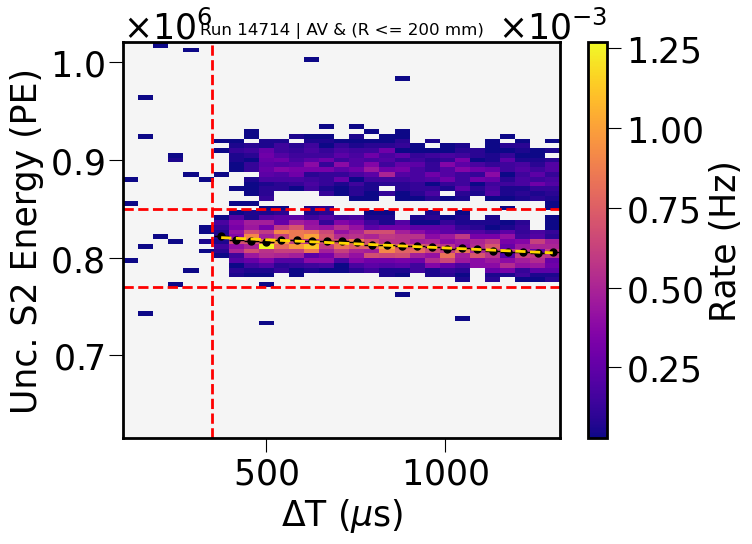

Run 14716 fit: N0 = (834447.92 ± 2163.16) PE, τ = (39.09 ± 4.45) ms
χ² / ndof = 1.2932


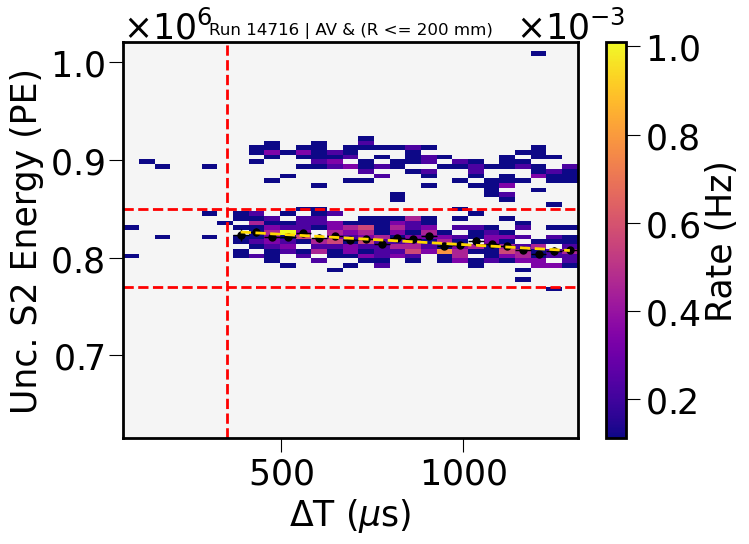

Run 14720 fit: N0 = (827570.08 ± 1259.98) PE, τ = (57.50 ± 5.79) ms
χ² / ndof = 1.3491


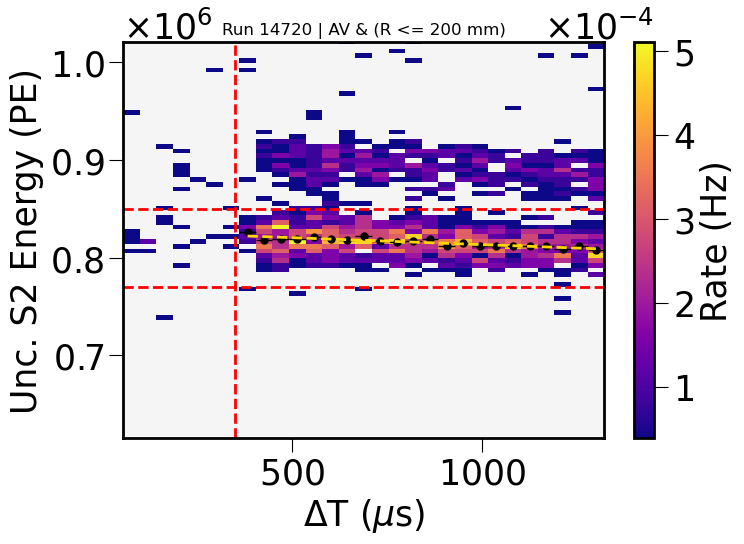

Run 14733 fit: N0 = (824808.94 ± 871.94) PE, τ = (61.65 ± 4.80) ms
χ² / ndof = 1.4519


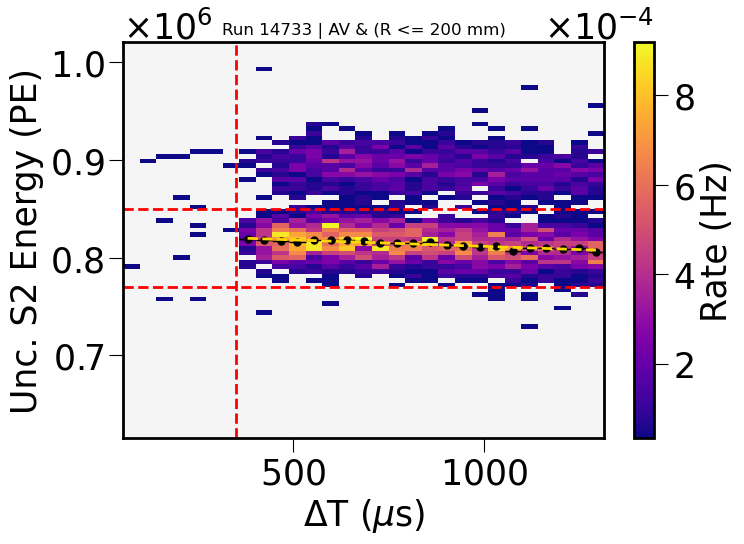

Run 14735 fit: N0 = (826717.99 ± 672.75) PE, τ = (50.26 ± 2.44) ms
χ² / ndof = 3.1107


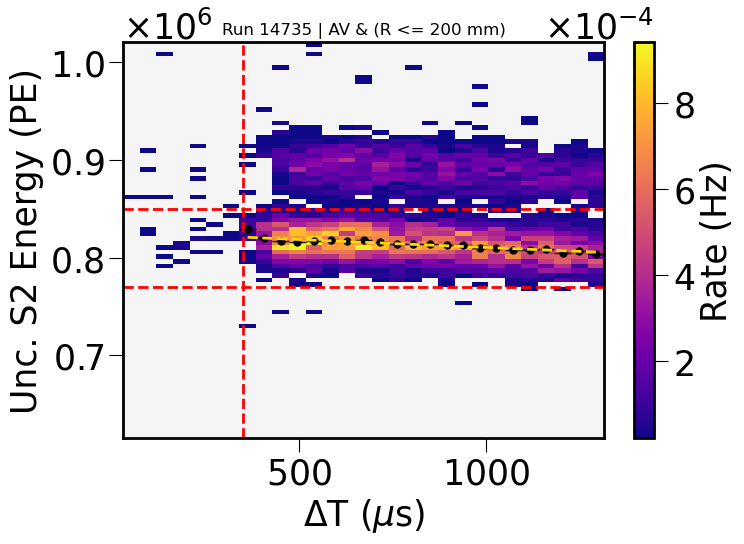

Run 14737 fit: N0 = (830405.09 ± 649.49) PE, τ = (59.22 ± 3.14) ms
χ² / ndof = 1.5849


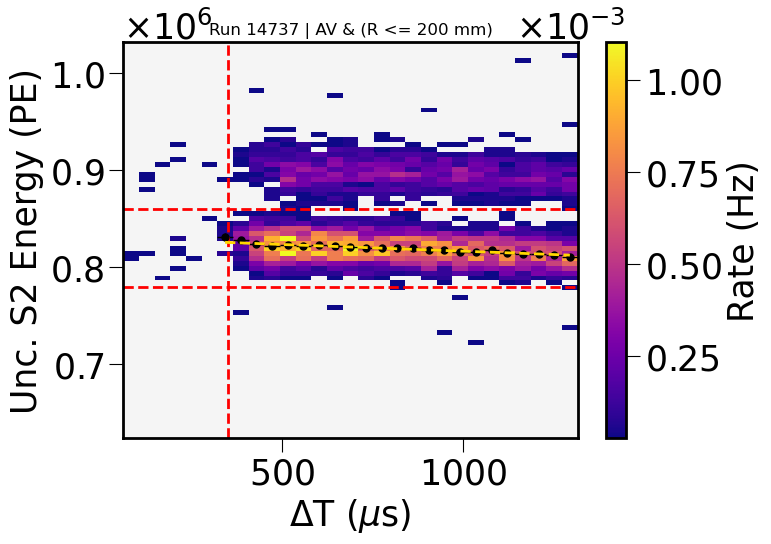

Run 14739 fit: N0 = (831950.76 ± 618.15) PE, τ = (55.77 ± 2.63) ms
χ² / ndof = 2.5716


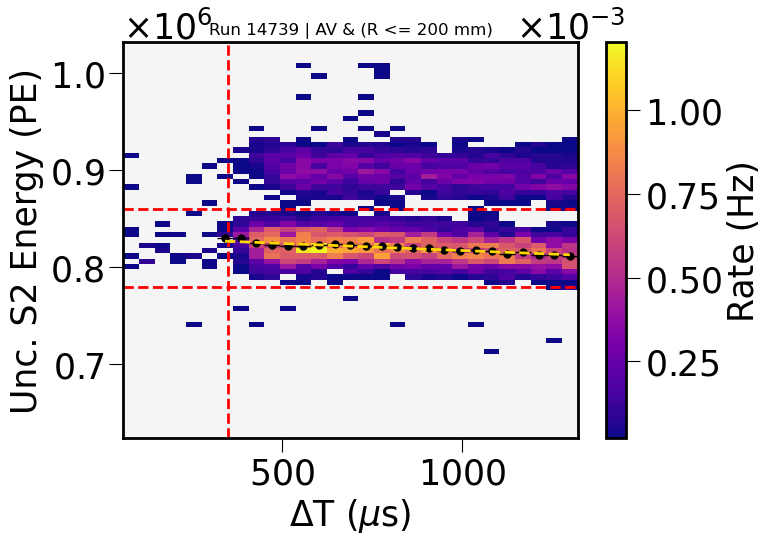

Run 14741 fit: N0 = (831307.76 ± 601.70) PE, τ = (59.00 ± 2.90) ms
χ² / ndof = 2.4020


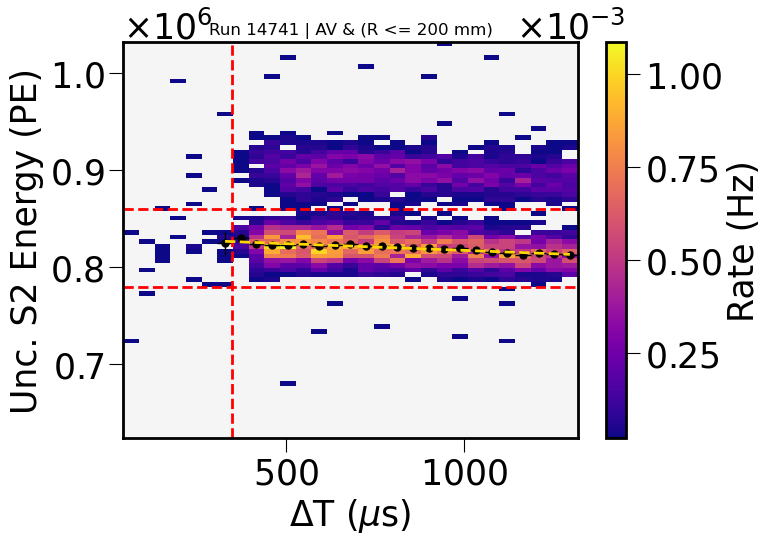

Run 14743 fit: N0 = (830964.25 ± 617.87) PE, τ = (63.14 ± 3.34) ms
χ² / ndof = 2.5796


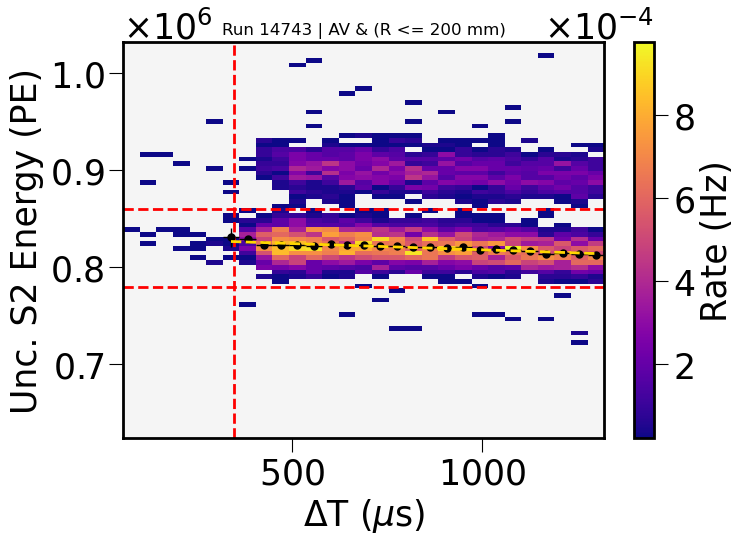

Run 14745 fit: N0 = (832503.57 ± 716.07) PE, τ = (56.95 ± 3.14) ms
χ² / ndof = 0.9857


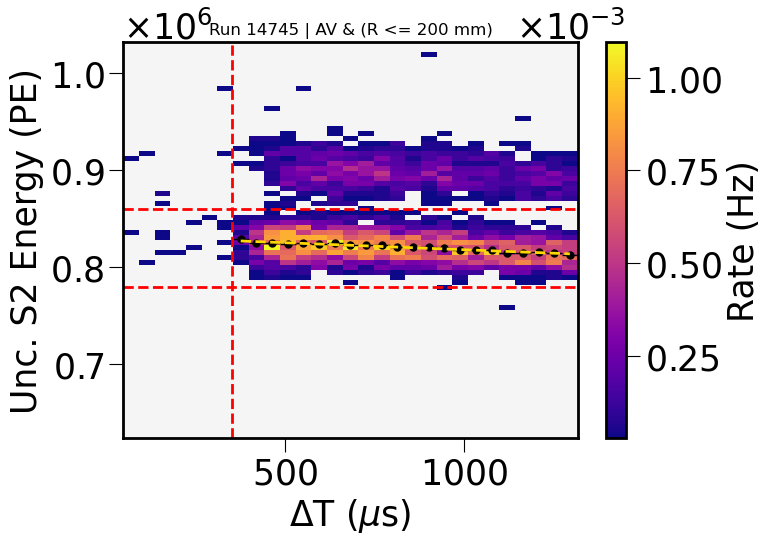

Run 14753 fit: N0 = (832588.15 ± 777.58) PE, τ = (50.41 ± 2.82) ms
χ² / ndof = 1.9809


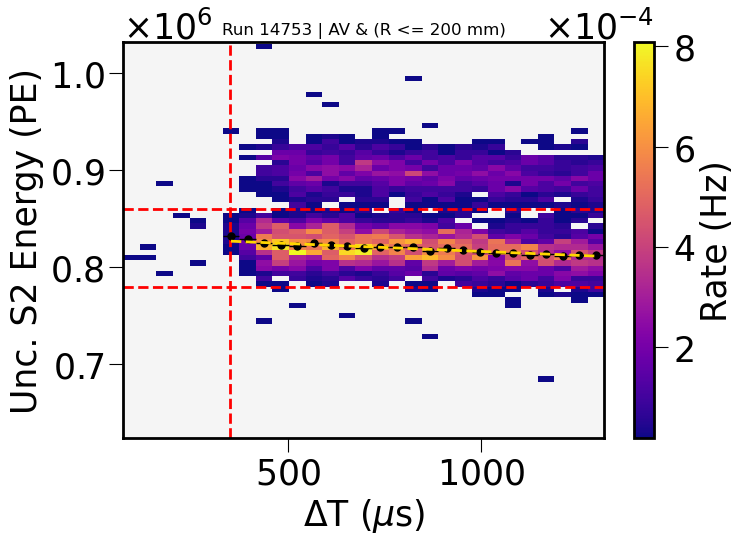

Run 14765 fit: N0 = (835751.57 ± 1264.86) PE, τ = (45.75 ± 3.65) ms
χ² / ndof = 0.7365


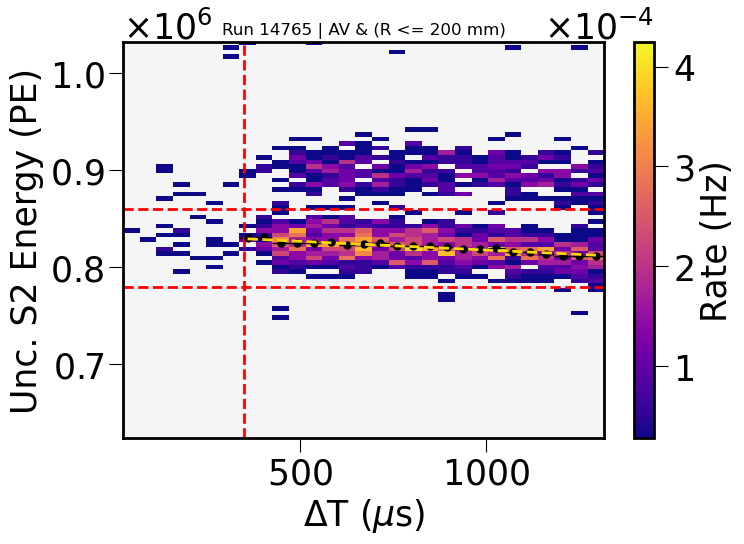

Run 14780 fit: N0 = (838290.62 ± 1043.68) PE, τ = (45.51 ± 2.92) ms
χ² / ndof = 1.7822


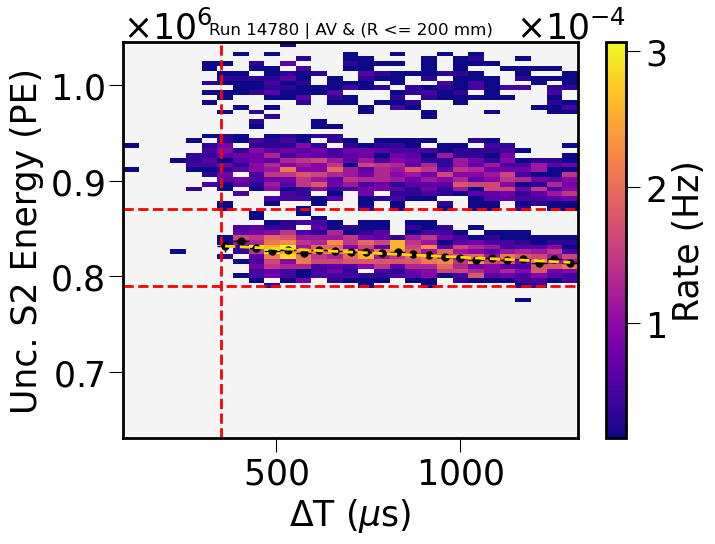

Run 14782 fit: N0 = (839496.22 ± 829.55) PE, τ = (50.14 ± 2.87) ms
χ² / ndof = 1.5512


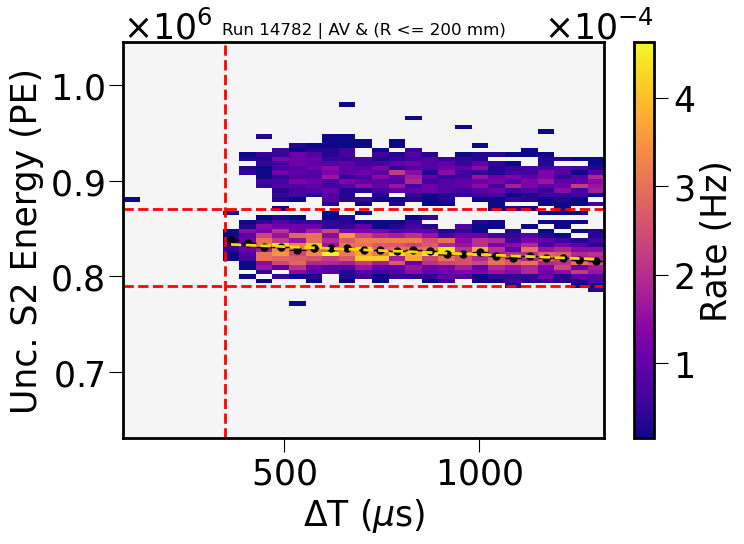

Run 14784 fit: N0 = (840941.13 ± 1016.57) PE, τ = (43.24 ± 2.56) ms
χ² / ndof = 1.3611


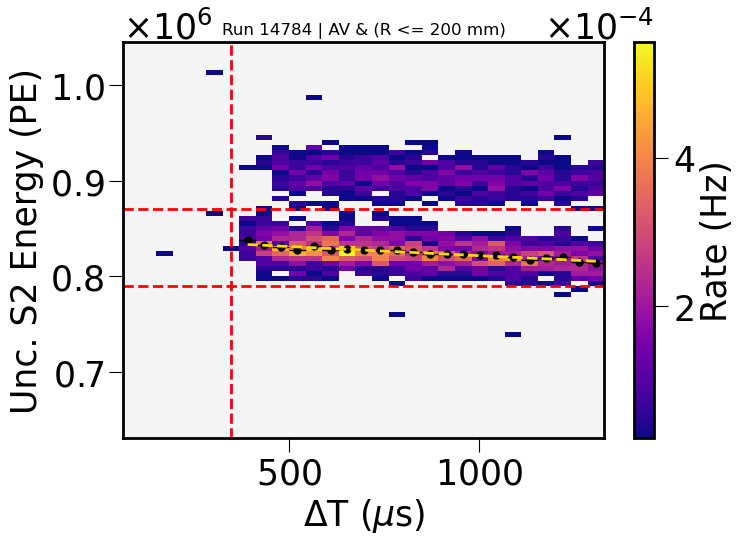

Run 14789 fit: N0 = (838799.02 ± 1032.17) PE, τ = (46.42 ± 3.02) ms
χ² / ndof = 0.7195


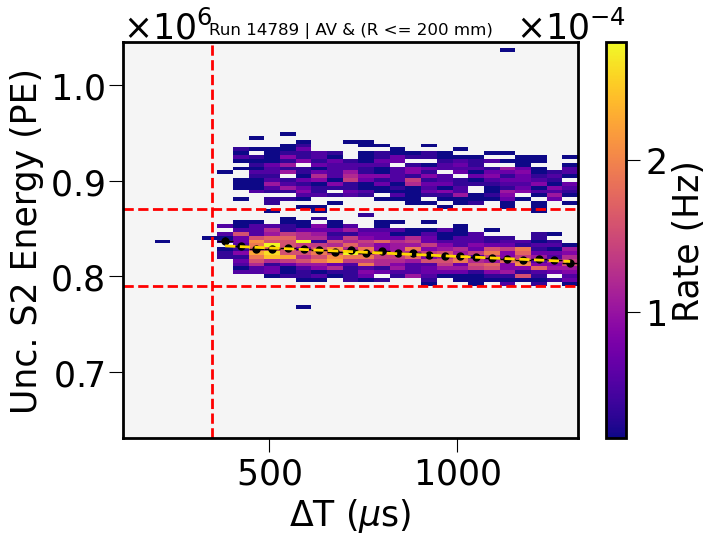

Run 14803 fit: N0 = (730928.90 ± 476.54) PE, τ = (78.51 ± 5.08) ms
χ² / ndof = 7.8092


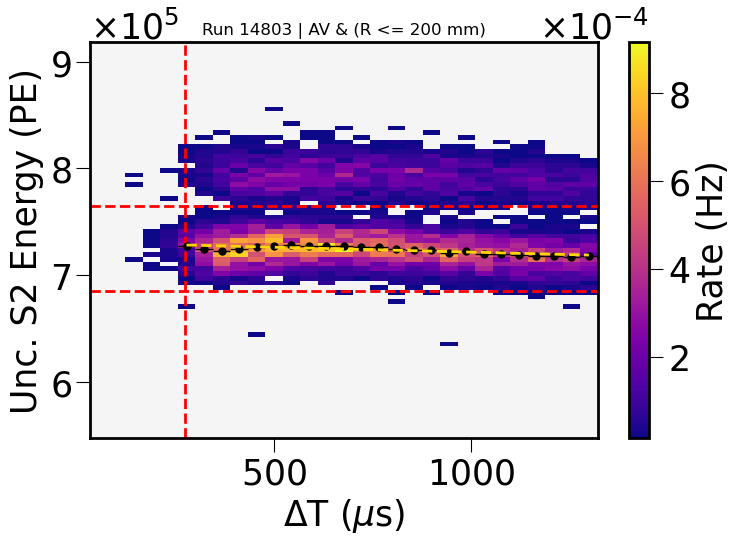

Run 14804 fit: N0 = (731339.42 ± 541.67) PE, τ = (84.20 ± 6.49) ms
χ² / ndof = 10.0409


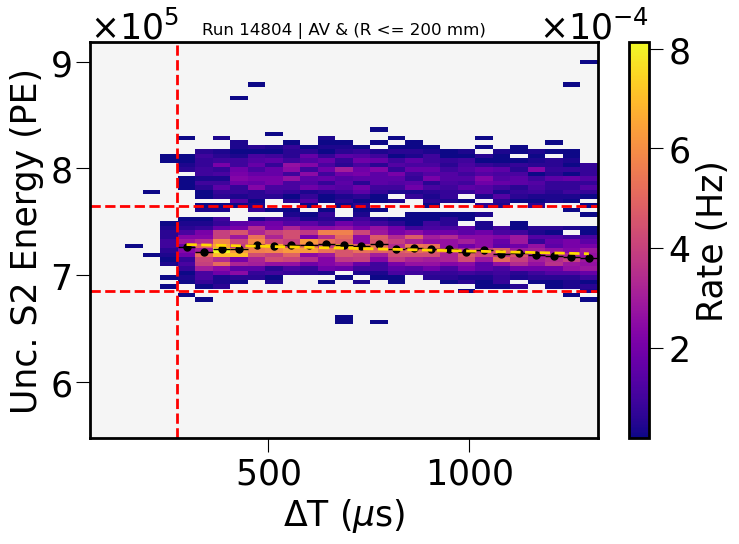

Run 14811 fit: N0 = (731006.00 ± 489.61) PE, τ = (102.02 ± 8.52) ms
χ² / ndof = 6.7507


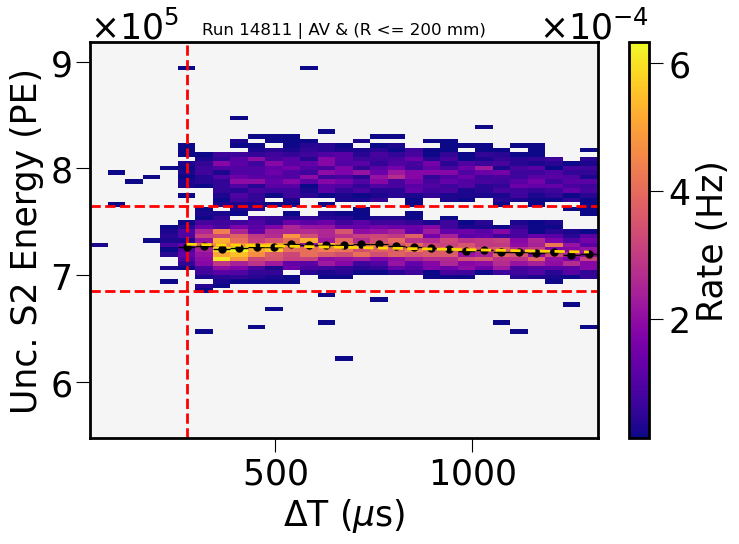

Run 14814 fit: N0 = (729476.29 ± 1934.35) PE, τ = (101.86 ± 32.07) ms
χ² / ndof = 1.6447


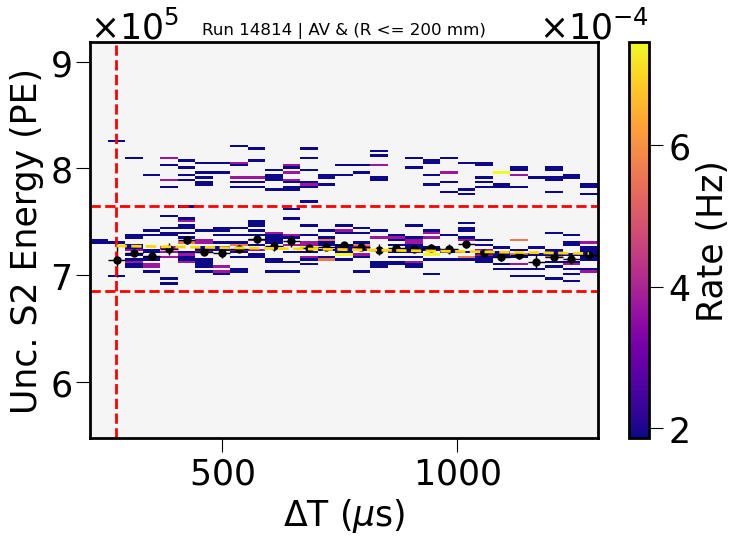

Run 14815 fit: N0 = (731420.51 ± 534.69) PE, τ = (97.58 ± 8.43) ms
χ² / ndof = 8.9329


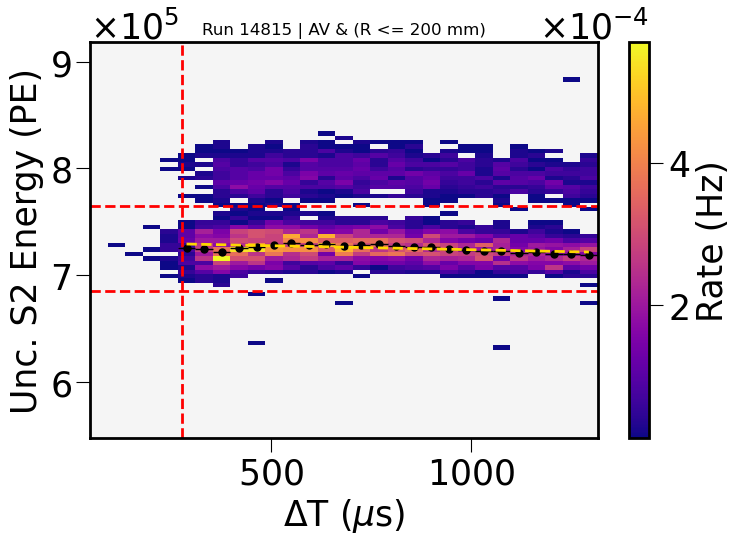

Run 14816 fit: N0 = (731008.12 ± 587.60) PE, τ = (115.66 ± 13.02) ms
χ² / ndof = 4.5645


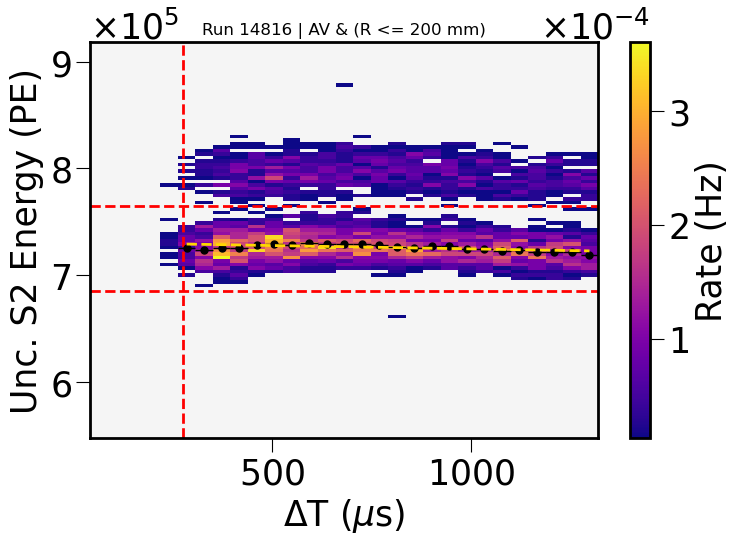

Run 14817 fit: N0 = (732025.68 ± 816.22) PE, τ = (102.60 ± 14.27) ms
χ² / ndof = 3.9897


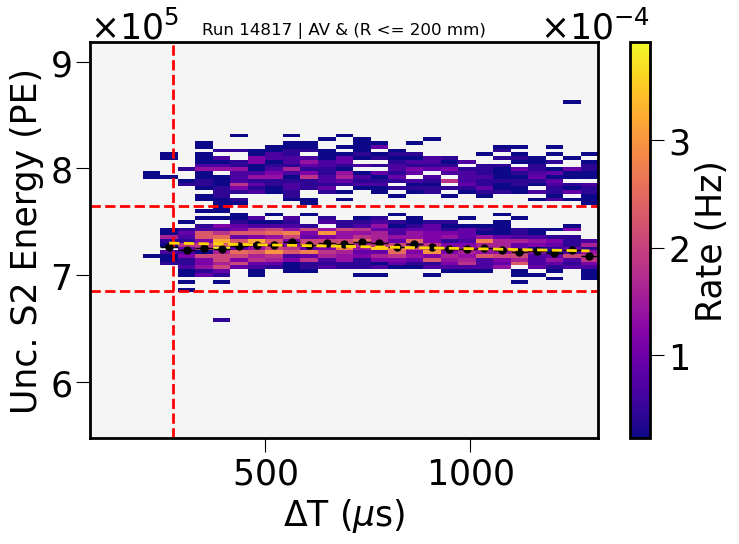

Run 14828 fit: N0 = (731280.55 ± 2204.67) PE, τ = (76.48 ± 20.50) ms
χ² / ndof = 1.5172


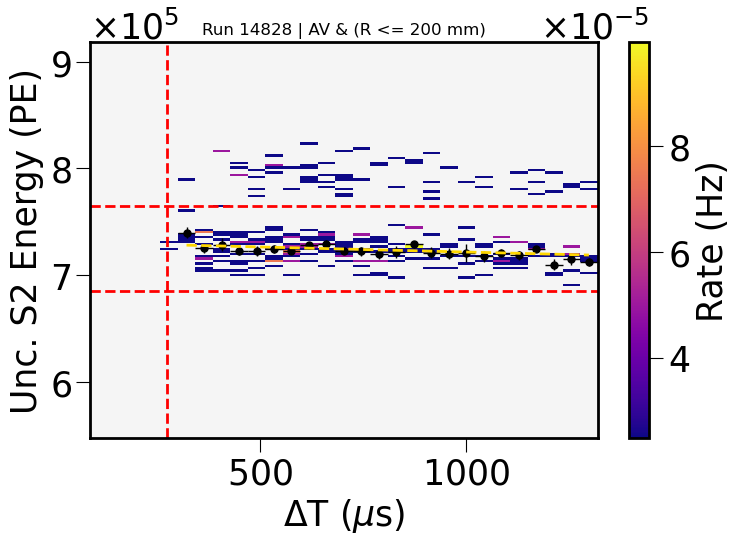

Run 14829 fit: N0 = (943712.01 ± 2482.36) PE, τ = (37.25 ± 4.37) ms
χ² / ndof = 7.2553


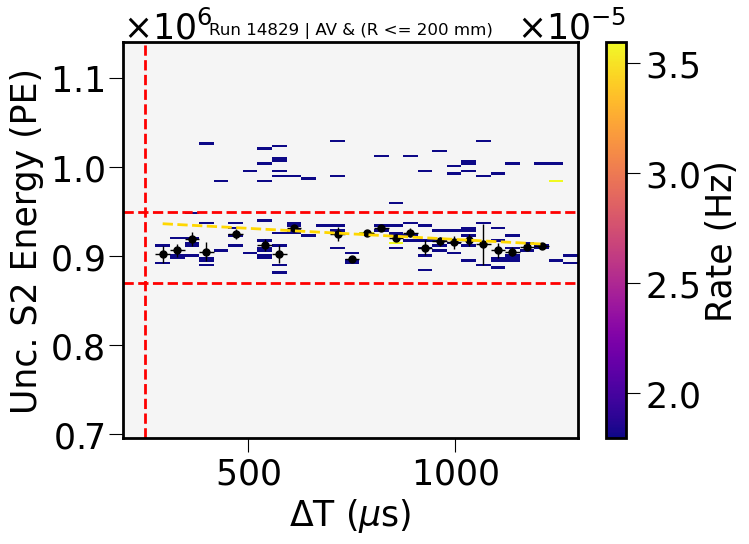

Run 14834 fit: N0 = (933636.55 ± 3795.62) PE, τ = (101.85 ± 39.80) ms
χ² / ndof = 7.3479


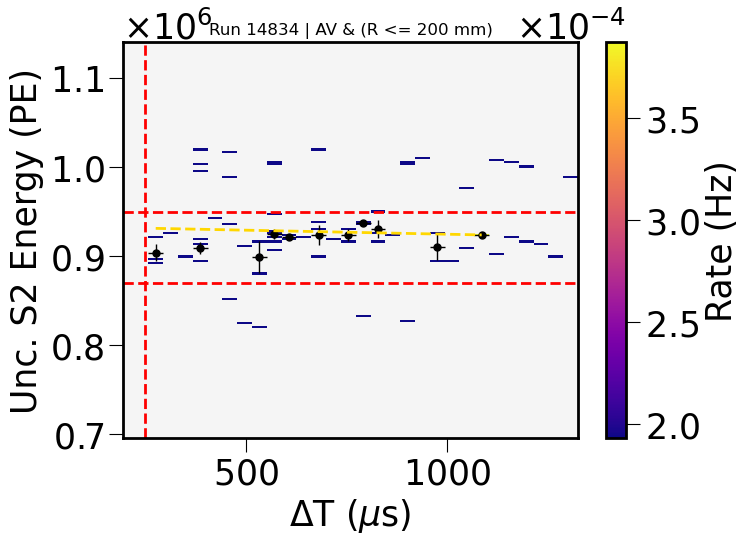

Run 14835 fit: N0 = (933004.75 ± 2976.39) PE, τ = (40.26 ± 5.13) ms
χ² / ndof = 2.5494


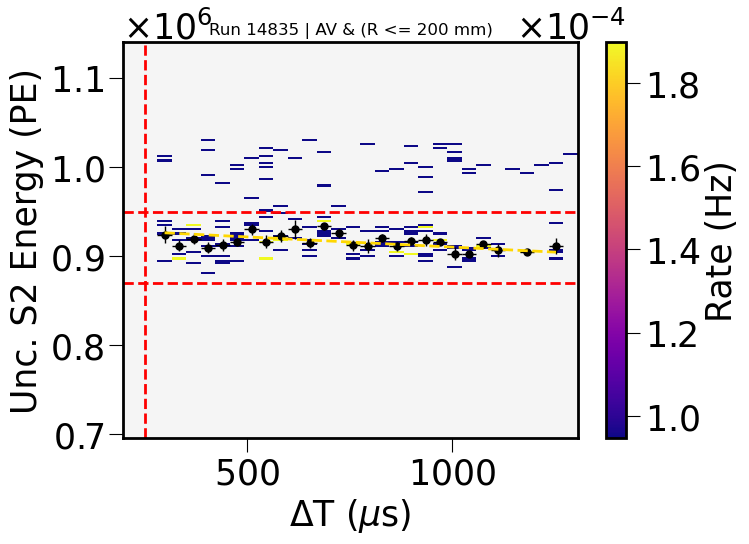

Run 14837 fit: N0 = (921855.05 ± 1852.06) PE, τ = (64.21 ± 10.13) ms
χ² / ndof = 1.4313


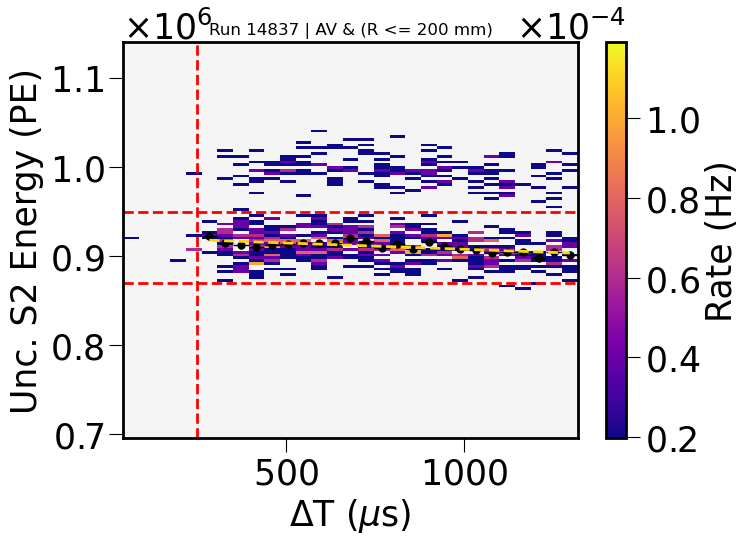

Run 14838 fit: N0 = (920062.33 ± 1512.21) PE, τ = (103.29 ± 20.73) ms
χ² / ndof = 2.2270


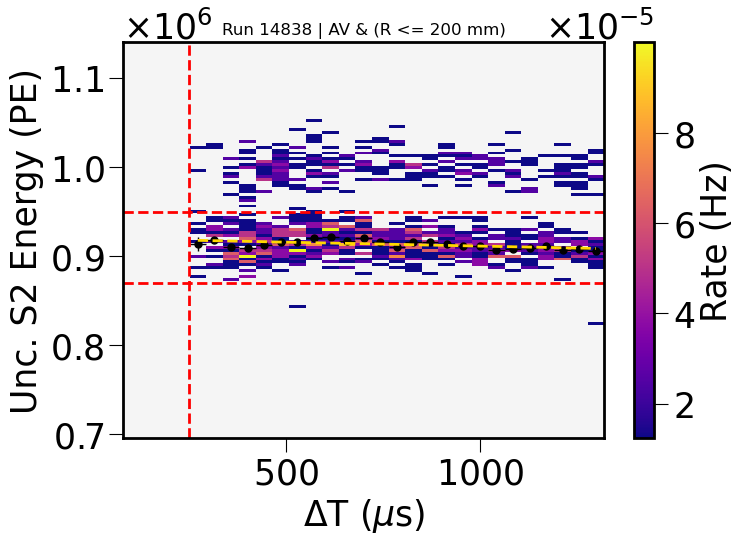

Run 14839 fit: N0 = (924914.90 ± 1509.67) PE, τ = (70.30 ± 9.67) ms
χ² / ndof = 2.6974


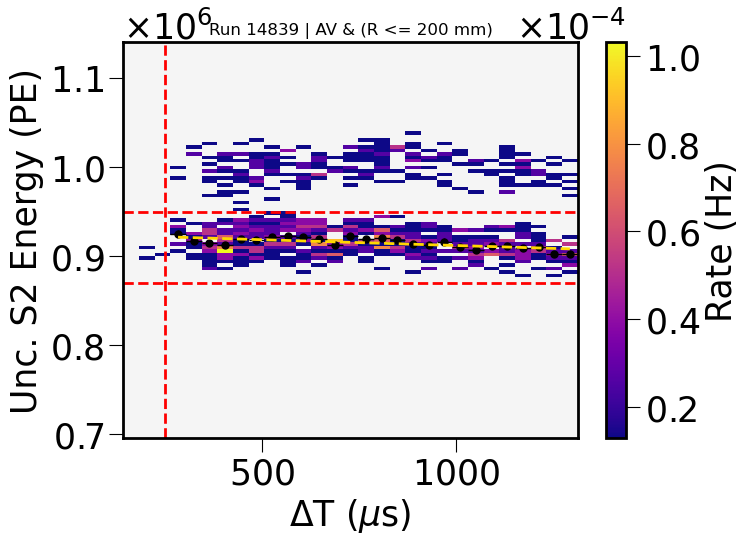

Run 14840 fit: N0 = (921111.11 ± 1752.67) PE, τ = (104.80 ± 27.19) ms
χ² / ndof = 1.7997


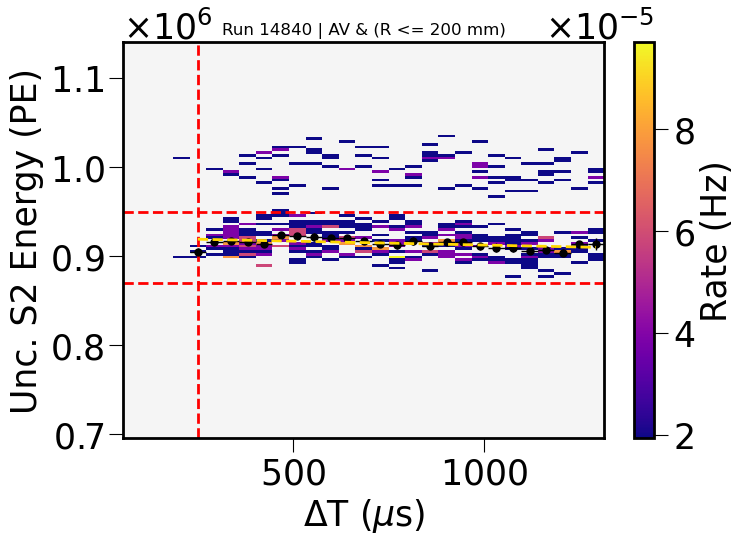

In [20]:
# Global
rad_lim = 200
x_bins  = 30
y_bins  = 400

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
    # Variables    
    E2 = SEL_DATA[run_id]['S2e']
    DT = SEL_DATA[run_id]['DT']
    R  = SEL_DATA[run_id]['R']
    W2 = SEL_DATA[run_id]['S2w']

    # Masking
    rad_mask = (R <= rad_lim)
    s2w_mask = (W2 > s2w_lim)
    E2_mask  = E2[AV_mask[run_id] & rad_mask & s2w_mask]
    DT_mask  = DT[AV_mask[run_id] & rad_mask & s2w_mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E2_mask, x_bins=x_bins, y_bins=y_bins)
    S2e_DT_map         = S2e_DT_map / (run_long * DAQe_CV)                           
    S2e_DT_map         = np.ma.masked_where(S2e_DT_map==0, S2e_DT_map)                # Zero values masked
    
    # ---- Exponential Fit ----- #
    # Preliminary
    DT_down = 350;    DT_up = DT_mask.max()
    E2_down = 770e3;  E2_up = 850e3
    if run_id in {14737, 14739, 14741, 14743, 14745, 14753, 14765}:
        E2_down = 780e3;  E2_up = 860e3
    if run_id in {14780, 14782, 14784, 14789}:
        E2_down = 790e3;  E2_up = 870e3
    if run_id in {14803, 14804, 14811, 14814, 14815, 14816, 14817, 14828}:
        DT_down = 275;    DT_up = DT_mask.max()
        E2_down = 685e3;  E2_up = 765e3
    elif run_id in {14829, 14834, 14835, 14837, 14838, 14839, 14840}:
        DT_down = 250;    DT_up = DT_mask.max()
        E2_down = 870e3;  E2_up = 950e3

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E2_mask >= E2_down) & (E2_mask <= E2_up)
    DT_fit = DT_mask[fit_region_mask]
    E2_fit = E2_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S2e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S2e_means  = S2e_means[valid_points];       S2e_errors = S2e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
    init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]
    # print(f'\nInitial guess: N0 = {init_guess[0]:.4f} PE, tau = {init_guess[1]:.4f} μs')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Run {run_id} fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')
    FIT_PARAMETERS[run_id]["S2e"] = {"N0_CV": popt[0], "N0_err": perr[0], "tau_CV": popt[1], "tau_err": perr[1]}
    
    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))

    # Data
    plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap='plasma', shading='auto')
    cbar = plt.colorbar(label='Rate (Hz)', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = exp_bfixed(DT_centers, *popt)
    plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
    plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
    plt.axvline(x=DT_down, c='red', ls='--')
    plt.axhline(y=E2_down, c='red', ls='--')
    plt.axhline(y=E2_up, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    # plt.xlim(0, DT_mask.max())
    plt.ylabel('Unc. S2 Energy (PE)') 
    plt.ylim(0.8*E2_down, 1.2*E2_up)
    # plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'Run {run_id} | AV & (R <= {rad_lim} mm)', fontsize=12, loc='center')

    plt.gca().set_facecolor("whitesmoke")
    # plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/S2e_DT_fit_run{run_id}.pdf')
    plt.tight_layout()
    plt.show() 

### Lifetime Evolution

In [21]:
# Global
Date      = []
Date_err  = []
Lifet     = []
Lifet_err = []
Run_number = []

def const_func(x, b):
    return crudo.ff.linear_func(x, 0, b)

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    
    # Skip runs with low stats < 10k events
    if run_id in {14716, 14814, 14828, 14829, 14834, 14835, 14837, 14838, 14839, 14840}:
        print(f"Skipping run {run_id}: What a bad fit! (low stat)")  
        continue

    # Skip weirdos
    if run_id in {14803, 14804, 14811, 14815, 14816, 14817}:  
        print(f"Skipping run {run_id}: What is that bend?")  
        continue

    Run_number.append(run_id)
    
    # Variables    
    Time = SEL_DATA[run_id]['time']
    
    # Mean date + error for each run
    date_CV    = Time.mean()
    Date.append(date_CV)
    date_error = Time.std() / np.sqrt(len(Time))
    Date_err.append(date_error)

    # Retrieve lifetime fit value   
    LT_CV    = FIT_PARAMETERS[run_id]['S2e']['tau_CV']  / 1e3     # In [ms]
    Lifet.append(LT_CV)
    LT_error = FIT_PARAMETERS[run_id]['S2e']['tau_err'] / 1e3
    Lifet_err.append(LT_error)

Skipping run 14716: What a bad fit! (low stat)
Skipping run 14803: What is that bend?
Skipping run 14804: What is that bend?
Skipping run 14811: What is that bend?
Skipping run 14814: What a bad fit! (low stat)
Skipping run 14815: What is that bend?
Skipping run 14816: What is that bend?
Skipping run 14817: What is that bend?
Skipping run 14828: What a bad fit! (low stat)
Skipping run 14829: What a bad fit! (low stat)
Skipping run 14834: What a bad fit! (low stat)
Skipping run 14835: What a bad fit! (low stat)
Skipping run 14837: What a bad fit! (low stat)
Skipping run 14838: What a bad fit! (low stat)
Skipping run 14839: What a bad fit! (low stat)
Skipping run 14840: What a bad fit! (low stat)


In [22]:
# ----- Linear Fits ----- #
# Preliminary
Date      = np.array(Date)
Date_err  = np.array(Date_err)
Lifet     = np.array(Lifet)
Lifet_err = np.array(Lifet_err)

# Masking: select sepecific data
# HG_time = (Date >= 1737975600)
Fine_time = (Date < 1738716600)

x_data = Date[Fine_time]
y_data = Lifet[Fine_time]
y_err  = Lifet_err[Fine_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# We perform two different fits: constant and linear
models = [const_func, crudo.ff.linear_func]

x_fit = [[], []]
y_fit = [[], []]
chi2  = [[], []]
ndof  = [[], []]

for i, func in enumerate(models):

    # Define the cost function + initial guess
    least_squares = LeastSquares(x_shift, y_data, y_err, func)
    init_guess    = []

    if func == const_func:
        init_guess = [y_data.mean()]
    elif func == crudo.ff.linear_func:
        init_guess = [10.0, y_data.min()]

    print(f'Fit {i+1}:\nInitial guess: {init_guess}')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"Results:")
    for param, value, error in zip(m.parameters, popt, perr):
        print(f"  {param}: {value:.4f} ± {error:.4f}")

    if func == const_func:
        LIFETIME = popt[0] * 1e3  # In [μs] for later calculations

    # Reduced chi-square
    chi2[i] = m.fval
    ndof[i] = len(x_shift) - m.nfit
    print(f"χ² / ndof = {chi2[i] / ndof[i]:.4f}\n")

    # Fits
    x_fit[i] = (x_shift * 3600) + x_data[0]  # In [s]
    y_fit[i] = func(x_shift, *popt)

Fit 1:
Initial guess: [52.8861575064065]
Results:
  b: 51.7707 ± 0.7702
χ² / ndof = 4.1707

Fit 2:
Initial guess: [10.0, 43.24440200133412]
Results:
  m: -0.0211 ± 0.0060
  b: 56.1275 ± 1.4582
χ² / ndof = 3.5392



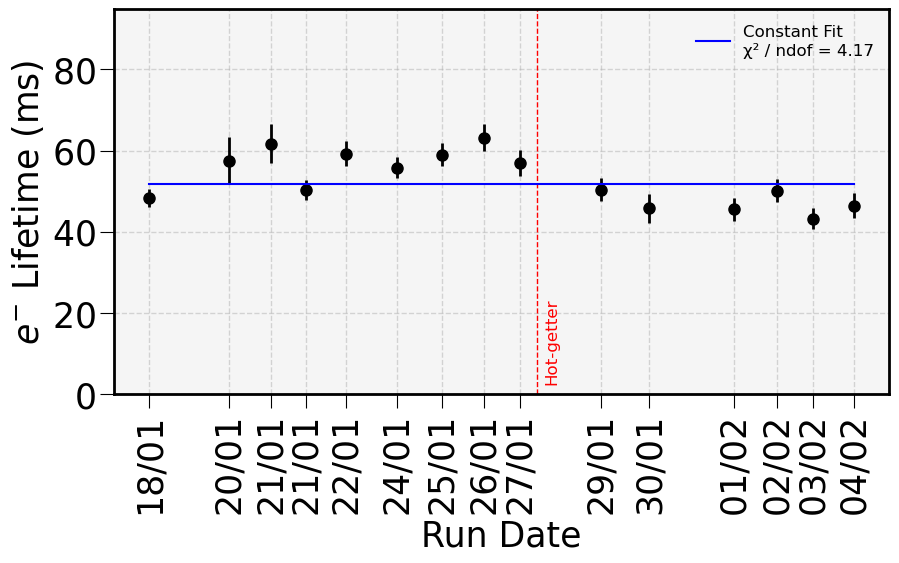

In [23]:
# ----- Plotting ----- #
plt.figure(figsize=(10, 5))
# Data
plt.errorbar(Date, Lifet, xerr=Date_err, yerr=Lifet_err, fmt='o', c='black', ecolor='black', zorder=2)
# for x, y, run_id in zip(Date, Lifet, Run_number):
#     plt.text(x, y, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')  # Run number near the point

# Fits
plt.plot(x_fit[0], y_fit[0], color='blue', ls='-', lw=1.5, label=f'Constant Fit\nχ² / ndof = {chi2[0] / ndof[0]:.2f}', zorder=3)
# plt.plot(x_fit[1], y_fit[1], color='orange', ls='--', label=f'Linear Fit\nχ² / ndof = {chi2[1] / ndof[1]:.2f}')

# Important dates
plt.axvline(x=1737975600, c='red', ls='--', lw=1.0)
plt.text(1738030000-1e4, 2.5, 'Hot-getter', fontsize=12, c='red', va='bottom',  ha='right',  rotation=90)

# ----- Styling ----- #
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]  # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, rotation=90, ha='center')
plt.ylim(0, 1.5 * Lifet.max())
plt.ylabel(r'$e^{-}$ Lifetime (ms)')
# plt.title(r'$e^{-}$ Lifetime Evolution')
plt.legend(loc='upper right', fontsize=12, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Radon_LPR/images/Lifetime_Evolution.pdf')
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Lifetime_Evolution.pdf')
plt.show()

What's the maximum factor of correction? (@ cathode)

In [24]:
# Any maximum DT value
max_DT = DT_stop[14739]
print(f"Correction by lifetime @ cathode (max. factor): {crudo.ff.exponential_decay(max_DT, 1, LIFETIME, 0):.2%}")

Correction by lifetime @ cathode (max. factor): 97.48%


# Energy Corrections

We perform energy corrections exclusively for the runs categorized as:

- **High $^{222}\text{Rn }\rightarrow$** 14739
- **Low $^{222}\text{Rn }\,\,\rightarrow$** 14834, 14835, 14837, 14838, 14839, 14840

Each run corrects its $S1$ energy by itself, while the lifetime used for $S2$ energy corrections came from the above fit.
<br> 
Geometry effects in the $S2$ are adressed by the energy map of high radon run (14739).

In [25]:
# Global
n_bins  = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
        
        if run_id in HIGH_RN_RUNS:

            # Fit parameters for energy corrections
            CV_fit = [FIT_PARAMETERS[run_id]['S1e']['m_CV'],  FIT_PARAMETERS[run_id]['S1e']['b_CV']]
            LT_fit = [FIT_PARAMETERS[run_id]['S2e']['N0_CV'], LIFETIME]

            # Apply corrections
            SEL_DATA[run_id] = crudo.ef.correct_S1e   (SEL_DATA[run_id], CV_fit, DT_stop[run_id], output_column='S1e_corr')  # S1 energy
            SEL_DATA[run_id] = crudo.ef.correct_S2e_LT(SEL_DATA[run_id], LT_fit, output_column='S2e_corr_LT')                # S2 energy by lifetime

            # Generate the reference (High-Rn) energy map
            print(f"Generating energy map of reference...\nThank you run {run_id} for your stats")

            # Variables
            X_ref  = SEL_DATA[run_id]['X']
            Y_ref  = SEL_DATA[run_id]['Y']
            E2_ref = SEL_DATA[run_id]['S2e_corr_LT']

            # Generate the energy map normalized to the center
            ref_energy_map, x_edges, y_edges = crudo.ef.pt.mapping(X_ref[AV_mask[run_id]], Y_ref[AV_mask[run_id]], wei=E2_ref[AV_mask[run_id]], norm=True)

        if run_id in LOW_RN_RUNS:

            # Fit parameters for energy corrections
            CV_fit = [FIT_PARAMETERS[run_id]['S1e']['m_CV'],  FIT_PARAMETERS[run_id]['S1e']['b_CV']]
            LT_fit = [FIT_PARAMETERS[run_id]['S2e']['N0_CV'], LIFETIME]

            # Apply corrections
            SEL_DATA[run_id] = crudo.ef.correct_S1e   (SEL_DATA[run_id], CV_fit, DT_stop[run_id], output_column='S1e_corr')  # S1 energy
            SEL_DATA[run_id] = crudo.ef.correct_S2e_LT(SEL_DATA[run_id], LT_fit, output_column='S2e_corr_LT')                # S2 energy by lifetime

        print(f"--- Processing Run {run_id} ---")

        # Apply S2 energy correction by geometric map
        SEL_DATA[run_id] = crudo.ef.correct_S2e_map_fixed(SEL_DATA[run_id], ref_energy_map, x_edges, y_edges)

Generating energy map of reference...
Thank you run 14739 for your stats
--- Processing Run 14739 ---
--- Processing Run 14834 ---
--- Processing Run 14835 ---
--- Processing Run 14837 ---
--- Processing Run 14838 ---
--- Processing Run 14839 ---
--- Processing Run 14840 ---


### S1 Energy Corrected?

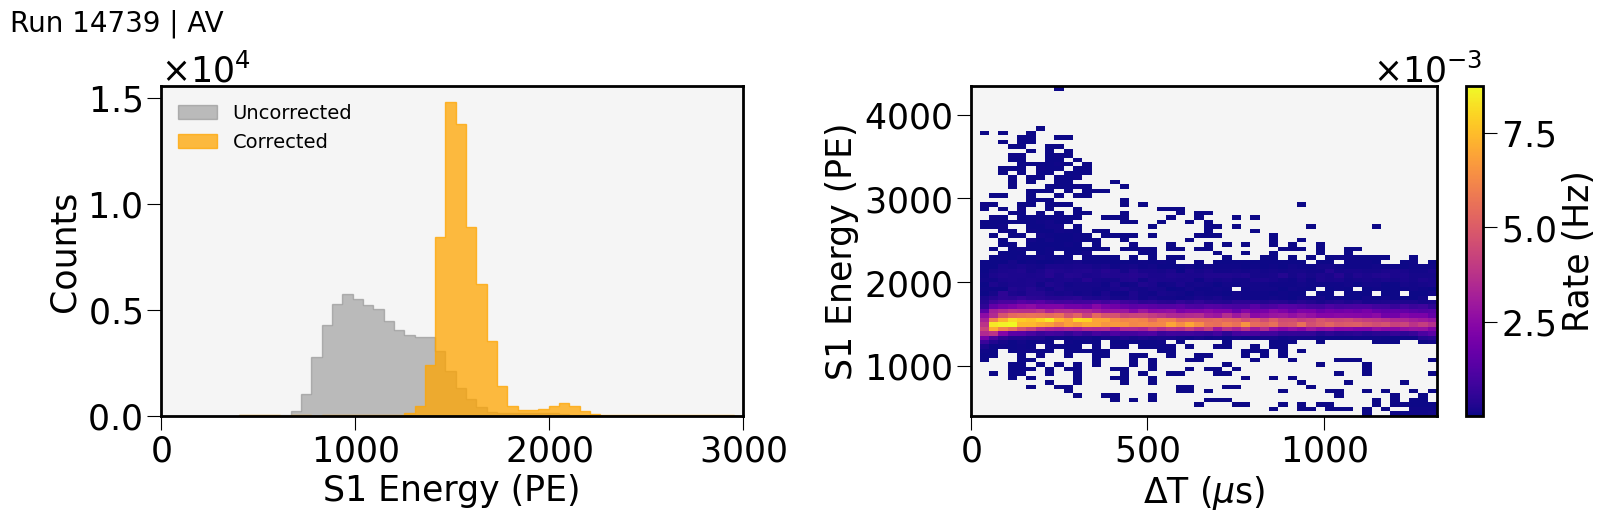

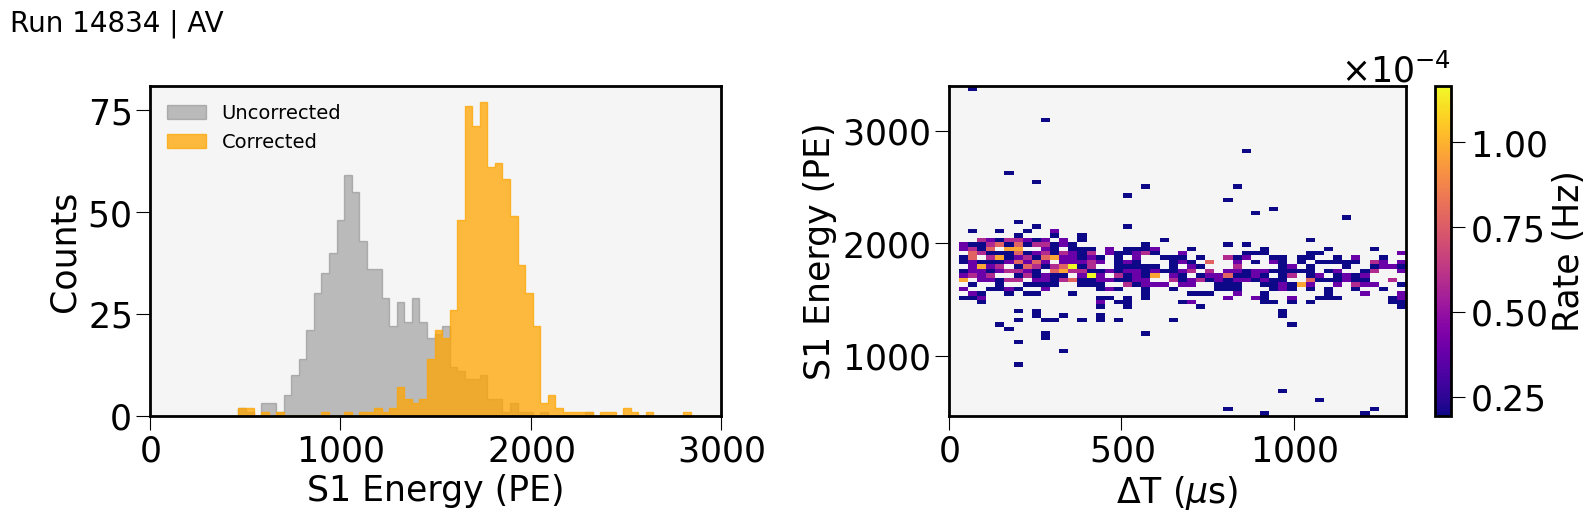

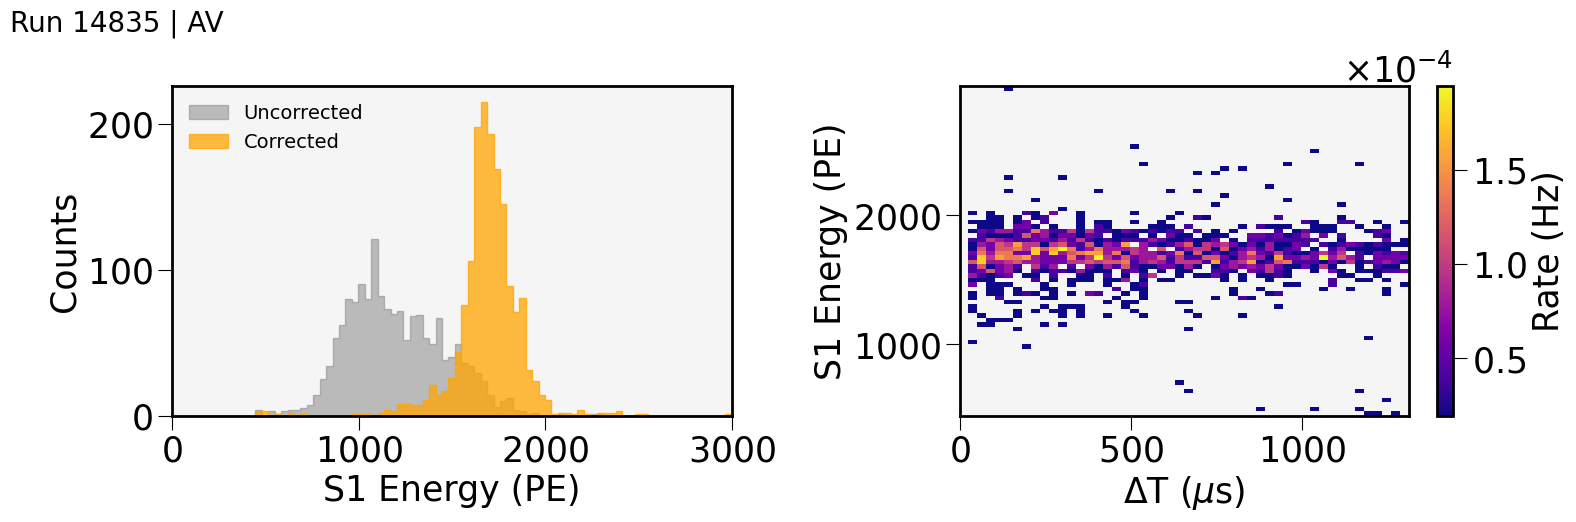

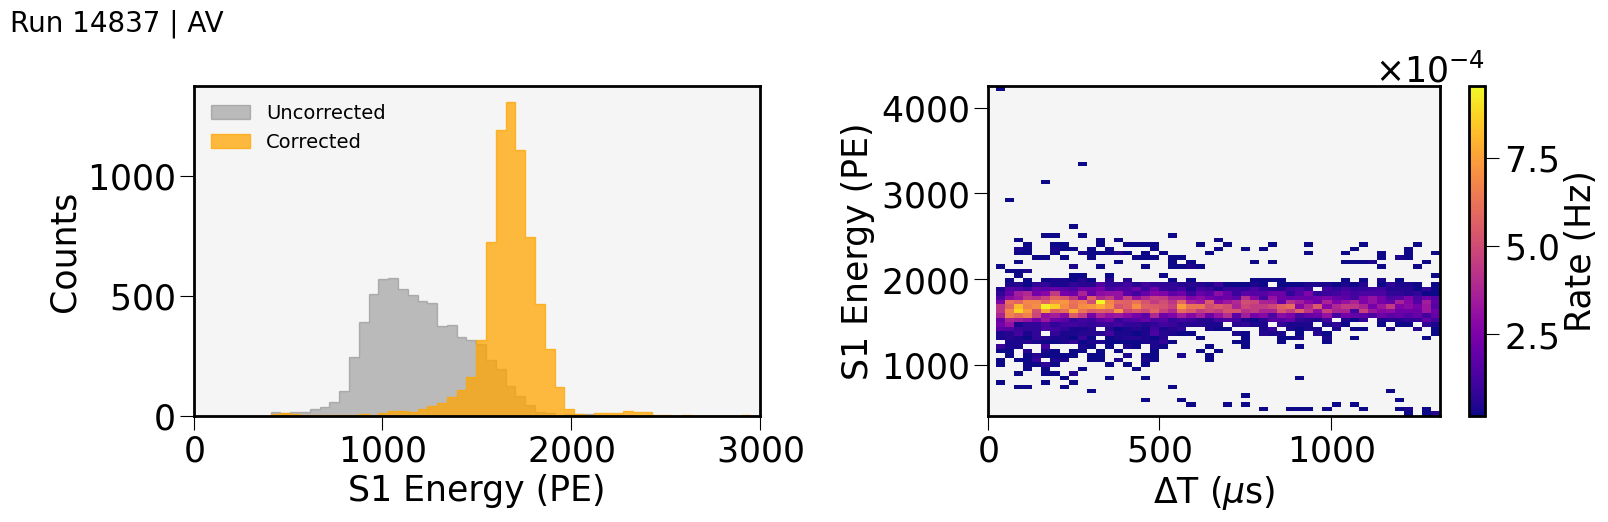

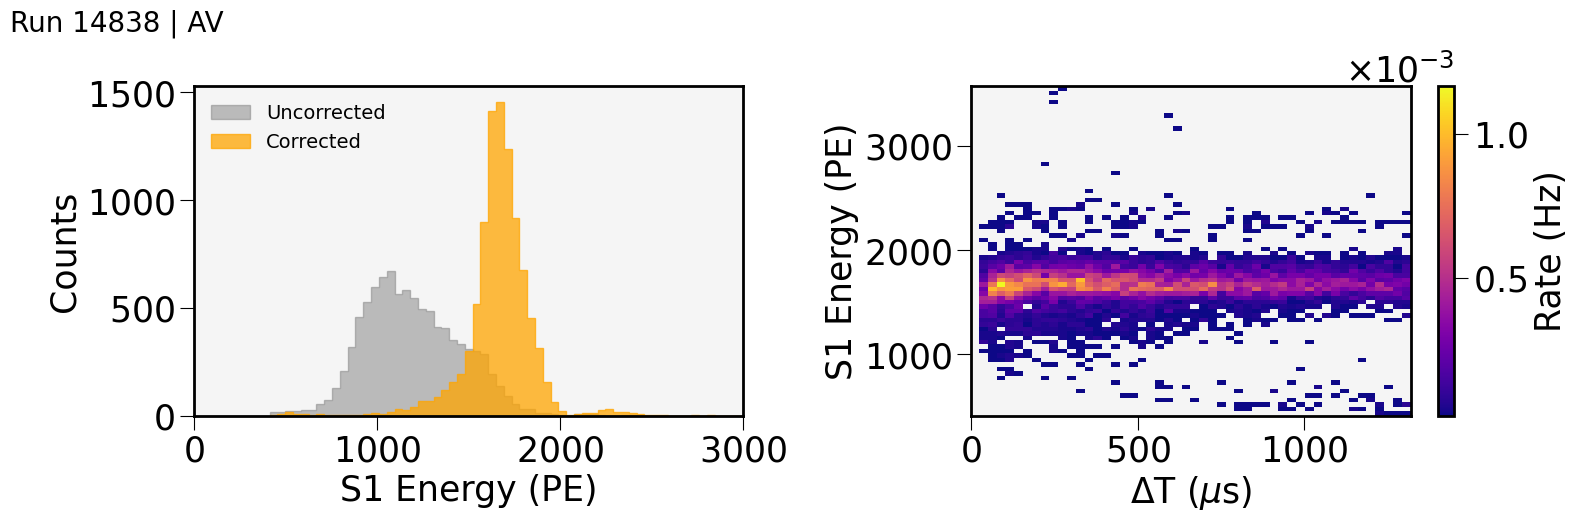

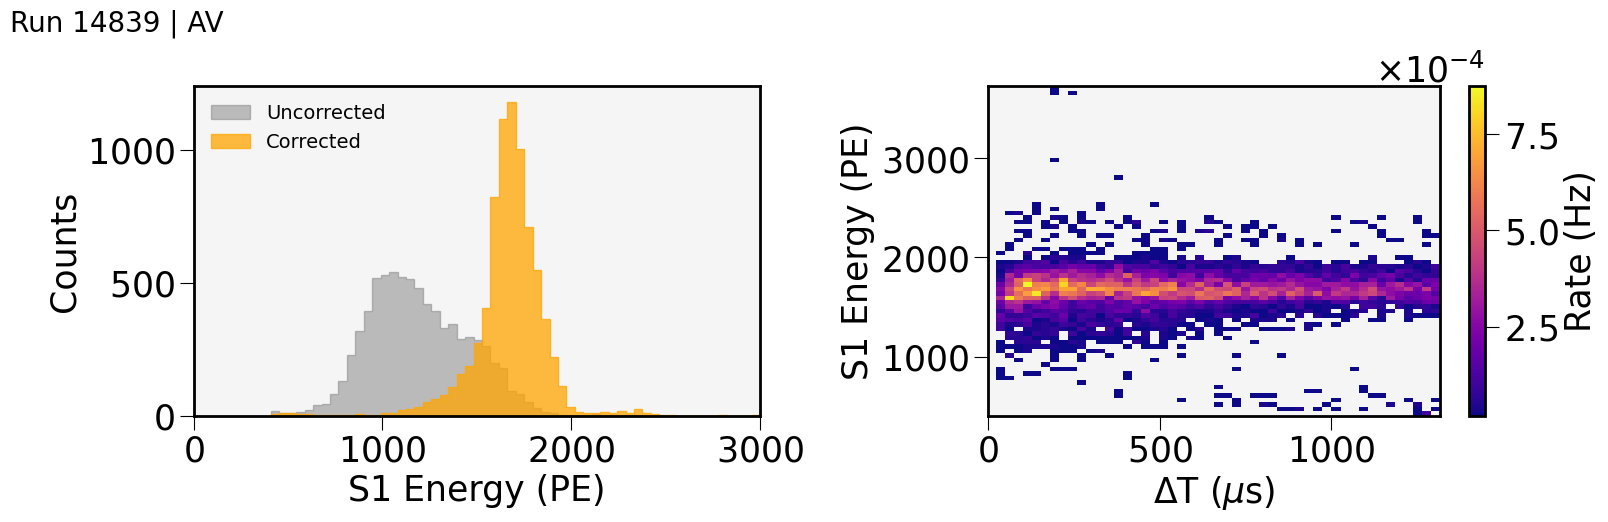

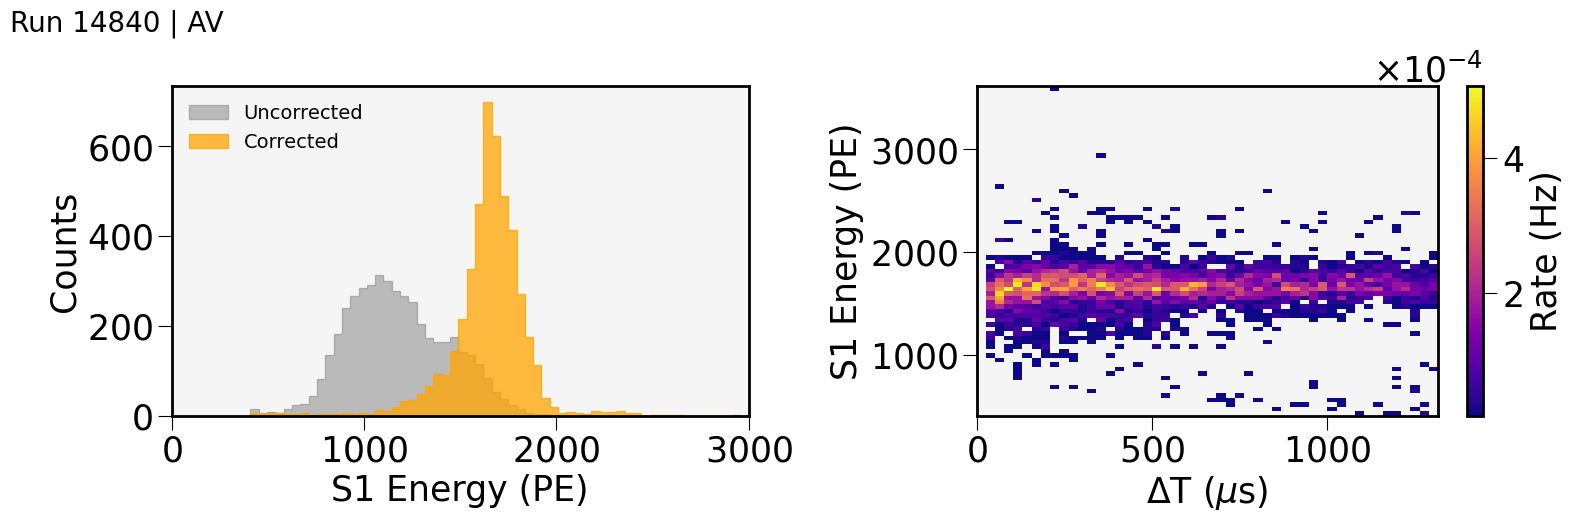

In [26]:
# Global
n_bins = 50
E1_min = 0; E1_max = 3e3

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
    
        # Variables    
        E1      = SEL_DATA[run_id]['S1e']
        E1_corr = SEL_DATA[run_id]['S1e_corr']
        DT      = SEL_DATA[run_id]['DT']

        # Masking
        E1_mask  = E1[AV_mask[run_id]]
        E1c_mask = E1_corr[AV_mask[run_id]]
        DT_mask  = DT[AV_mask[run_id]]

        # 2D histogram: normalized by corrected DAQ data taking time
        S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1c_mask, x_bins=n_bins, y_bins=75)
        S1e_DT_map         = S1e_DT_map / (run_long * DAQe_CV)                           
        S1e_DT_map         = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)  # Zero values masked

        # ----- Plotting ----- #
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left
        axes[0].hist(E1_mask, bins=ey, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
        axes[0].hist(E1c_mask, bins=ey, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
        axes[0].set_xlabel('S1 Energy (PE)')
        axes[0].set_xlim(E1_min, E1_max)
        axes[0].set_ylabel('Counts')
        axes[0].legend(loc='upper left', fontsize=14, facecolor='none')
        axes[0].set_facecolor('whitesmoke')

        # Right
        pcm = axes[1].pcolormesh(ex, ey, S1e_DT_map.T, cmap='plasma', shading='auto')
        cbar = fig.colorbar(pcm, ax=axes[1], label='Rate (Hz)')
        axes[1].set_xlabel('$\Delta$T ($\mu$s)')
        axes[1].set_xlim(0, DT_mask.max())
        axes[1].set_ylabel('S1 Energy (PE)')
        axes[1].set_facecolor('whitesmoke')

        # Single title for the figure
        fig.suptitle(f'Run {run_id} | AV', fontsize=20, x=0, y=0.9, ha='left')

        plt.tight_layout()
        plt.show()

### S2 Energy Corrected?

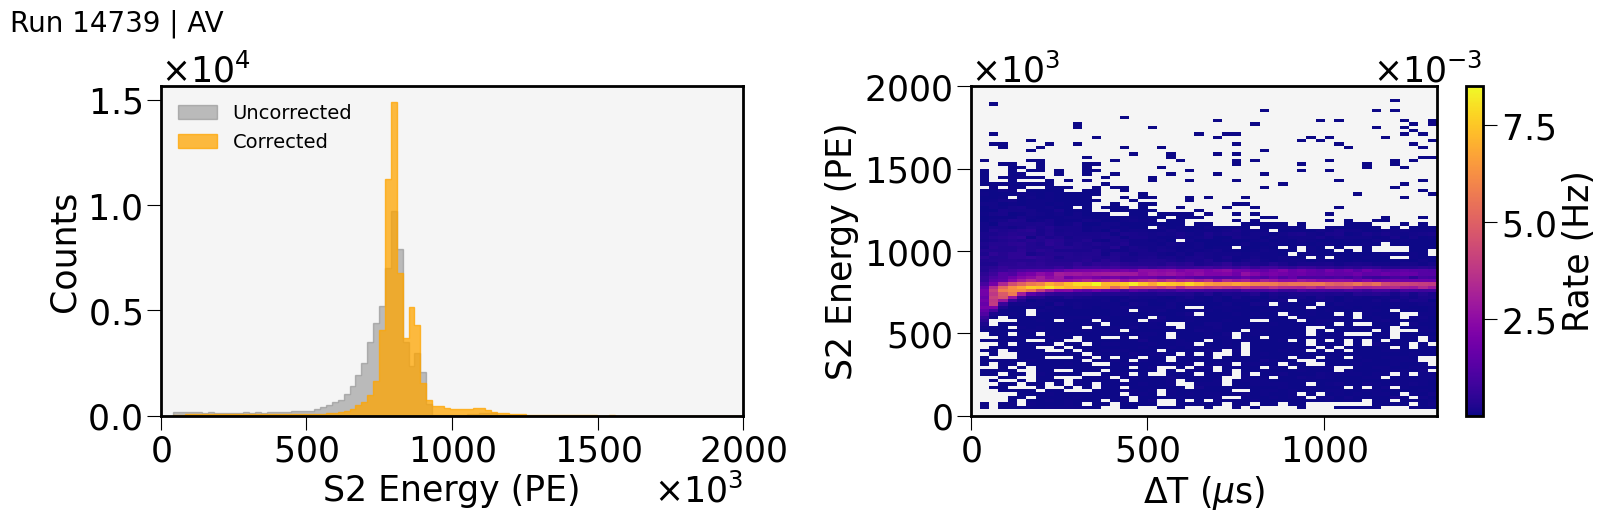

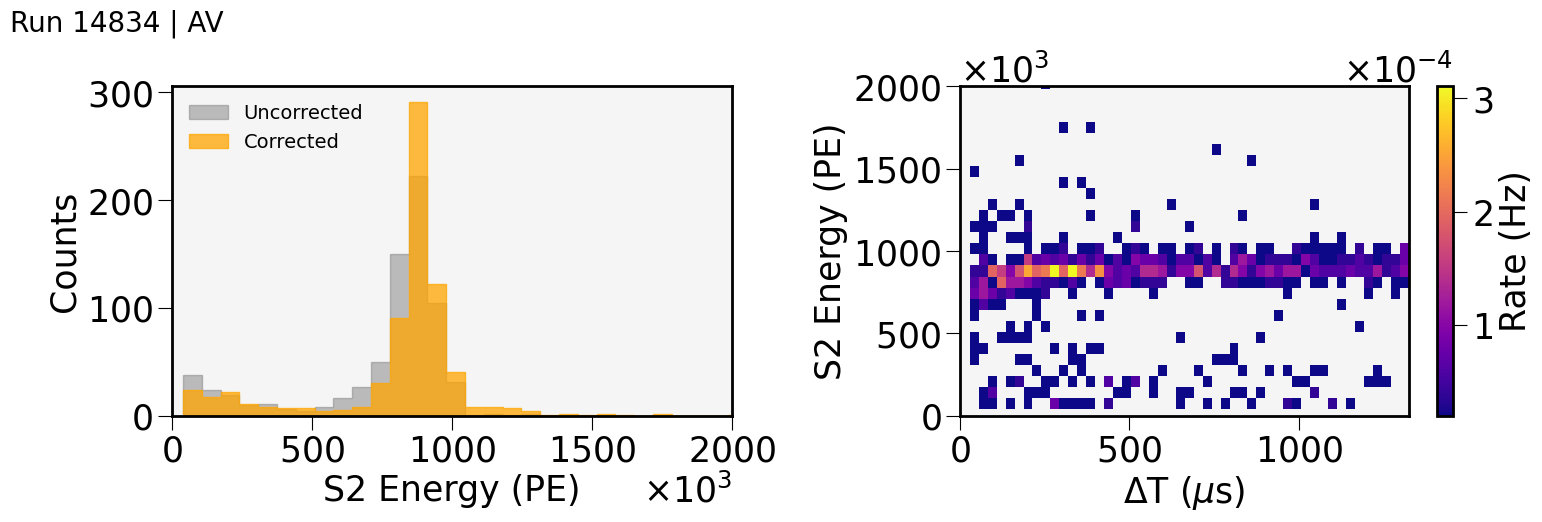

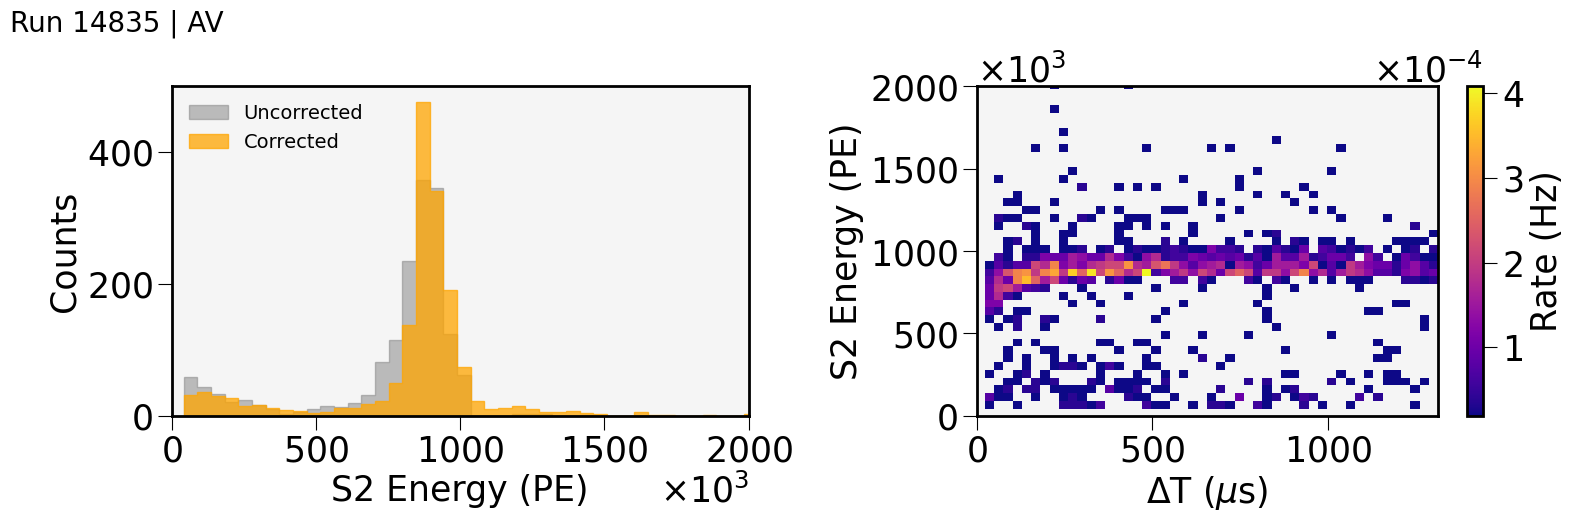

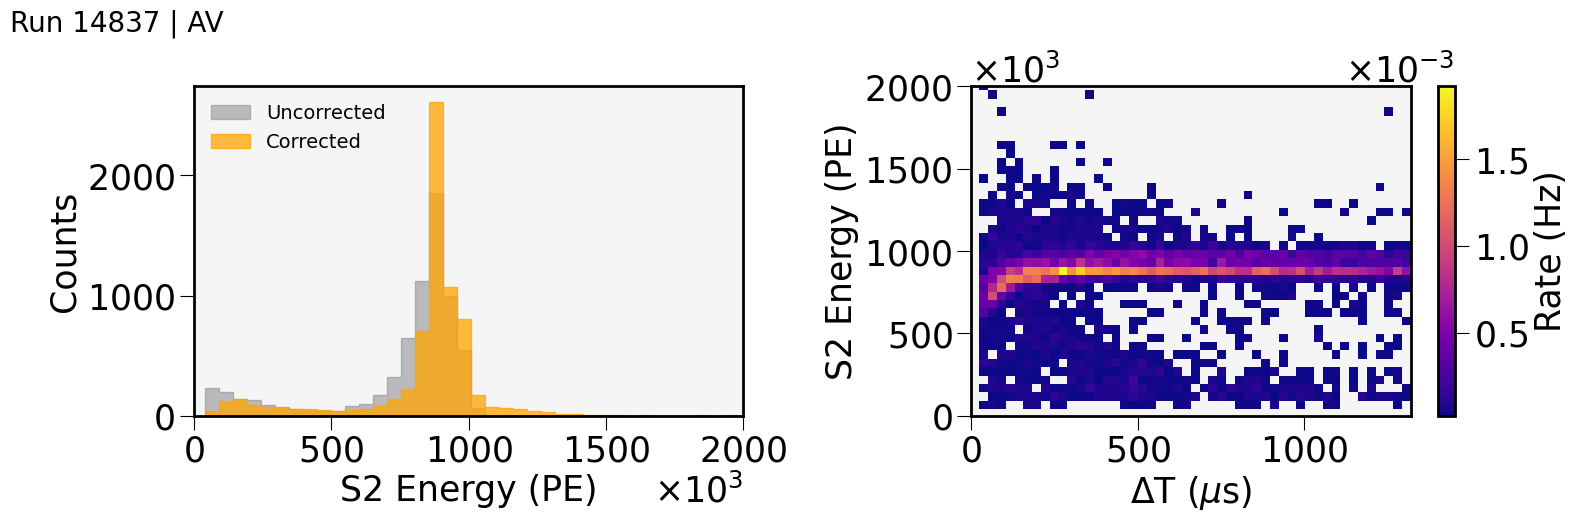

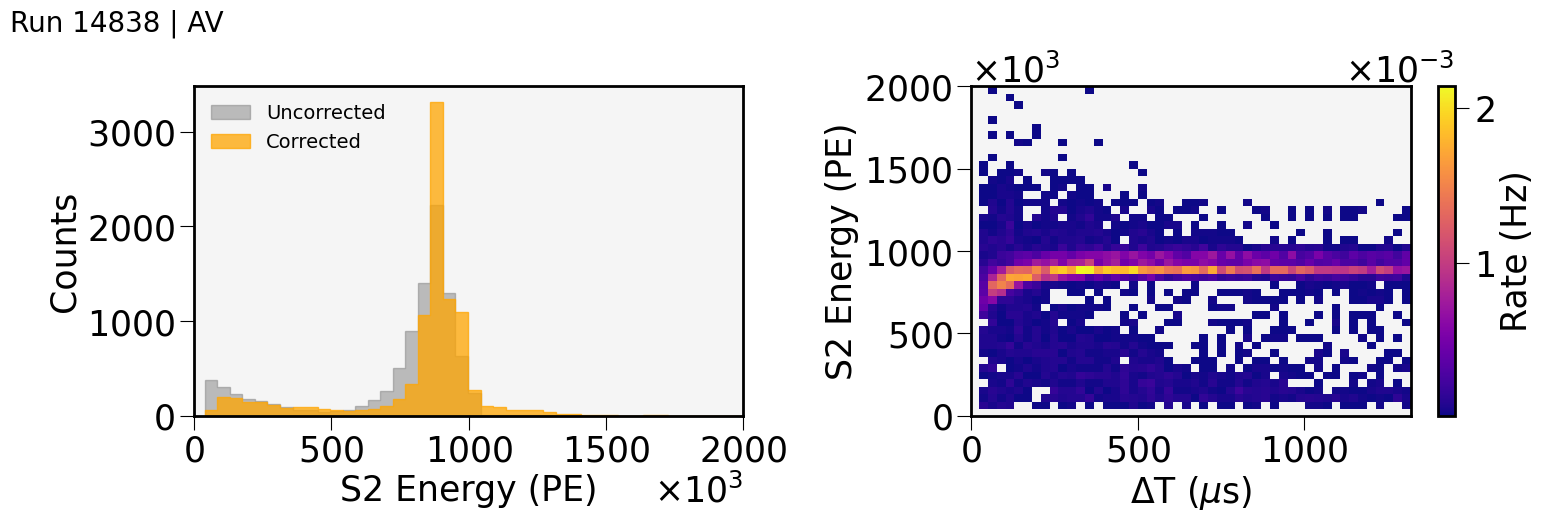

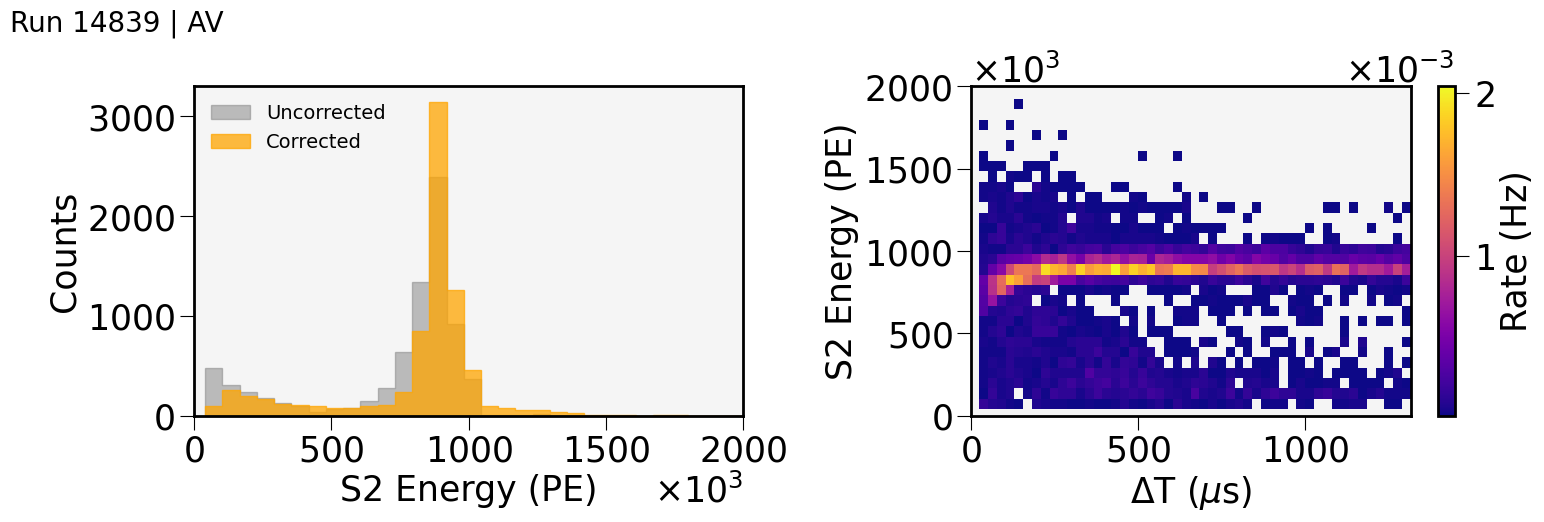

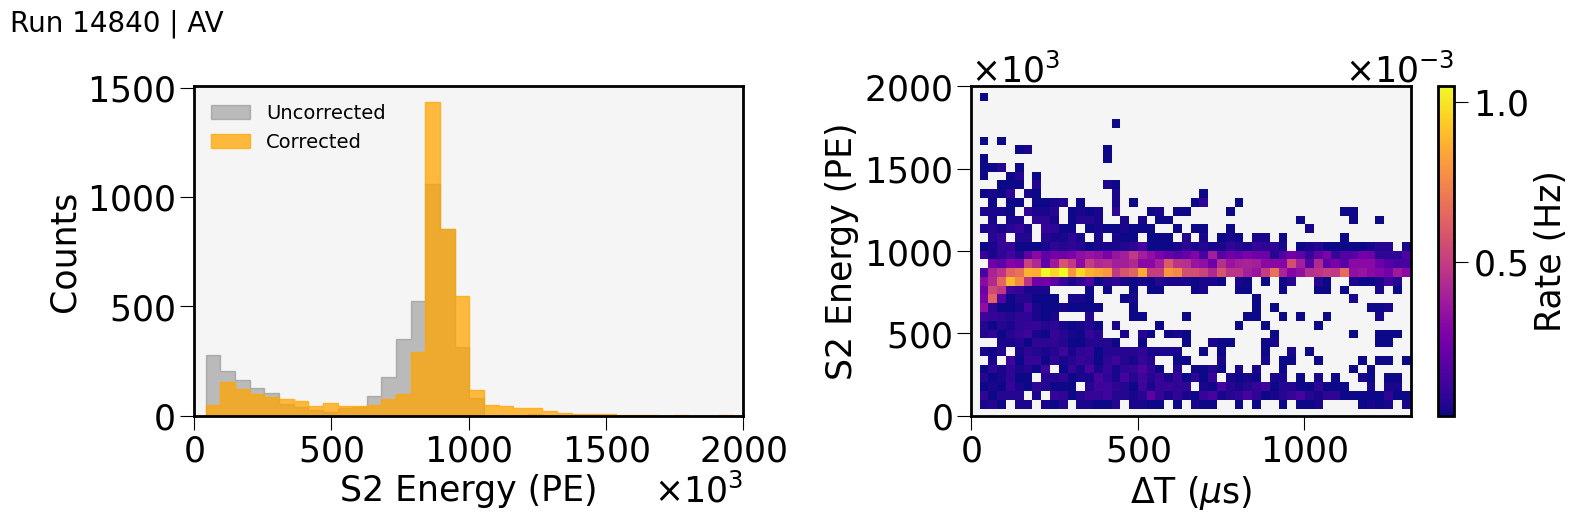

In [27]:
# Global
n_bins = 50
E2_min = 0;  E2_max = 2000e3

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
    
        # Variables    
        E2      = SEL_DATA[run_id]['S2e']
        E2_corr = SEL_DATA[run_id]['S2e_corr']
        DT      = SEL_DATA[run_id]['DT']

        # Masking
        E2_mask = E2[AV_mask[run_id]]
        E_mask  = E2_corr[AV_mask[run_id]]
        DT_mask = DT[AV_mask[run_id]]

        # 2D histogram: normalized by corrected DAQ data taking time
        S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E_mask, x_bins=n_bins, y_bins=100)
        S2e_DT_map         = S2e_DT_map / (run_long * DAQe_CV)                           
        S2e_DT_map         = np.ma.masked_where(S2e_DT_map == 0, S2e_DT_map)  # Zero values masked

         # ----- Plotting ----- #
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left
        axes[0].hist(E2_mask, bins=ey, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
        axes[0].hist(E_mask, bins=ey, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
        axes[0].set_xlabel('S2 Energy (PE)')
        axes[0].set_xlim(E2_min, E2_max)
        axes[0].set_ylabel('Counts')
        axes[0].ticklabel_format(axis='x', style='sci', scilimits=(3,3))
        axes[0].legend(loc='upper left', fontsize=14, facecolor='none')
        axes[0].set_facecolor('whitesmoke')

        # Right
        pcm = axes[1].pcolormesh(ex, ey, S2e_DT_map.T, cmap='plasma', shading='auto')
        cbar = fig.colorbar(pcm, ax=axes[1], label='Rate (Hz)')
        axes[1].set_xlabel('$\Delta$T ($\mu$s)')
        axes[1].set_xlim(0, DT_mask.max())
        axes[1].set_ylim(E2_min, E2_max)
        axes[1].set_ylabel('S2 Energy (PE)')
        axes[1].ticklabel_format(axis='y', style='sci', scilimits=(3,3))
        axes[1].set_facecolor('whitesmoke')

        # Single title for the figure
        fig.suptitle(f'Run {run_id} | AV', fontsize=20, x=0, y=0.9, ha='left')

        plt.tight_layout()
        plt.show()

# High & Low-Rn Information

Not all the OK triggers correspond to alpha events.
<br>
Pau estimated the percentage of these triggers that are alphas through a discrimination in the $S1$ pulse. This value is what we call __alphas triggers__.


In [31]:
# Storage of Low_Rn dataframes
dfs = []          
# Low_Rn values: CV + error calculations
low_long = 0
low_trigg_CV = 0;  low_trigg_err = 0
low_reco_CV  = 0;  low_reco_err  = 0
low_sel_CV   = 0;  low_sel_err   = 0

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]    
    run_OK   = entry["OK"] 
    run_LOST = entry["LOST"]
    
    if run_id in HIGH_RN_RUNS:

        # DAQe efficiency + error
        DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
        ANA_DATA['High_Rn']['df']            = SEL_DATA[run_id]
        ANA_DATA['High_Rn']['duration_CV']   = run_long * DAQe_CV
        # Alpha trigger rate + error
        ANA_DATA['High_Rn']['alpha_rate_CV'] = TRG_RATE_HIGH_RN_CV * ALPHA_TRG_EFF_HIGH 
        ANA_DATA['High_Rn']['alpha_rate_err_stat'] = TRG_RATE_HIGH_RN_ERR * ALPHA_TRG_EFF_HIGH 
        ANA_DATA['High_Rn']['alpha_rate_err_sys']  = (TRG_RATE_HIGH_RN_CV * ALPHA_TRG_EFF_HIGH) * TRG_EFF_ERR

    if run_id in LOW_RN_RUNS:

        # DAQe efficiency + error
        DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
        dfs.append(SEL_DATA[run_id])
        low_long     += run_long * DAQe_CV

# Low-Rn complete information
ANA_DATA['Low_Rn']['df']             = pd.concat(dfs, ignore_index=True)
ANA_DATA['Low_Rn']['duration_CV']    = low_long
ANA_DATA['Low_Rn']['alpha_rate_CV']  = TRG_RATE_LOW_RN_CV * ALPHA_TRG_EFF_LOW
ANA_DATA['Low_Rn']['alpha_rate_err_stat'] = TRG_RATE_LOW_RN_ERR * ALPHA_TRG_EFF_LOW
ANA_DATA['Low_Rn']['alpha_rate_err_sys']  = (TRG_RATE_LOW_RN_CV * ALPHA_TRG_EFF_LOW) * TRG_EFF_ERR

In [32]:
print("\n--- Summary of Analysis Data ---")
for key in ANA_DATA.keys():
    print(f"\n{key.upper()}:")
    for subkey in ANA_DATA[key].keys():
        if subkey == 'df':
            continue
        print(f" {subkey} = {ANA_DATA[key][subkey]:.4f}")


--- Summary of Analysis Data ---

HIGH_RN:
 duration_CV = 45718.5134
 alpha_rate_CV = 42.5056
 alpha_rate_err_stat = 0.2100
 alpha_rate_err_sys = 4.2506

LOW_RN:
 duration_CV = 275250.9194
 alpha_rate_CV = 1.1896
 alpha_rate_err_stat = 0.0526
 alpha_rate_err_sys = 0.1190


# Spatial Distributions

### Drift Time

First, let's estimate the drift time to avoid the cathode in both datasets for future analysis.

In [34]:
# Global
n_bins = 80
step_back = 2       # To avoid completely the cathode

for i, entry in enumerate(ANA_DATA):
    
    Rn_data = ANA_DATA[entry]['df']
    
    # Variables
    DT = Rn_data['DT']
    # Compute histogram avoiding negative values of DT (just in case)
    counts, bins = np.histogram(DT, bins=n_bins, range=(0, DT.max()))
    # Find the index of the bin with the highest count (cathode peak)
    cath_index = np.argmax(counts)
    
    # Ensure step_back is valid
    if cath_index - step_back < 0:
        raise ValueError(f"Warning: Invalid step back for {entry}.")
    else:
        # Compute DT_stop by stepping back from the cathode peak
        ANA_DATA[entry]['DTstop_CV']  = (bins[cath_index - step_back] + bins[cath_index - step_back + 1]) / 2
        ANA_DATA[entry]['DTstop_err'] = (bins[cath_index - step_back + 1] - bins[cath_index - step_back]) / 2
        
    print(f"{entry}:\n  DT stop = ({ANA_DATA[entry]['DTstop_CV']:.2f} ± {ANA_DATA[entry]['DTstop_err']:.2f}) μs")

High_Rn:
  DT stop = (1311.44 ± 9.17) μs
Low_Rn:
  DT stop = (1310.82 ± 9.17) μs


High_Rn:
Cathode time position = (1350.08 +/- 9.02) μs
Drift velocity = (0.87 +/- 0.01) mm/μs 

Low_Rn:
Cathode time position = (1350.08 +/- 9.02) μs
Drift velocity = (0.87 +/- 0.01) mm/μs 



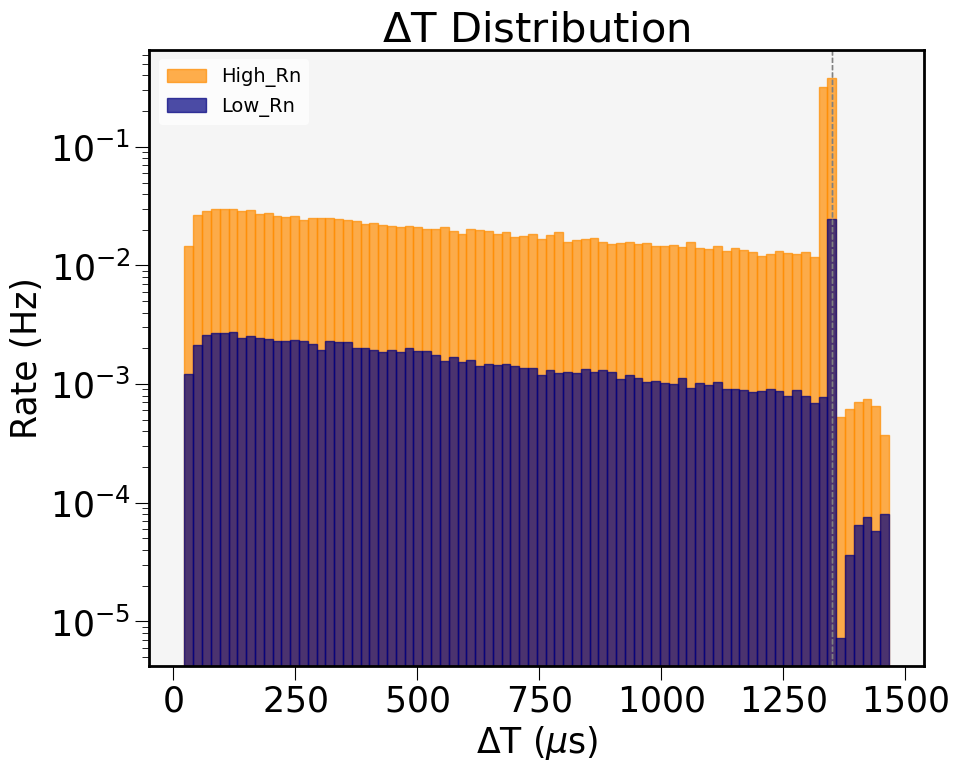

In [35]:
# Store important information
m_DT = {"High_Rn":{}, "Low_Rn":{}}  # Slopes from linear fit

# Global
n_bins = 80
DT_min = 400        # Lower limit for linear fit
color_index = 0     # Histogram color counter

# ----- Binning ----- #
data_std = ANA_DATA['High_Rn']['df']
_, DT_edges = np.histogram(data_std['DT'], bins=n_bins)

for i, entry in enumerate(ANA_DATA):
    
    Rn_data = ANA_DATA[entry]['df']
    Rn_long = ANA_DATA[entry]['duration_CV']
    
    # Variables
    DT = Rn_data['DT']

    # Histogram: normalized by corrected DAQ data taking time
    DT_counts, _ = np.histogram(DT, bins=DT_edges,  range=(0, DT.max()), density=False)
    DT_rate   = DT_counts / Rn_long
    bin_width = np.diff(DT_edges).mean()
    
    # Estimated cathode time position + error
    cath_index   = np.argmax(DT_counts)         # Index of the bin with the highest count
    cath_central = (DT_edges[cath_index] + DT_edges[cath_index + 1]) / 2      # Central value of the bin
    cath_error   = bin_width / 2

    # Drift velocity + error
    drift_vel      = (crudo.pt.N100_hei - crudo.pt.EL_hei) / cath_central
    drift_error    = drift_vel * (cath_error / cath_central)
    ANA_DATA[entry]['drift_vel_CV']  = drift_vel
    ANA_DATA[entry]['drift_vel_err'] = drift_error

    print(f'{entry}:')
    print(f'Cathode time position = ({cath_central:.2f} +/- {cath_error:.2f}) μs')
    print(f'Drift velocity = ({drift_vel:.2f} +/- {drift_error:.2f}) mm/μs \n')

    # Plot the normalized histogram + cathode line
    plt.bar(DT_edges[:-1], DT_rate, width=bin_width, align='edge', 
            color=crudo.pt.hist_colors[(3*i+2) % len(crudo.pt.hist_colors)], ec=crudo.pt.hist_colors[(3*i+2) % len(crudo.pt.hist_colors)],
            alpha=0.7, lw=1.0 , label=f'{entry}')         
    plt.axvline(x=cath_central, c='gray', ls='--', lw=1)  # Cathode line

    # ----- Linear fit ----- #
    # Preliminary
    DT_max = ANA_DATA[entry]['DTstop_CV']
    fit_region_mask = (DT >= DT_min) & (DT <= DT_max)
    DT_fit = DT[fit_region_mask]

    # Compute representative values for the fit
    fit_centers, _, fit_values, y_errors = crudo.ff.prefit_1D(DT_fit, DT_edges)
    # Filter out points with zero error (bins with 1 event)
    valid_points = y_errors > 0
    fit_centers = fit_centers[valid_points]
    fit_values  = fit_values[valid_points]

    popt, pcov = curve_fit(crudo.ff.linear_func, fit_centers, fit_values)
    m_DT[entry] = {'CV': popt[0], 'Error': np.sqrt(pcov[0, 0])}

    # Plot fit
    fit_y = crudo.ff.linear_func(fit_centers, *popt)
    # plt.plot(fit_centers, fit_y, c='red', ls='--', lw=1.5)

    color_index += 1
        
# ----- Styling ----- #
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.title(f'$\Delta$T Distribution')
plt.legend(loc='upper left', fontsize=14)

plt.gca().set_facecolor("whitesmoke")
plt.show()

### Z Distribution

Z limit (High Rn): 1143.60 mm


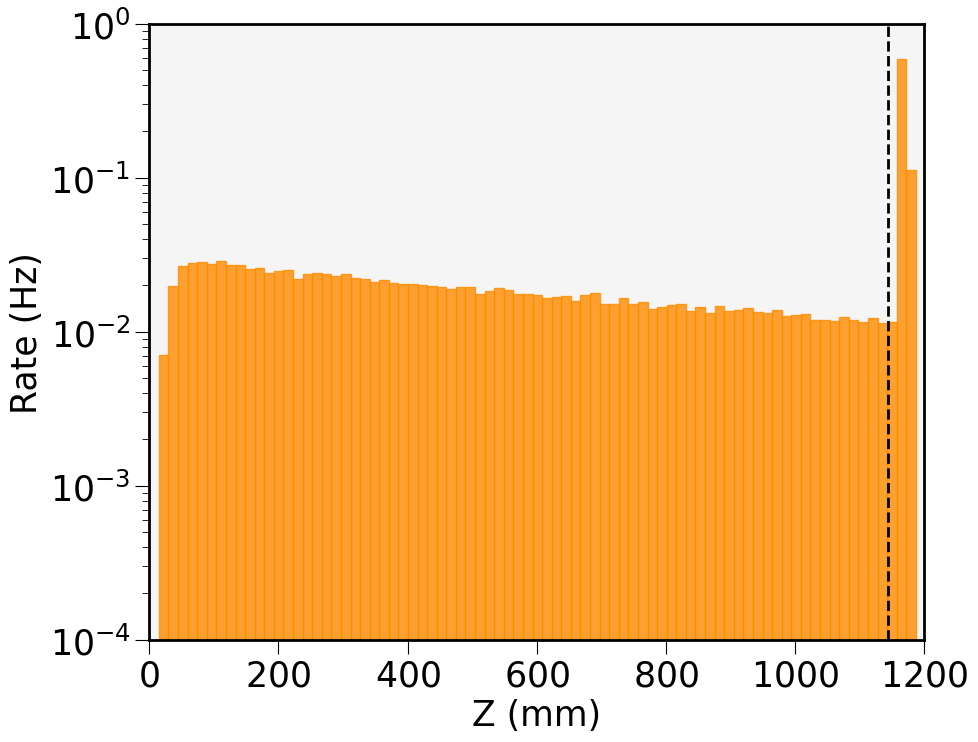

In [36]:
# Global
n_bins = 80

# Data
Rn_data = ANA_DATA['High_Rn']['df']
Rn_long = ANA_DATA['High_Rn']['duration_CV']

# Variables
DT = Rn_data['DT']

# Compute corrected Z
Z = ANA_DATA['High_Rn']['drift_vel_CV'] * DT

# Histogram: normalized by corrected DAQ data taking time
Z_counts, Z_edges = np.histogram(Z, bins=n_bins,  range=(0, crudo.pt.N100_hei))
Z_rate = Z_counts / Rn_long
bin_width = np.diff(Z_edges).mean()

# ----- Plotting ----- #
fig, ax = plt.subplots()

# Data
plt.bar(Z_edges[:-1], Z_rate, width=bin_width, align='edge', 
        color=crudo.pt.hist_colors[2], ec=crudo.pt.hist_colors[2],
        alpha=0.8, lw=1.0)

# Z-limit
Z_lim = ANA_DATA['High_Rn']['drift_vel_CV'] * ANA_DATA['High_Rn']['DTstop_CV']
print(f'Z limit (High Rn): {Z_lim:.2f} mm')
# plt.axvline(x=350, c='black', ls='--')
plt.axvline(x=Z_lim, c='black', ls='--')
        
# ----- Styling ----- #
# Important text
# plt.text(1125, 3.5e-1, 'Active Volume', va='center', ha='right')
# ax.annotate('', xytext=(1125, 5e-1), xy=(1000, 5e-1), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))
# plt.text(1185, 1e-4, 'Cathode', va='bottom', ha='right', rotation=90)

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom=0.1)
# xy = (200, 5e-1)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points", frameon=False)
# ax.add_artist(ab)

plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-4, 1e0)
plt.yscale('log')

plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Radon_LPR/images/Z_Dist.pdf')
# plt.savefig(f'/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/Z_Dist.pdf')
plt.show()

### XY Map

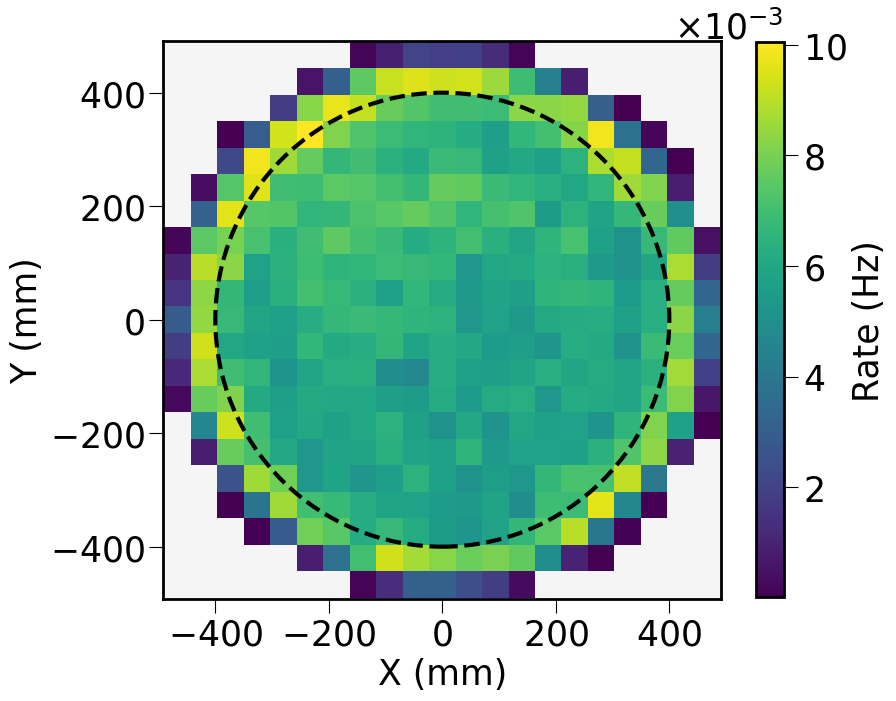

In [37]:
# Global
n_bins = 35

# Data
Rn_data = ANA_DATA['High_Rn']['df']
Rn_long = ANA_DATA['High_Rn']['duration_CV']

# Variables
X = Rn_data['X']
Y = Rn_data['Y']

# 2D histogram: normalized by corrected DAQ data taking time
XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, bin_scale=3, max_limit=crudo.pt.N100_rad, pos=True)
XY_rate            = XY_hit_map / Rn_long                          # Normalized to rate      
XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)      # Zero values masked

# ----- Plotting ----- #
fig, ax = plt.subplots(figsize=(9, 9))
# Data
im = plt.pcolormesh(ex, ey, XY_rate.T, cmap='viridis', shading='auto')
# R-lim
plt.gca().add_patch(plt.Circle((0, 0), 400, color='black', fill=False, ls='--'))

# ----- Styling ----- #
# # Important text
# plt.text(0, 0, 'Active Volume', va='center', ha='center')
# ax.annotate('', xytext=(-375, 0), xy=(-300, 0), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))
# ax.annotate('', xytext=(375, 0), xy=(300, 0), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom=0.1)
# xy = (-275, 400)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 42), xycoords='data', boxcoords="offset points", frameon=False)
# ax.add_artist(ab)

cbar = plt.colorbar(im, label='Rate (Hz)', shrink=0.8)
cbar.formatter.set_powerlimits((-3, -3))
plt.xlabel('X (mm)')
plt.xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
plt.ylabel('Y (mm)')
plt.ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)

plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
# plt.tight_layout()
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Radon_LPR/images/XY_Dist.pdf')
# plt.savefig(f'/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/XY_Dist.pdf')
plt.show()

### Geometrical Masking

For the spectral analysis, from extra analysis and previous plots, we decided to:

- filter out events with $S2w\lt50\,\mu\text{s}$ 'cause they haven't a well-reconstructed energy.
- select the following boundaries for the fiducial volume.

In [38]:
# Limits for width masking
if DF_NAME == 's2w_no_cuts':
    S2W_LIM = 50    # In [μs]
    print(f'You are applyng a width cut of {S2W_LIM} μs for {DF_NAME} dataframe. Please, make sure this is what you want!')
else:
    S2W_LIM = 10    # In [μs], nominal value in IC reconstruction
    print(f'For {DF_NAME} dataframe, you are not doing anything ')

# Geometric boundaries for fiducial volume definition
Z_LOW = 0;        DT_LOW = Z_LOW / ANA_DATA['High_Rn']['drift_vel_CV']    # In [μs]
Z_UP  = 1143.6;   DT_UP  = Z_UP / ANA_DATA['High_Rn']['drift_vel_CV']     # In [μs]
R_UP  = 400    # In [mm]

print(f"\nGeometric boundaries for fiducial volume:")
print(f"  Z range: [{Z_LOW}, {Z_UP}) mm")
print(f"    - corresponding DT range: [{DT_LOW:.2f}, {DT_UP:.2f}) μs")
print(f"  R limit: R < {R_UP} mm")

# Update dataframes and creating fiducial mask
for entry in ANA_DATA:
    
    # Dataframe
    data = ANA_DATA[entry]['df']
    
    # --- S2 Width Filter --- #
    W2_mask = (data['S2w'] > S2W_LIM)
    new_data = data[W2_mask].copy()
    # Update dataframe
    ANA_DATA[entry]['df'] = new_data.copy()

    # --- Fiducial Volume Mask --- #    
    DT = new_data['DT']
    R  = np.sqrt(new_data['X']**2 + new_data['Y']**2)
    ANA_DATA[entry]['FV_mask'] = (DT >= DT_LOW) & (DT < DT_UP) & (R < R_UP)

You are applyng a width cut of 50 μs for s2w_no_cuts dataframe. Please, make sure this is what you want!

Geometric boundaries for fiducial volume:
  Z range: [0, 1143.6) mm
    - corresponding DT range: [0.00, 1311.43) μs
  R limit: R < 400 mm


# Energy Estimator

We need to determine the optimum weight factor $\eta$ and the scale factor $\lambda$ for the new energy estimator using the $S1$ and $S2$ energy values.

In [39]:
# Parameters for the final energy estimator
Best_eta    = 0
High_lambda = 0
Low_lambda  = 0

## $\eta$ Determination

Because of statistics, we use the High-Rn run 14739.


--- Processing η = 0.0000 ---
Dynamic peak finding failed. Using analytical fallback guess.
Initial values: [ 350.   1500.     18.29  350.   1750.     18.29]
Final values: [ 639.48 1506.73   56.    224.9  1641.96   61.23]
Energy resolution (Peak 1): 8.75%


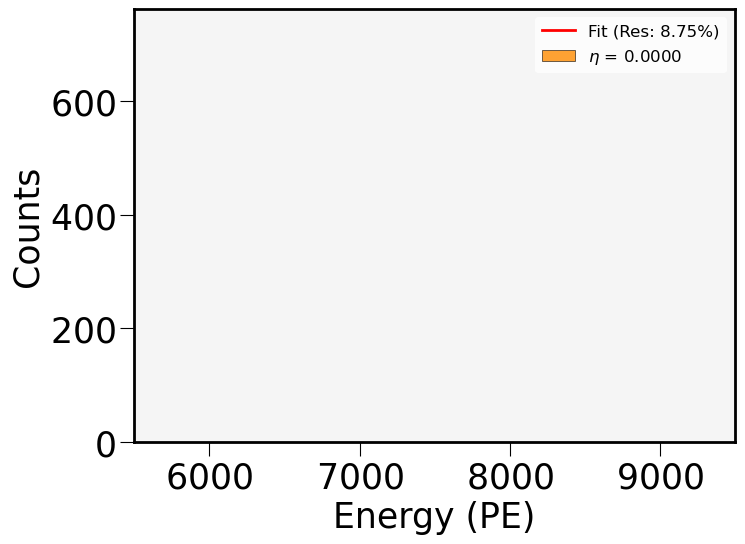


--- Processing η = 0.0005 ---
Initial values: [ 771.   1912.95   20.56  274.   2087.73   20.56]
Final values: [ 733.74 1914.79   55.07  252.59 2088.27   59.87]
Energy resolution (Peak 1): 6.77%


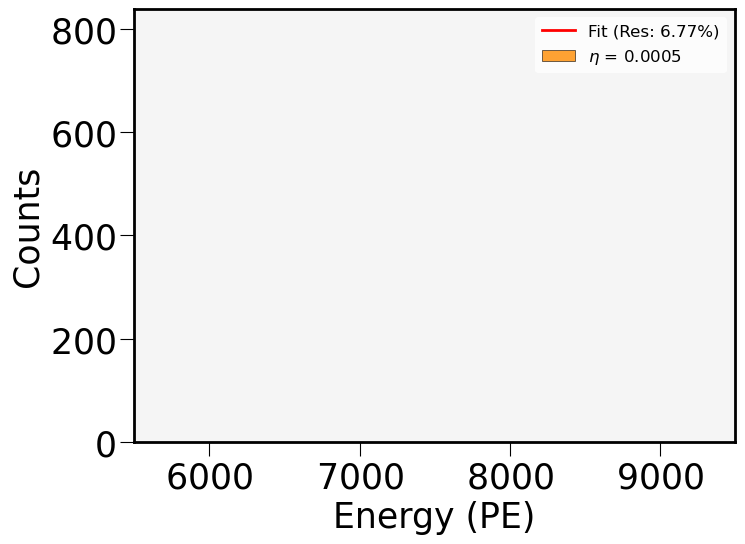


--- Processing η = 0.0010 ---
Initial values: [ 854.   2314.81   23.11  284.   2534.4    23.11]
Final values: [ 810.24 2322.74   56.4   277.2  2533.18   59.99]
Energy resolution (Peak 1): 5.72%


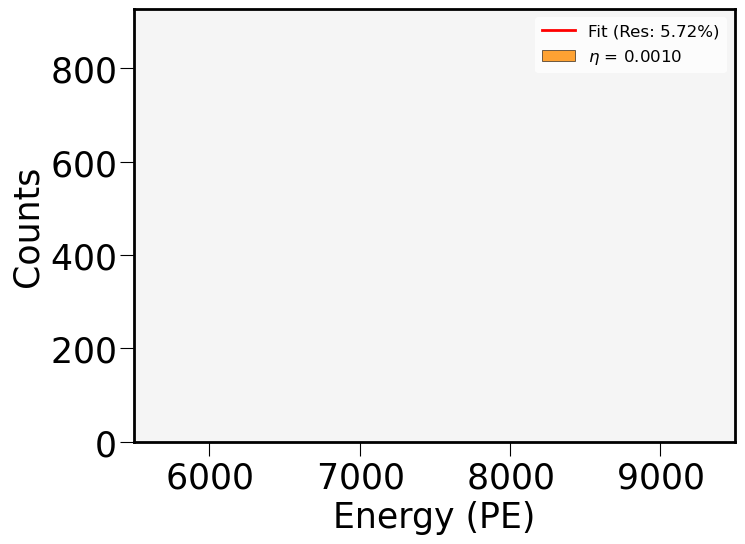


--- Processing η = 0.0015 ---
Initial values: [ 878.   2732.75   25.68  326.   2983.16   25.68]
Final values: [ 861.25 2730.27   58.83  293.78 2977.17   62.77]
Energy resolution (Peak 1): 5.07%


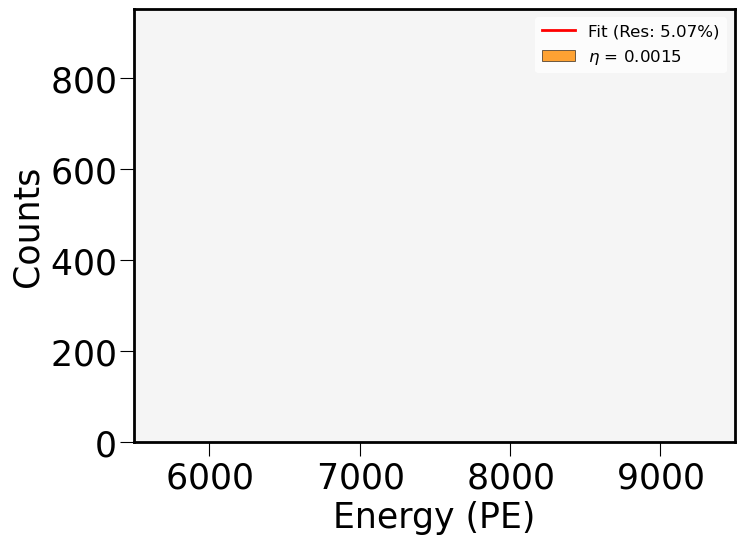


--- Processing η = 0.0020 ---
Initial values: [1017.   3139.35   30.83  366.   3416.86   30.83]
Final values: [ 976.51 3137.85   61.97  330.87 3420.99   67.18]
Energy resolution (Peak 1): 4.65%


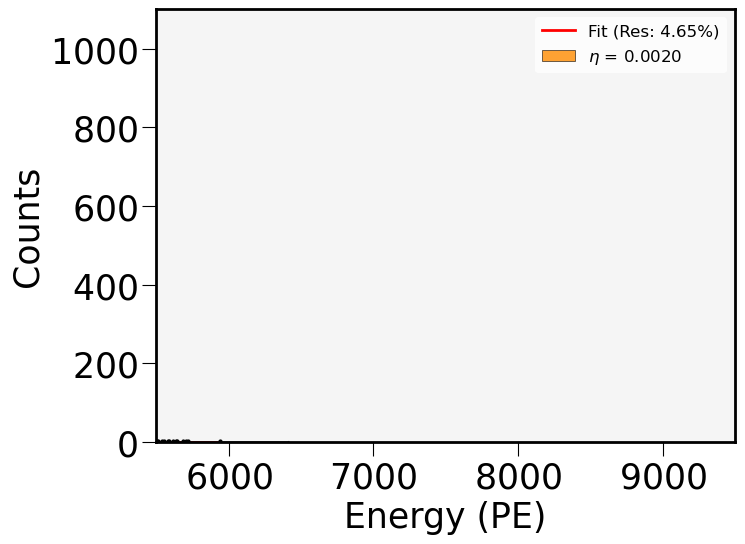


--- Processing η = 0.0026 ---
Initial values: [1103.   3548.6    36.12  388.   3873.65   36.12]
Final values: [1070.8  3545.26   65.87  359.21 3865.     72.5 ]
Energy resolution (Peak 1): 4.38%


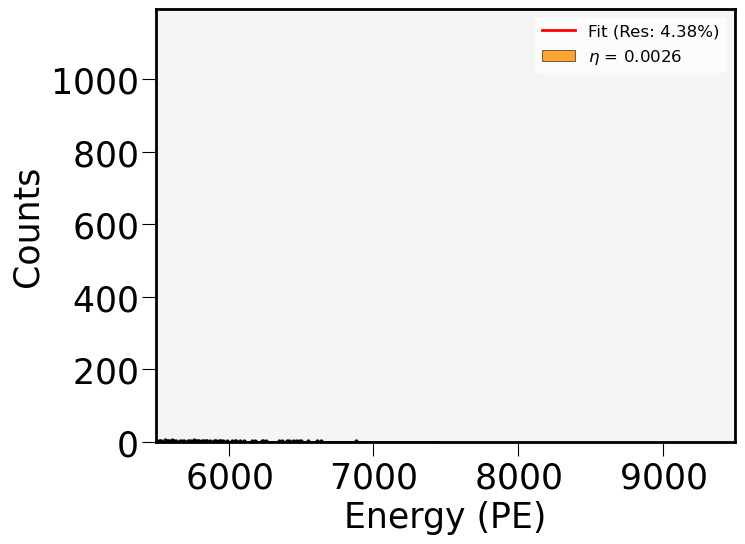


--- Processing η = 0.0031 ---
Initial values: [1194.   3957.41   41.4   400.   4309.31   41.4 ]
Final values: [1141.39 3952.88   70.43  379.61 4309.1    78.72]
Energy resolution (Peak 1): 4.20%


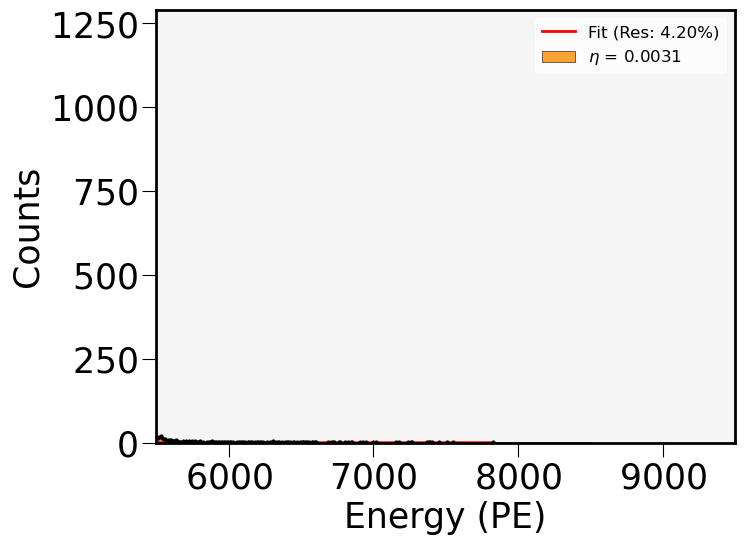


--- Processing η = 0.0036 ---
Initial values: [1294.   4373.72   46.68  440.   4758.85   46.68]
Final values: [1197.32 4360.31   75.26  394.44 4752.97   85.68]
Energy resolution (Peak 1): 4.06%


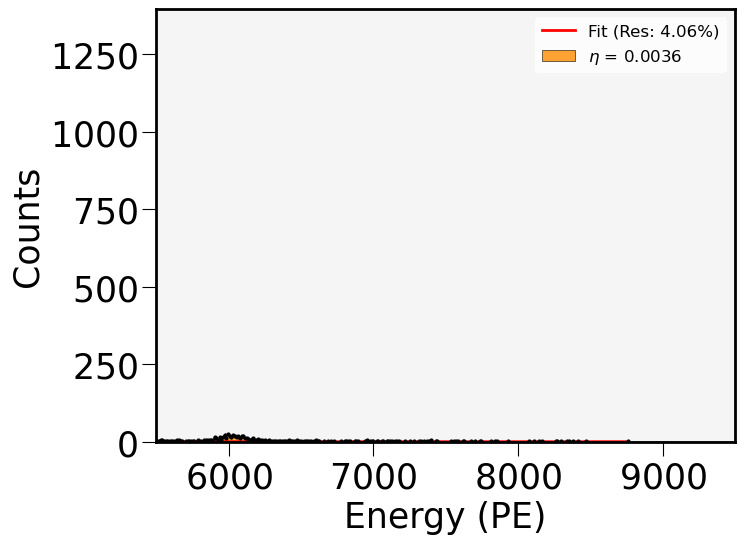


--- Processing η = 0.0041 ---
Initial values: [1300.   4779.46   51.97  441.   5208.18   51.97]
Final values: [1238.13 4767.87   80.67  406.09 5197.2    92.71]
Energy resolution (Peak 1): 3.98%


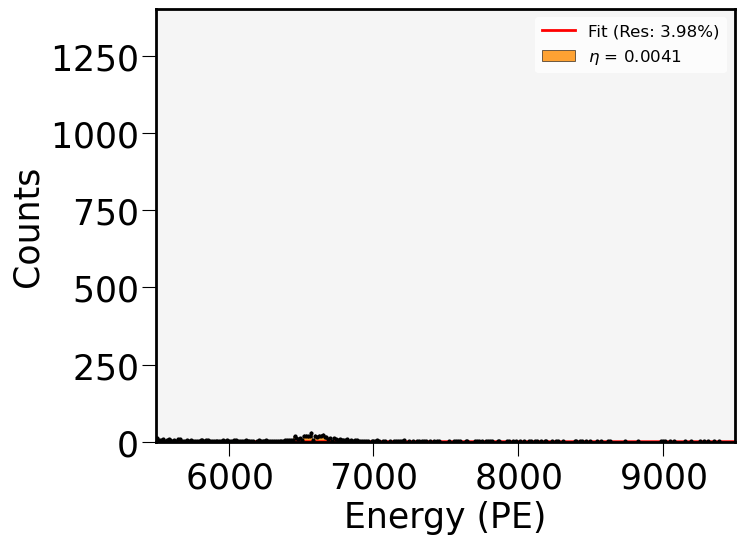


--- Processing η = 0.0046 ---
Initial values: [1300.   5188.95   57.25  456.   5661.25   57.25]
Final values: [1268.34 5175.25   86.39  413.58 5641.24  100.47]
Energy resolution (Peak 1): 3.93%


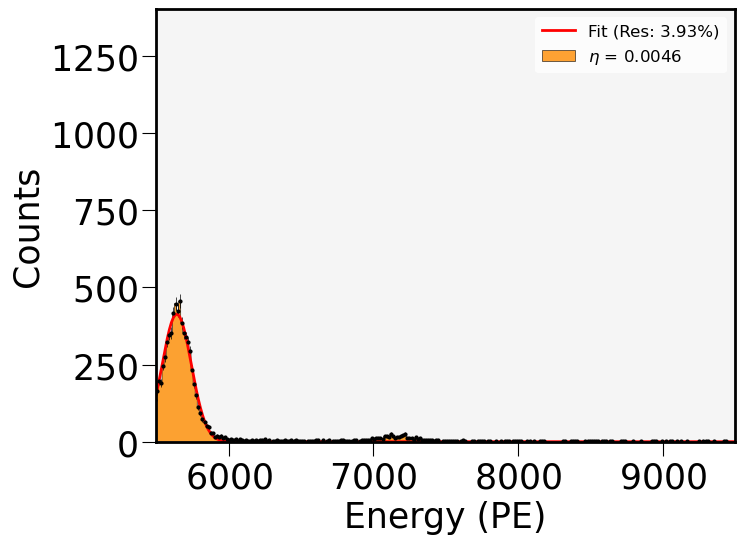


--- Processing η = 0.0051 ---
Initial values: [1337.   5597.24   62.61  463.   6082.46   62.61]
Final values: [1291.72 5582.87   92.47  419.75 6085.05  108.35]
Energy resolution (Peak 1): 3.90%


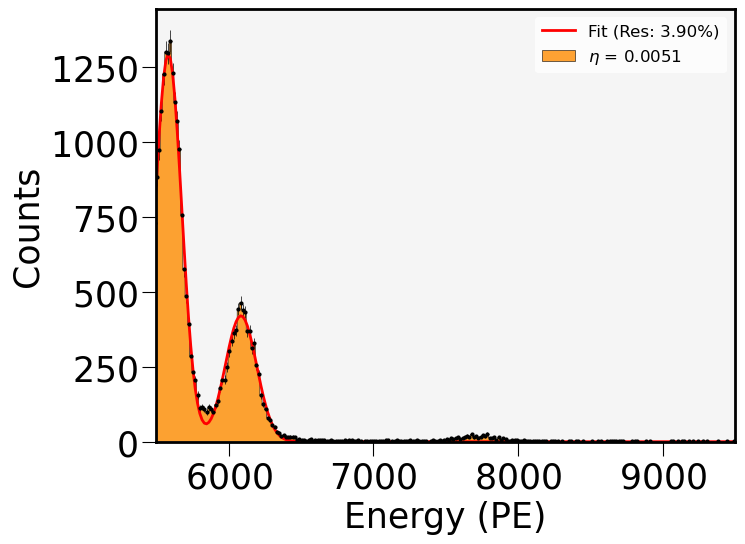


--- Processing η = 0.0056 ---
Initial values: [1353.   5995.57   68.01  474.   6539.67   68.01]
Final values: [1309.67 5990.34   98.8   423.27 6528.96  117.14]
Energy resolution (Peak 1): 3.88%


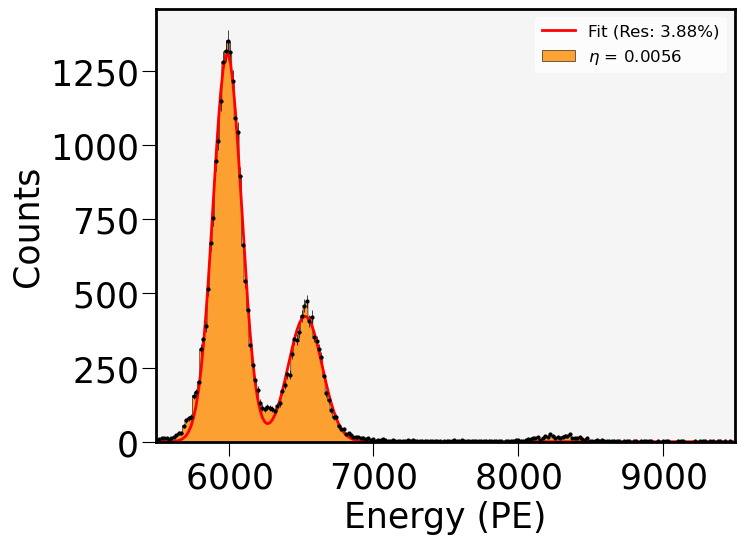


--- Processing η = 0.0061 ---
Initial values: [1345.   6388.51   73.41  467.   6975.82   73.41]
Final values: [1323.07 6397.82  105.34  425.95 6972.79  125.94]
Energy resolution (Peak 1): 3.88%


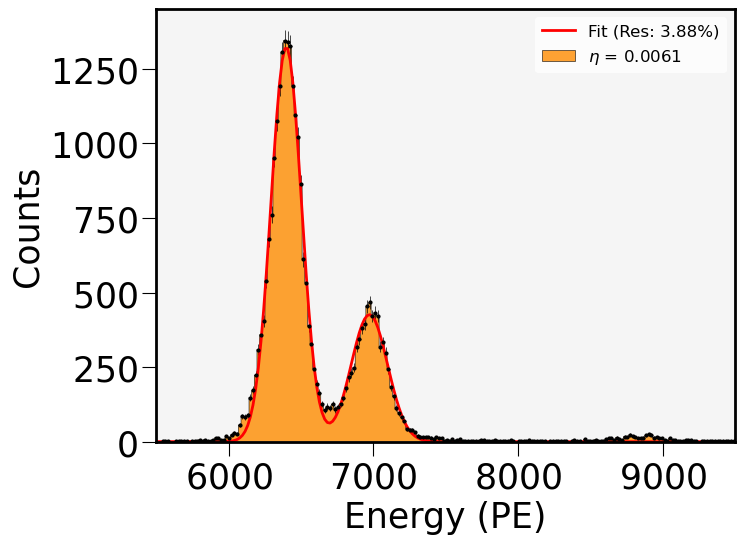


--- Processing η = 0.0066 ---
Initial values: [1361.   6815.45   78.82  474.   7406.56   78.82]
Final values: [1332.2  6805.37  112.14  428.78 7416.69  134.55]
Energy resolution (Peak 1): 3.88%


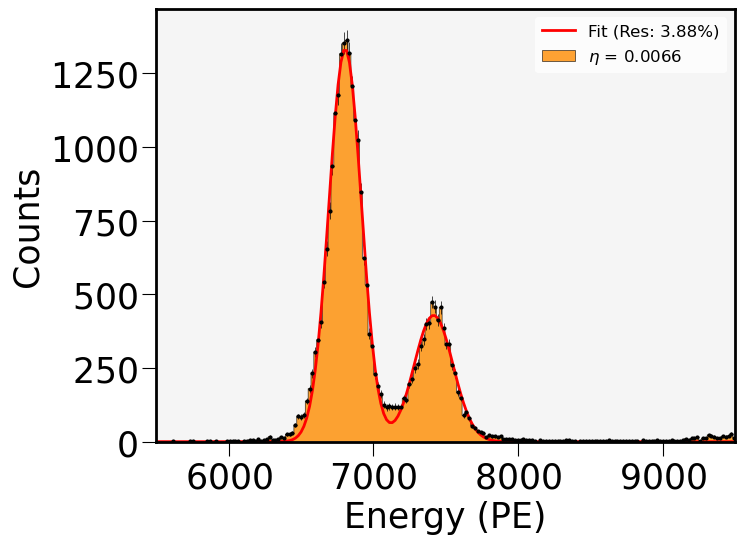


--- Processing η = 0.0071 ---
Initial values: [1411.   7221.33   84.22  462.   7874.02   84.22]
Final values: [1339.16 7212.75  119.01  429.78 7860.63  143.79]
Energy resolution (Peak 1): 3.89%


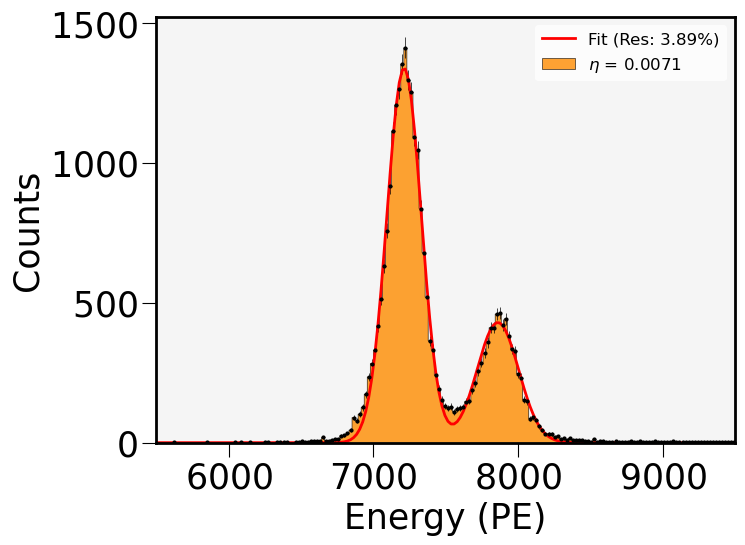


--- Processing η = 0.0077 ---
Initial values: [1403.   7624.52   89.62  478.   8319.07   89.62]
Final values: [1342.14 7620.02  126.27  431.05 8304.29  152.84]
Energy resolution (Peak 1): 3.90%


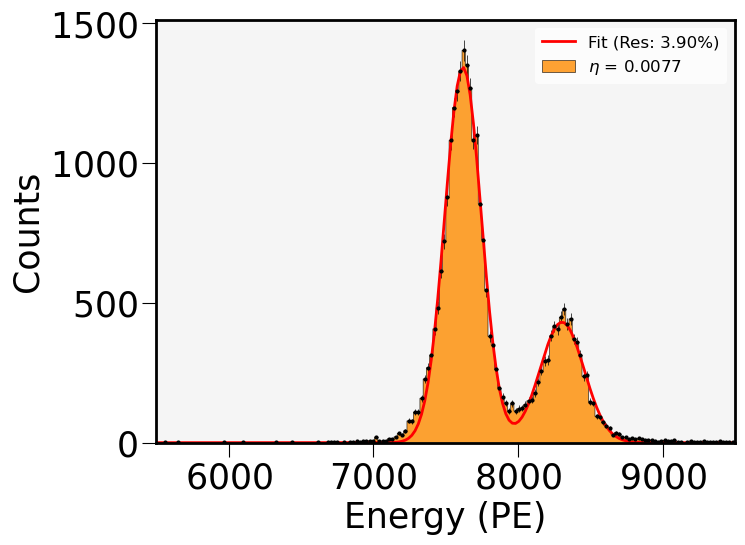


--- Processing η = 0.0082 ---
Initial values: [1416.   8048.76   95.02  480.   8761.42   95.02]
Final values: [1343.75 8027.59  133.67  432.43 8748.21  161.76]
Energy resolution (Peak 1): 3.92%


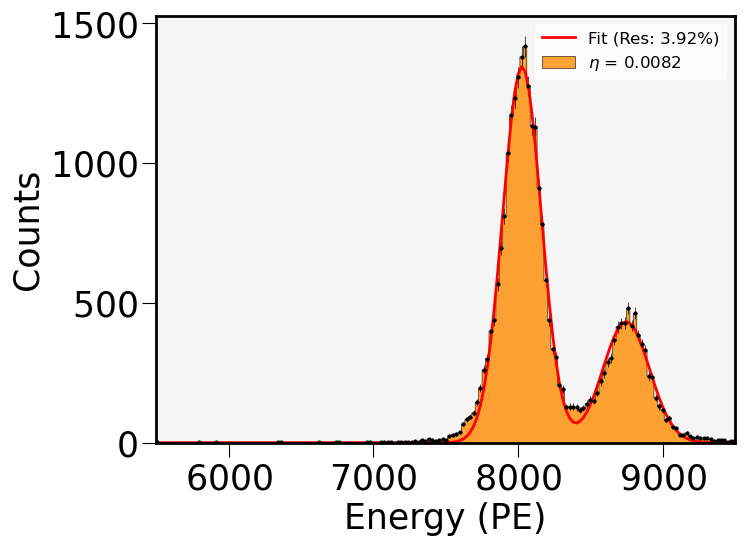


--- Processing η = 0.0087 ---
Initial values: [1450.   8444.47  100.45  467.   9197.86  100.45]
Final values: [1344.57 8434.91  141.18  432.78 9191.82  171.27]
Energy resolution (Peak 1): 3.94%


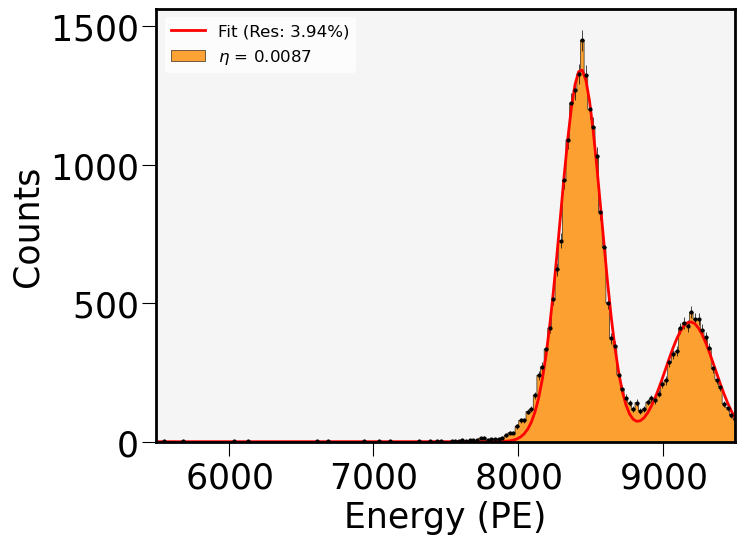


--- Processing η = 0.0092 ---
Initial values: [1407.   8863.39  105.89  471.   9657.56  105.89]
Final values: [1345.58 8842.44  148.62  433.   9635.49  180.69]
Energy resolution (Peak 1): 3.96%


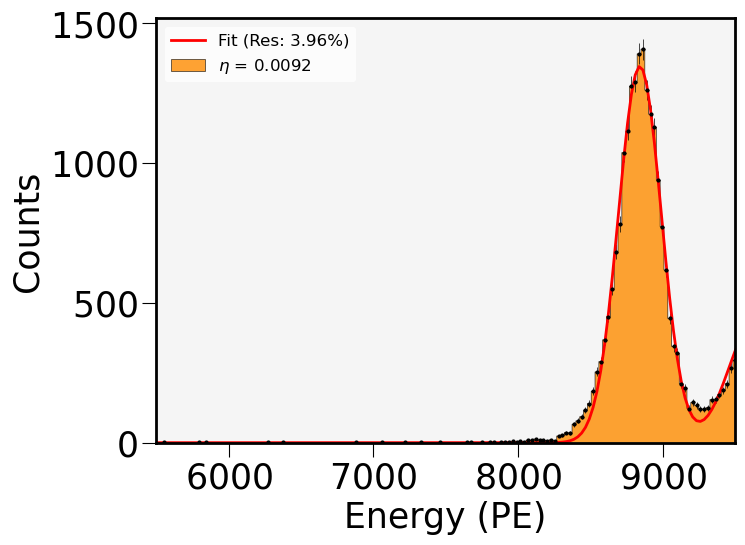


--- Processing η = 0.0097 ---
Initial values: [ 1403.    9254.47   111.33   467.   10089.41   111.33]
Final values: [ 1344.92  9249.99   156.28   434.71 10079.33   189.42]
Energy resolution (Peak 1): 3.98%


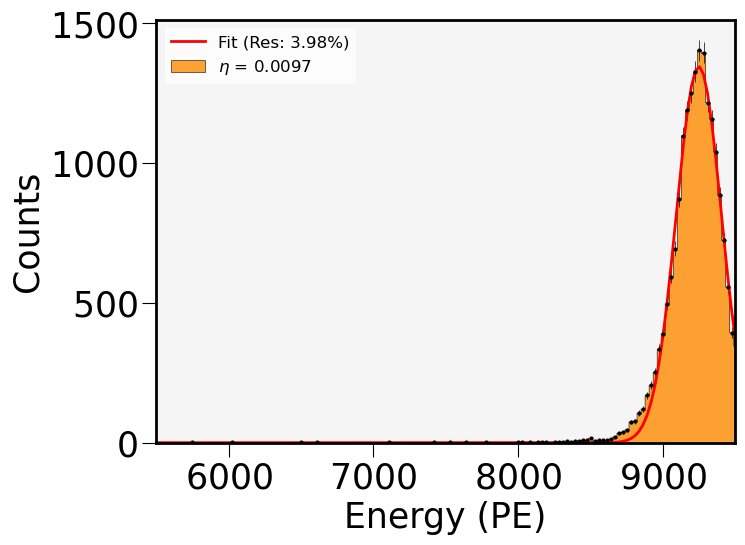


--- Processing η = 0.0102 ---
Initial values: [ 1429.    9672.03   116.76   456.   10606.13   116.76]
Final values: [ 1346.71  9657.12   163.56   433.87 10522.8    199.52]
Energy resolution (Peak 1): 3.99%


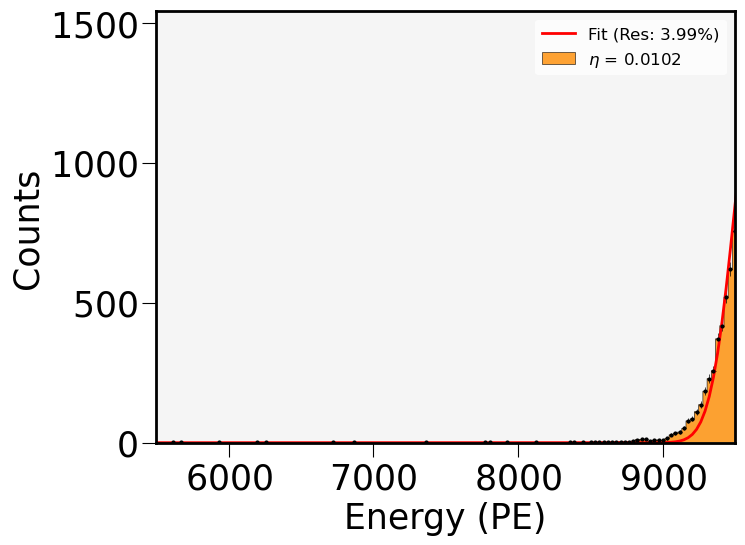


--- Processing η = 0.0107 ---
Initial values: [ 1429.   10089.59   122.2    465.   10975.53   122.2 ]
Final values: [ 1343.77 10064.56   171.6    433.85 10966.69   209.2 ]
Energy resolution (Peak 1): 4.02%


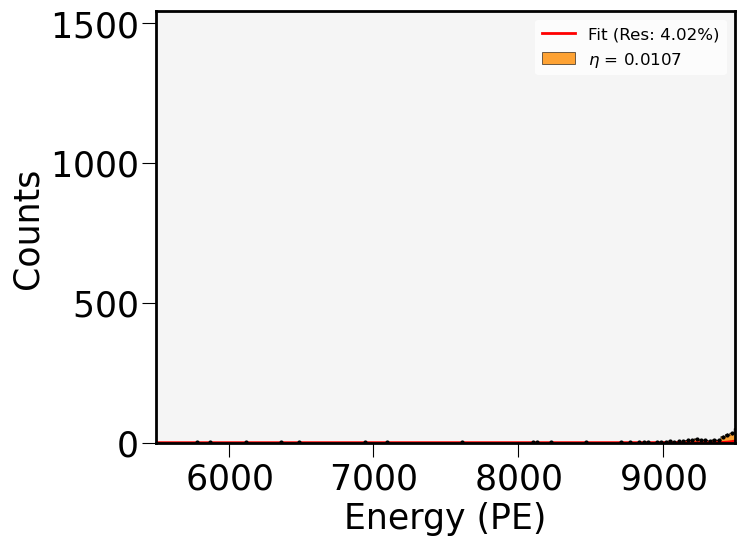


--- Processing η = 0.0112 ---
Initial values: [ 1421.   10475.24   127.64   475.   11432.5    127.64]
Final values: [ 1341.49 10472.23   179.59   433.81 11410.17   218.51]
Energy resolution (Peak 1): 4.04%


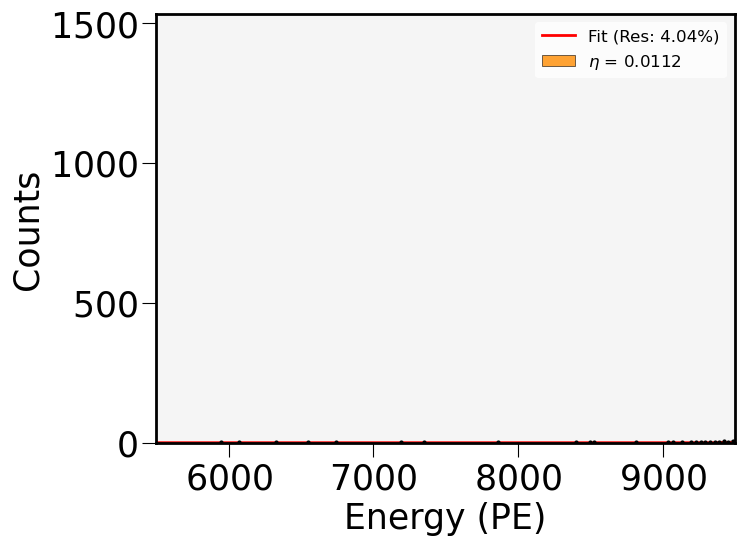


--- Processing η = 0.0117 ---
Initial values: [ 1404.   10891.43   133.07   453.   11922.74   133.07]
Final values: [ 1341.65 10879.5    187.11   433.6  11853.89   228.31]
Energy resolution (Peak 1): 4.05%


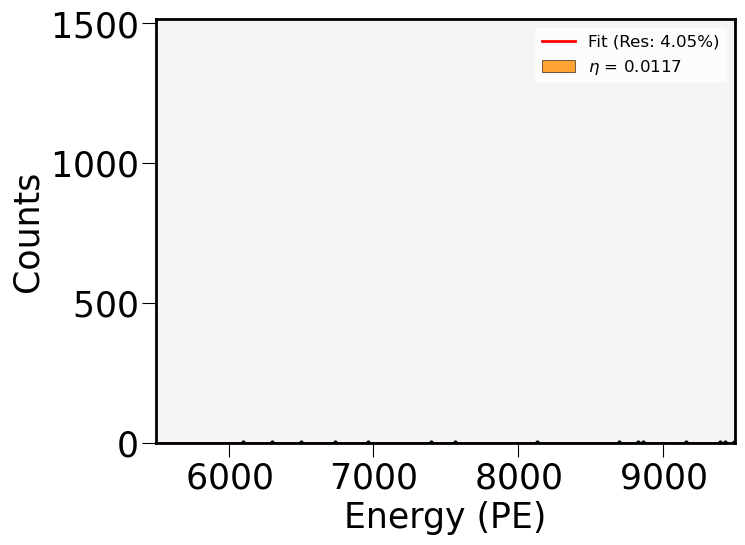


--- Processing η = 0.0122 ---
Initial values: [ 1391.   11307.63   138.51   460.   12311.82   138.51]
Final values: [ 1340.47 11286.76   194.93   433.89 12297.69   237.85]
Energy resolution (Peak 1): 4.07%


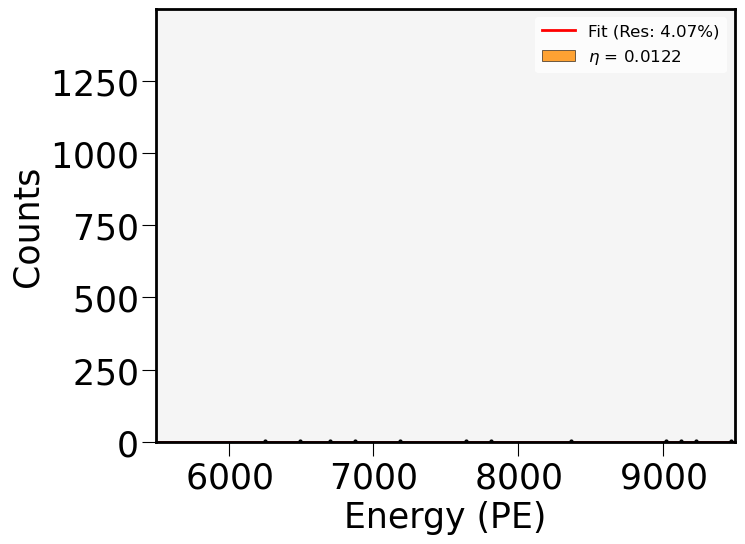


--- Processing η = 0.0128 ---
Initial values: [ 1406.   11723.83   143.94   464.   12803.42   143.94]
Final values: [ 1338.24 11694.19   202.97   433.16 12741.14   247.72]
Energy resolution (Peak 1): 4.09%


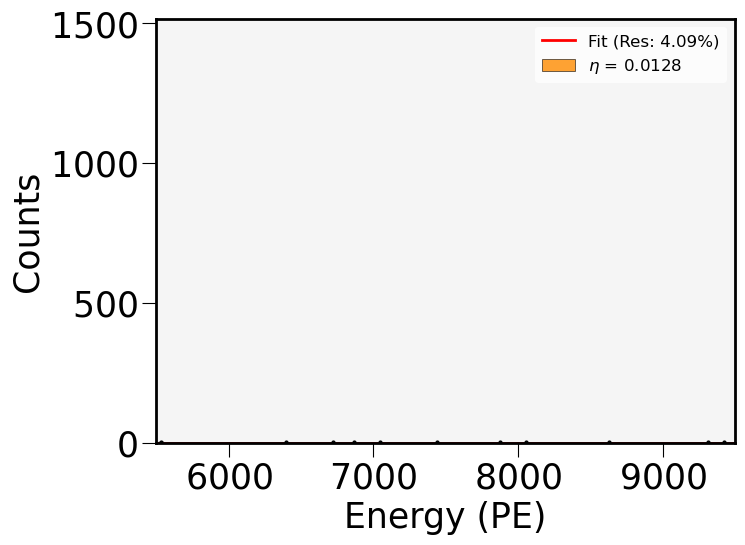


--- Processing η = 0.0133 ---
Initial values: [ 1398.   12102.69   149.38   459.   13260.39   149.38]
Final values: [ 1335.44 12101.71   211.13   433.99 13184.92   256.52]
Energy resolution (Peak 1): 4.11%


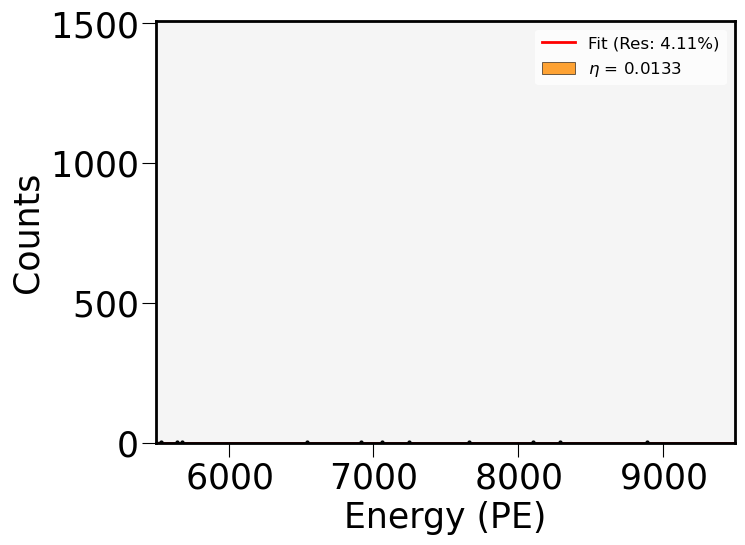


--- Processing η = 0.0138 ---
Initial values: [ 1385.   12517.53   154.82   473.   13678.66   154.82]
Final values: [ 1332.84 12509.1    219.25   433.41 13628.83   266.57]
Energy resolution (Peak 1): 4.13%


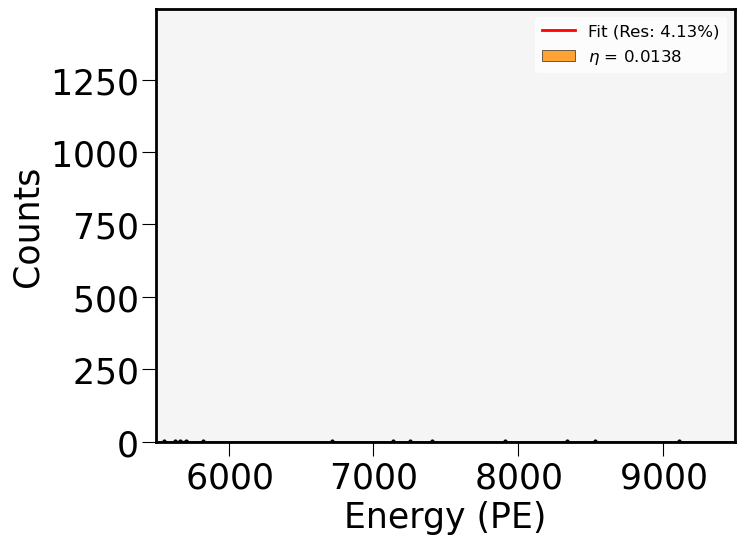


--- Processing η = 0.0143 ---
Initial values: [ 1386.   12932.37   160.25   476.   14134.27   160.25]
Final values: [ 1333.27 12916.52   226.73   432.75 14073.13   276.82]
Energy resolution (Peak 1): 4.13%


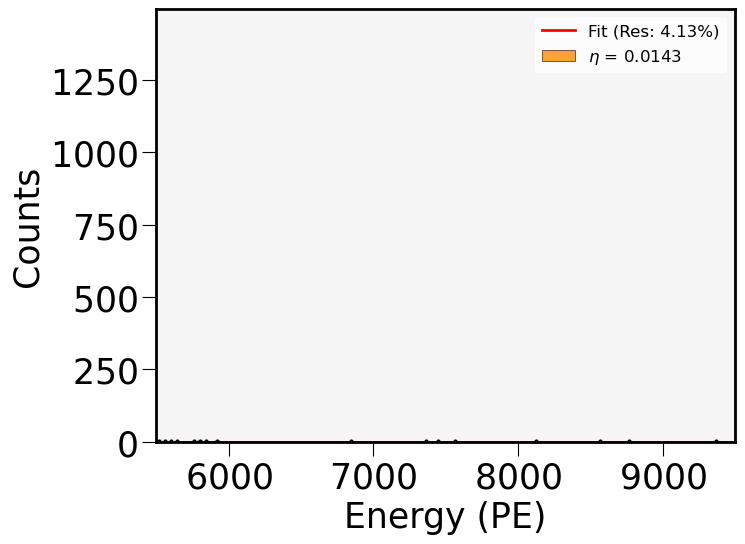


--- Processing η = 0.0148 ---
Initial values: [ 1398.   13347.21   165.69   454.   14548.46   165.69]
Final values: [ 1330.98 13323.68   234.87   432.68 14516.46   286.44]
Energy resolution (Peak 1): 4.15%


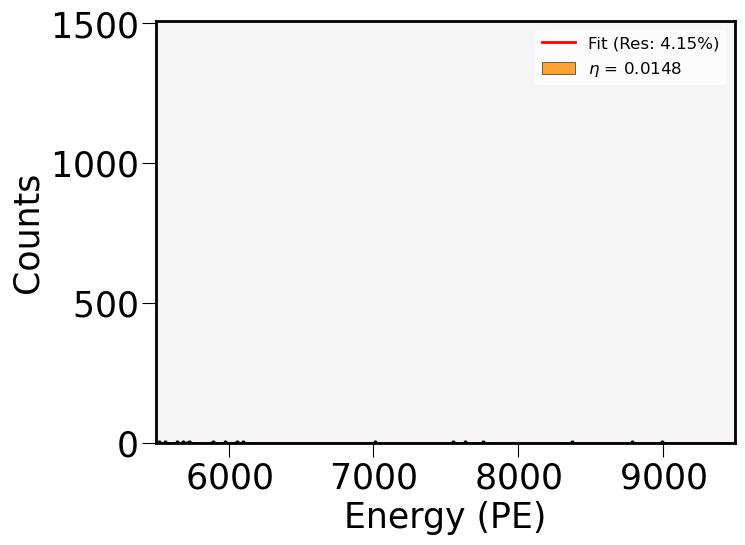


--- Processing η = 0.0153 ---
Initial values: [ 1402.   13762.04   171.13   463.   15002.72   171.13]
Final values: [ 1330.39 13731.3    242.66   432.92 14959.57   295.75]
Energy resolution (Peak 1): 4.16%


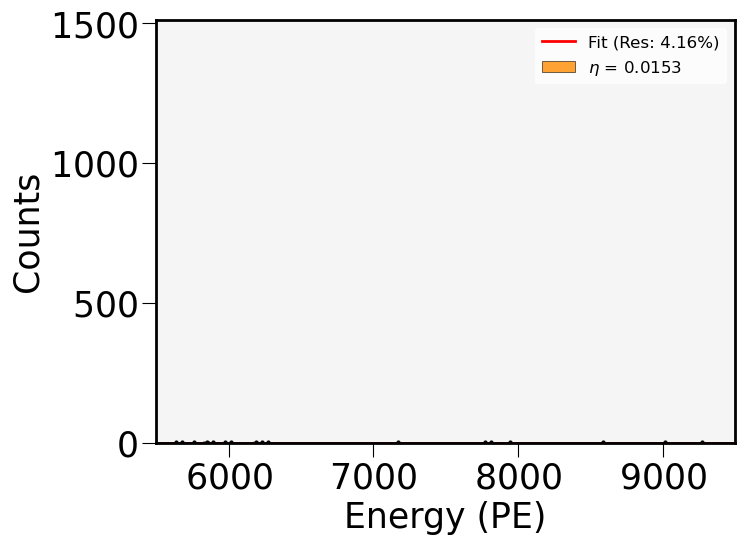


--- Processing η = 0.0158 ---
Initial values: [ 1373.   14176.88   176.56   472.   15456.97   176.56]
Final values: [ 1327.5  14138.82   251.06   432.36 15403.73   305.65]
Energy resolution (Peak 1): 4.18%


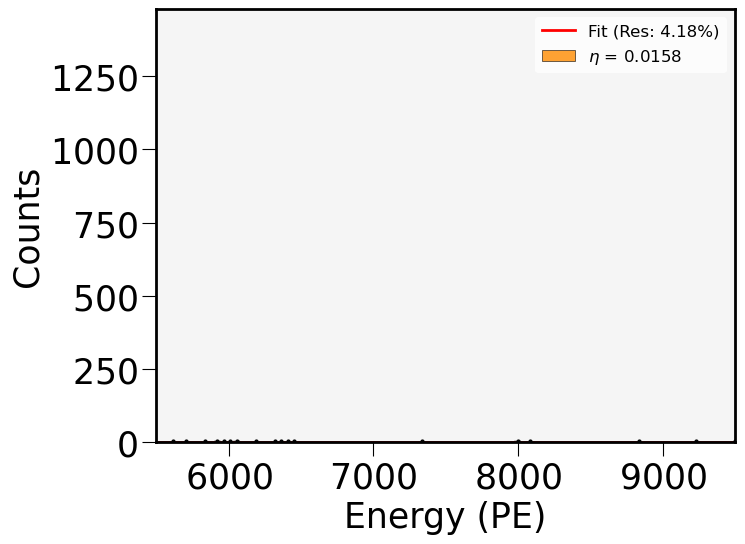


--- Processing η = 0.0163 ---
Initial values: [ 1372.   14591.72   182.     465.   15911.23   182.  ]
Final values: [ 1326.23 14546.3    259.05   433.05 15847.55   314.52]
Energy resolution (Peak 1): 4.19%


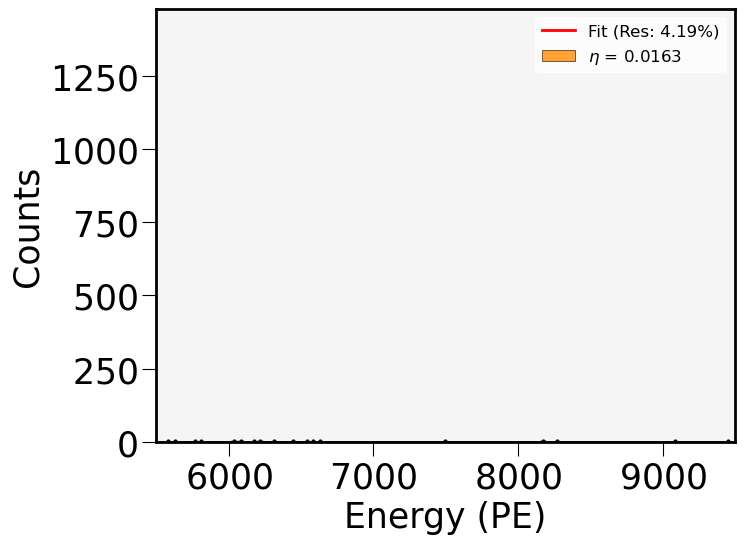


--- Processing η = 0.0168 ---
Initial values: [ 1348.   14959.7    187.44   469.   16365.48   187.44]
Final values: [ 1322.77 14953.1    267.62   432.61 16290.96   324.45]
Energy resolution (Peak 1): 4.21%


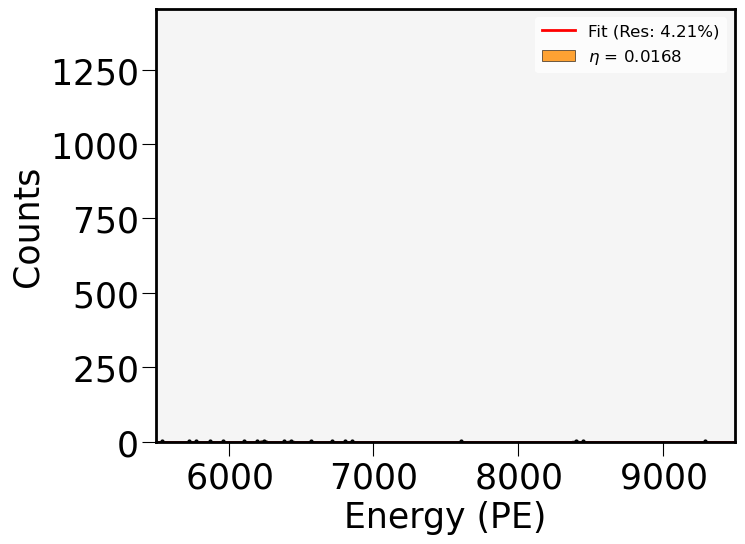


--- Processing η = 0.0173 ---
Initial values: [ 1366.   15373.19   192.87   456.   16819.73   192.87]
Final values: [ 1321.88 15360.23   275.58   432.16 16734.85   334.48]
Energy resolution (Peak 1): 4.23%


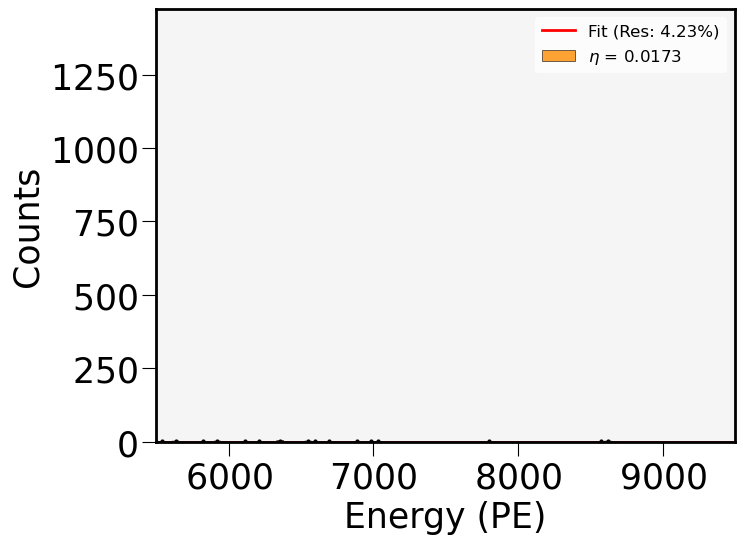


--- Processing η = 0.0179 ---
Initial values: [ 1357.   15786.67   198.31   460.   17273.99   198.31]
Final values: [ 1320.54 15767.81   283.64   432.75 17178.92   343.28]
Energy resolution (Peak 1): 4.24%


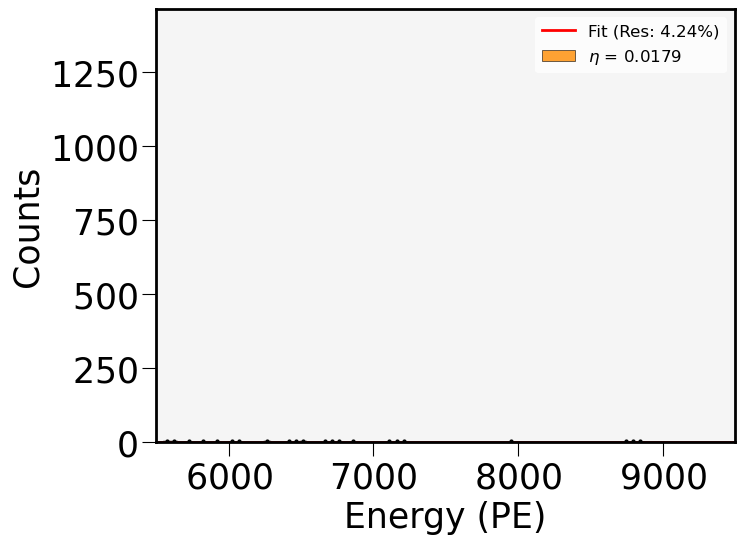


--- Processing η = 0.0184 ---
Initial values: [ 1348.   16200.15   203.75   468.   17728.24   203.75]
Final values: [ 1319.59 16175.77   291.54   432.63 17622.87   352.96]
Energy resolution (Peak 1): 4.24%


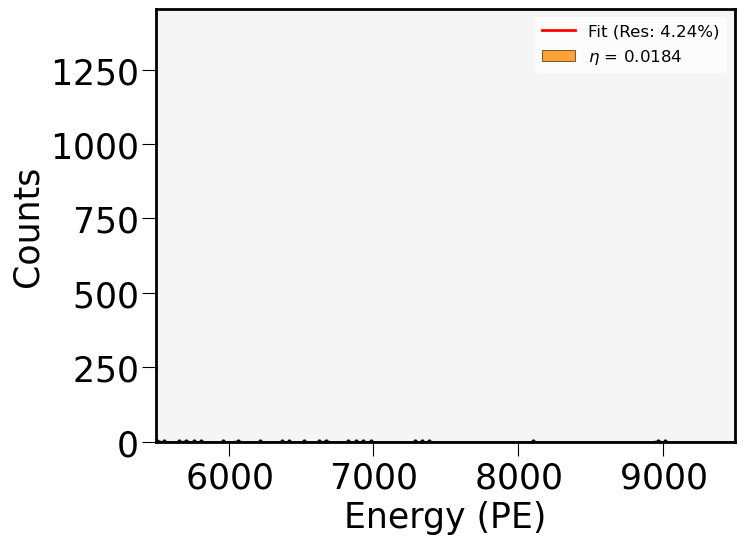


--- Processing η = 0.0189 ---
Initial values: [ 1349.   16613.63   209.18   461.   18182.5    209.18]
Final values: [ 1318.81 16583.08   299.49   432.2  18066.1    362.9 ]
Energy resolution (Peak 1): 4.25%


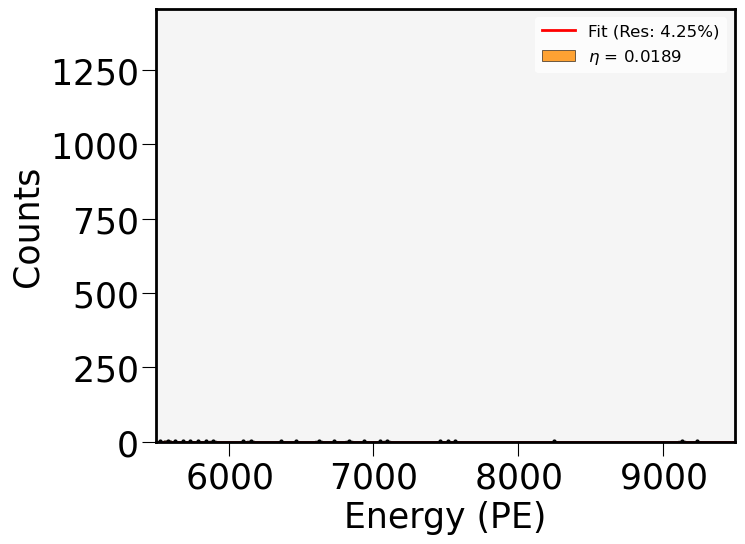


--- Processing η = 0.0194 ---
Initial values: [ 1335.   17027.11   214.62   450.   18583.1    214.62]
Final values: [ 1318.   16990.79   307.51   432.47 18509.56   372.01]
Energy resolution (Peak 1): 4.26%


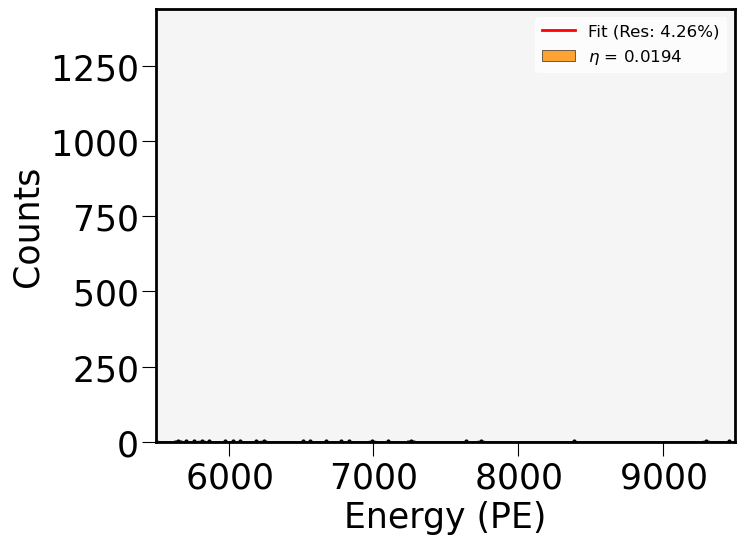


--- Processing η = 0.0199 ---
Initial values: [ 1335.   17440.59   220.06   459.   19035.99   220.06]
Final values: [ 1316.4  17398.01   315.66   432.   18953.     382.15]
Energy resolution (Peak 1): 4.27%


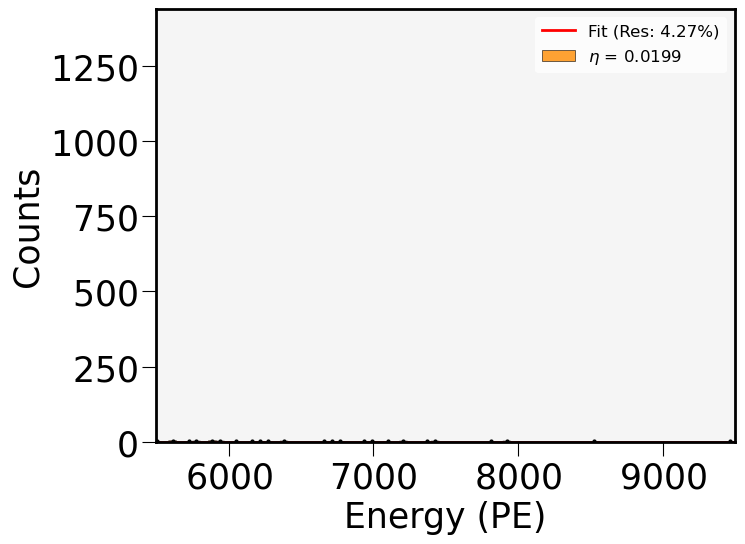


--- Processing η = 0.0204 ---
Initial values: [ 1329.   17854.07   225.49   472.   19488.89   225.49]
Final values: [ 1313.57 17805.16   324.31   431.71 19396.91   391.83]
Energy resolution (Peak 1): 4.29%


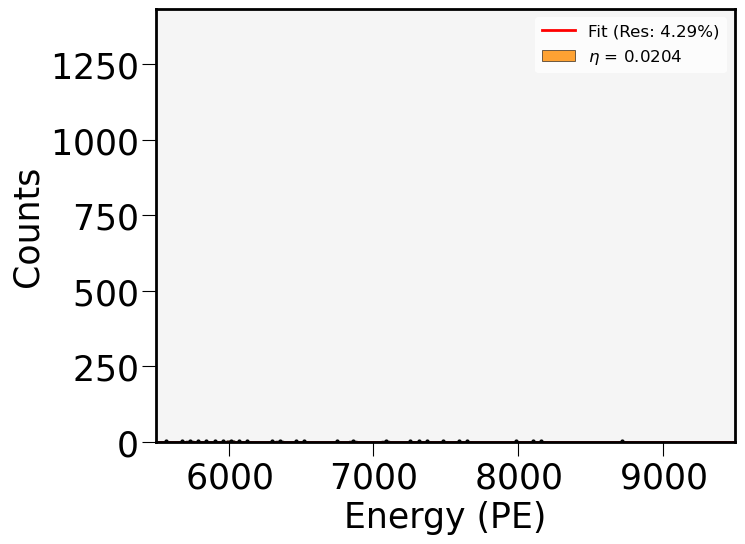


--- Processing η = 0.0209 ---
Initial values: [ 1324.   18267.55   230.93   485.   19941.78   230.93]
Final values: [ 1311.61 18212.79   332.76   431.82 19840.86   400.97]
Energy resolution (Peak 1): 4.30%


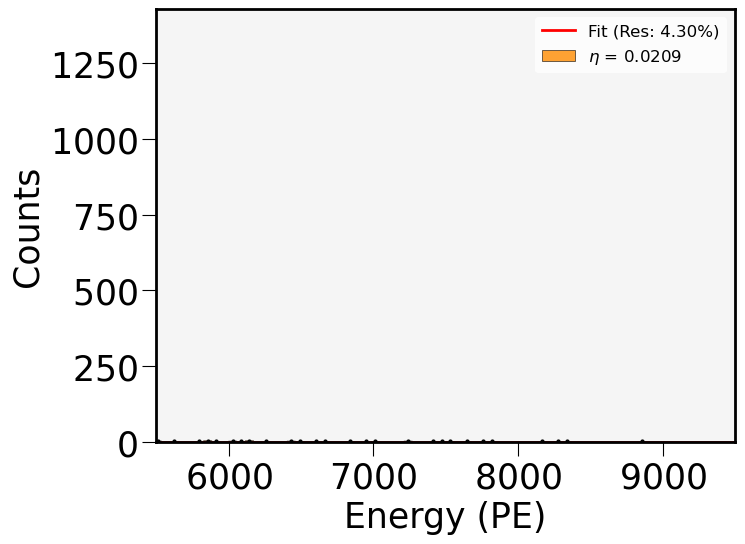


--- Processing η = 0.0214 ---
Initial values: [ 1328.   18621.94   236.37   479.   20394.68   236.37]
Final values: [ 1310.41 18619.62   341.     431.62 20284.57   410.84]
Energy resolution (Peak 1): 4.31%


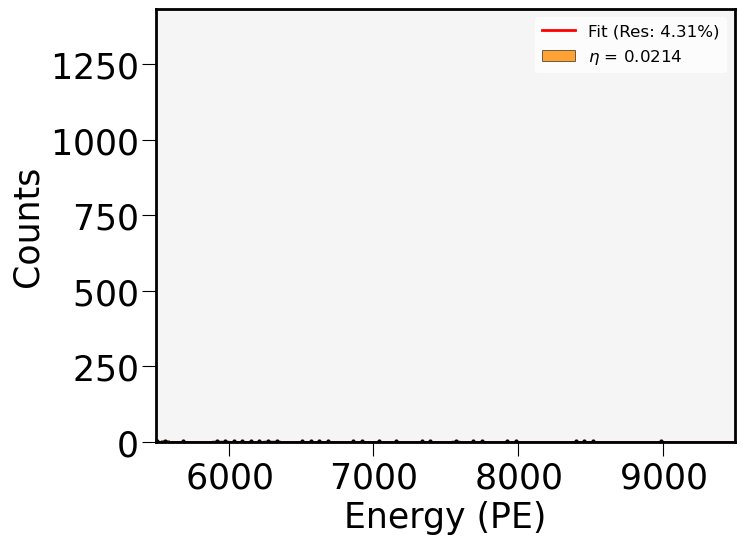


--- Processing η = 0.0219 ---
Initial values: [ 1328.   19034.06   241.8    469.   20847.57   241.8 ]
Final values: [ 1310.72 19027.02   348.68   431.15 20728.06   421.03]
Energy resolution (Peak 1): 4.32%


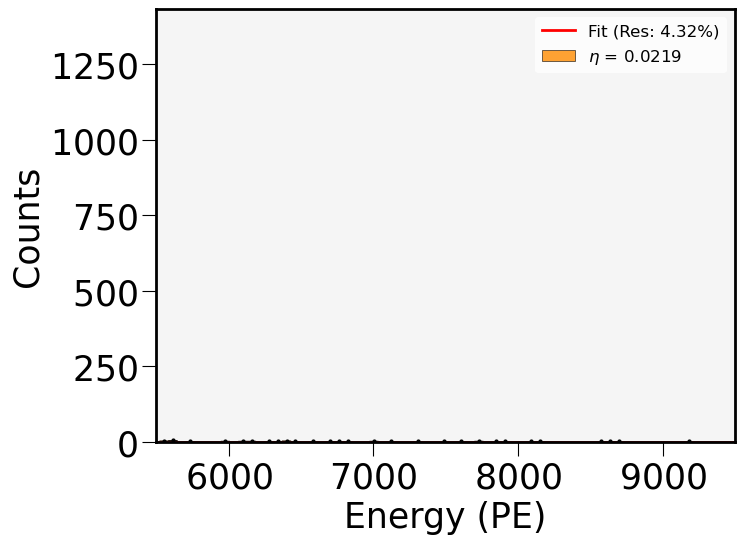


--- Processing η = 0.0224 ---
Initial values: [ 1329.   19446.18   247.24   470.   21300.47   247.24]
Final values: [ 1309.66 19434.16   356.87   431.85 21171.02   429.63]
Energy resolution (Peak 1): 4.32%


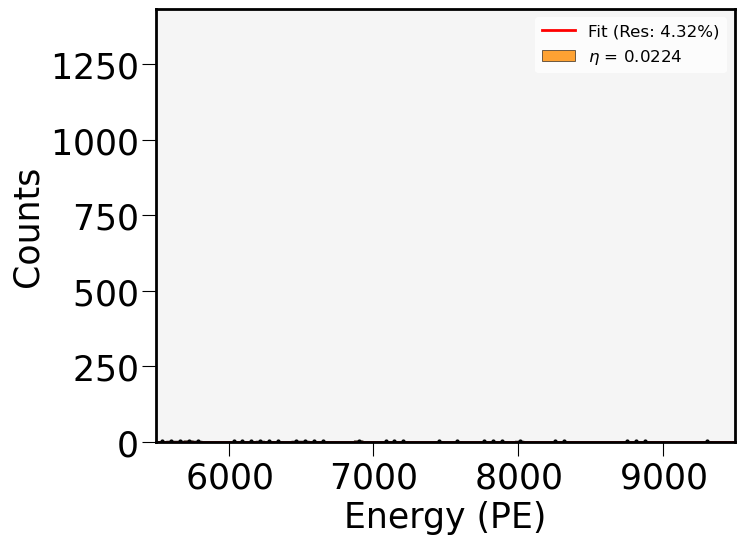


--- Processing η = 0.0230 ---
Initial values: [ 1331.   19858.3    252.67   468.   21753.36   252.67]
Final values: [ 1307.6  19841.49   365.39   431.44 21614.37   439.54]
Energy resolution (Peak 1): 4.34%


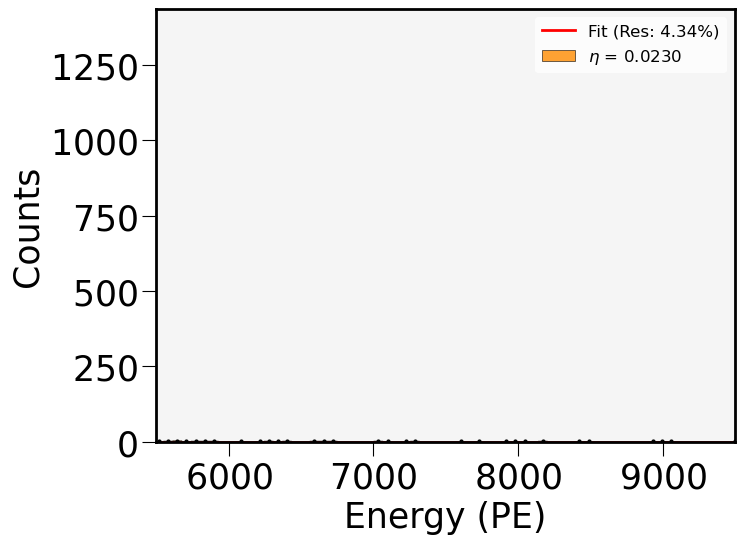


--- Processing η = 0.0235 ---
Initial values: [ 1331.   20205.9    258.11   453.   22206.26   258.11]
Final values: [ 1307.15 20248.99   373.23   431.02 22058.13   449.74]
Energy resolution (Peak 1): 4.34%


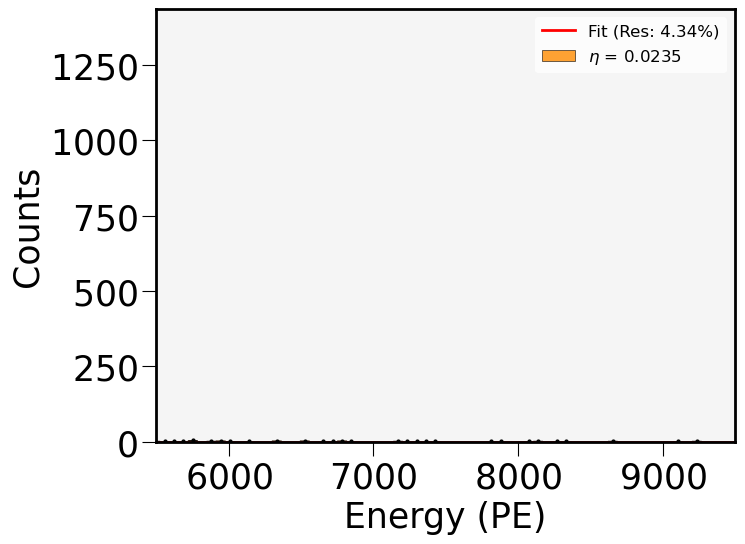


--- Processing η = 0.0240 ---
Initial values: [ 1334.   20682.55   263.55   451.   22659.15   263.55]
Final values: [ 1305.92 20656.55   381.47   430.88 22501.56   459.23]
Energy resolution (Peak 1): 4.35%


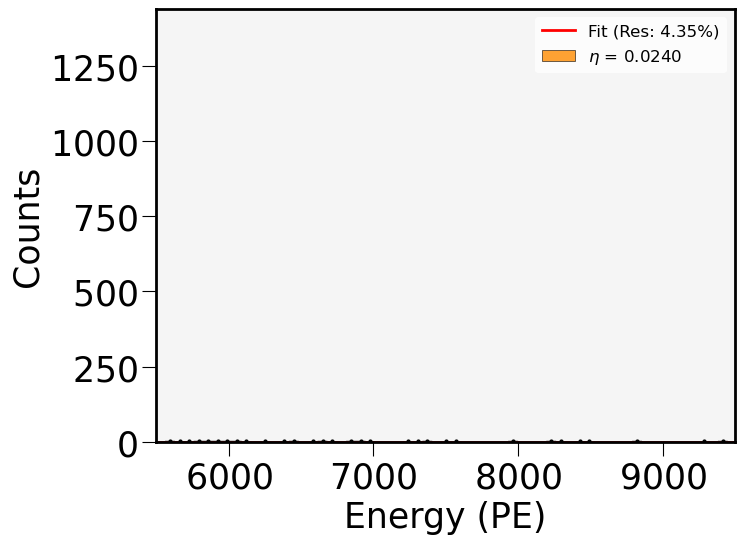


--- Processing η = 0.0245 ---
Initial values: [ 1328.   21027.42   268.98   453.   23112.05   268.98]
Final values: [ 1304.12 21063.91   390.03   430.61 22945.7    468.87]
Energy resolution (Peak 1): 4.36%


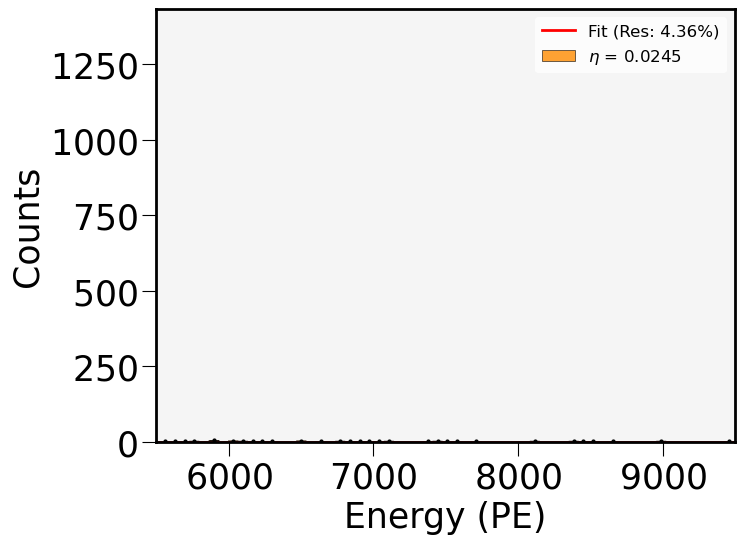


--- Processing η = 0.0250 ---
Initial values: [ 1313.   21438.18   274.42   457.   23496.34   274.42]
Final values: [ 1303.38 21471.09   398.18   430.37 23389.41   478.63]
Energy resolution (Peak 1): 4.37%


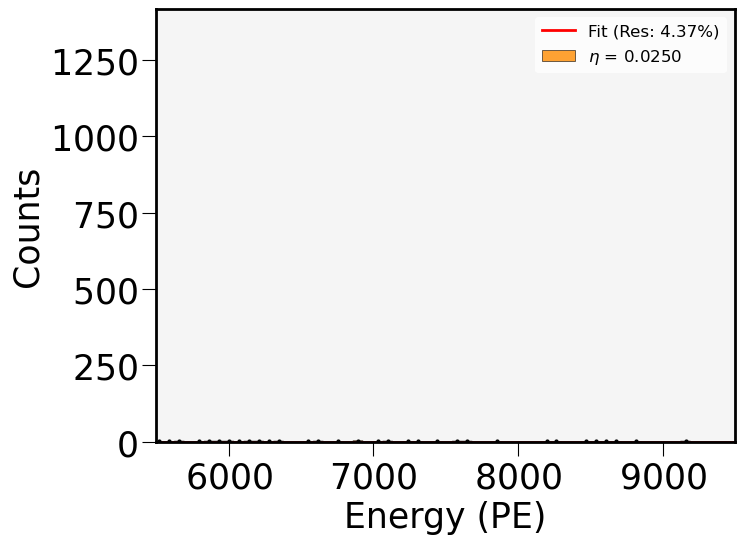

In [40]:
# Global
n_bins = 750

# Storage of the energy resolution values
E_resolution = []
eta_values = np.linspace(0, 0.025, 50)  # η variation

# Preliminary bounds for the fit
E_min = 1e3
E_max = 30e3

for eta in eta_values:

    print(f"\n--- Processing η = {eta:.4f} ---")

    # Variables
    data = ANA_DATA['High_Rn']['df']
    E1_corr = data['S1e_corr']
    E2_corr = data['S2e_corr']
    E_total = E1_corr + (E2_corr * eta)     # Energy estimator

    # Masking
    FV_mask = ANA_DATA['High_Rn']['FV_mask']
    E_mask  = E_total[FV_mask]

    # Histogram
    E_counts, E_edges = np.histogram(E_mask, bins=n_bins)
    bin_width = np.diff(E_edges).mean()

    # Compute representative values for the entire histogram
    E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_mask, E_edges)

    # 1. INVINCIBLE FIX: Apply both the E_min/E_max region AND the valid error filter simultaneously
    valid_mask = (y_errors > 0) & (E_centers >= E_min) & (E_centers <= E_max)
    x_fit = E_centers[valid_mask];  x_err_fit = x_errors[valid_mask]
    y_fit = E_values[valid_mask];   y_err_fit = y_errors[valid_mask]

    # Enough data for fit?
    if len(x_fit) < 6:
        print(f"Warning: Not enough data points in fit region for eta={eta}. Skipping.")
        E_resolution.append(np.nan)
        continue

    # Dynamic peak finding: find peaks in the y_fit data. We use prominence to ignore small noise bumps.
    peaks, _ = find_peaks(y_fit, distance=5, prominence=0.05 * y_fit.max())

    if len(peaks) >= 2:
        # Sort peaks by height (descending) to get the two most prominent ones
        top_peaks_idx = sorted(peaks, key=lambda i: y_fit[i], reverse=True)[:2]
        top_peaks_idx = sorted(top_peaks_idx)   # Sort by x-position: peak 1 is left, peak 2 is right
        
        mu1_guess = x_fit[top_peaks_idx[0]];    A1_guess  = y_fit[top_peaks_idx[0]]
        mu2_guess = x_fit[top_peaks_idx[1]];    A2_guess  = y_fit[top_peaks_idx[1]]
    else:
        print("Dynamic peak finding failed. Using analytical fallback guess.")
        mu1_guess = 1500 + (830e3 * eta);       A1_guess  = y_fit.max() / 2
        mu2_guess = 1750 + (930e3 * eta);       A2_guess  = y_fit.max() / 2

    sigma_guess = bin_width * 4
    p0 = [A1_guess, mu1_guess, sigma_guess, A2_guess, mu2_guess, sigma_guess]
    print(f'Initial values: {np.round(p0, 2)}')

    # We force sigma > 0.001 to guarantee it is strictly positive.
    lower_bounds = [0, E_min, 0.001, 0, E_min, 0.001]
    upper_bounds = [np.inf, E_max, np.inf, np.inf, E_max, np.inf]

    # --- Fit
    try:
        popt, pcov = curve_fit( crudo.ff.bigauss_func, x_fit, y_fit
                              , p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=10000 )
        
        # Ensure peak 1 is always the lower energy peak
        # curve_fit sometimes swaps the parameters. If mu1 > mu2, we swap them back.
        if popt[1] > popt[4]:
            popt = [popt[3], popt[4], popt[5], popt[0], popt[1], popt[2]]  
        print(f'Final values: {np.round(popt, 2)}') 
        
        # --- Energy Resolution
        FWHM = 2.355 * abs(popt[2]) 
        e_res = (FWHM / popt[1]) * 100
        E_resolution.append(e_res)
        print(f'Energy resolution (Peak 1): {e_res:.2f}%')

        fit_success = True

    except RuntimeError:
        print(f'Fit FAILED to converge for eta = {eta:.4f}')
        E_resolution.append(np.nan)
        popt = p0
        fit_success = False

    # ---Plotting
    plt.figure(figsize=(8, 6))

    plt.stairs(E_counts, E_edges, label=f'$\\eta$ = {eta:.4f}', 
               fill=True, color=crudo.pt.hist_colors[2], alpha=0.8, lw=0.5, ec='black')
    # Plot data points only for the valid fit region
    plt.errorbar(x_fit, y_fit, xerr=x_err_fit, yerr=y_err_fit, 
                 fmt='o', ms=2, c='black', ecolor='black', elinewidth=0.5)
    
    # Plot Fit line
    if fit_success:
        fit_y = crudo.ff.bigauss_func(E_centers, *popt)
        plt.plot(E_centers, fit_y, color="red", label=f"Fit (Res: {e_res:.2f}%)")
    else:
        # Plot the failed guess to debug
        guess_y = crudo.ff.bigauss_func(E_centers, *popt)
        plt.plot(E_centers, guess_y, color="orange", ls="--", label="Failed Guess")

    # Styling
    plt.xlabel('Energy (PE)')
    plt.xlim(5500, 9500)
    plt.ylabel('Counts')
    plt.legend(loc='best', fontsize=12)
    plt.gca().set_facecolor("whitesmoke")
    plt.tight_layout()
    plt.show()

#### What's the best $\eta$?

The minimum energy resolution is 3.88% at η = 0.0061


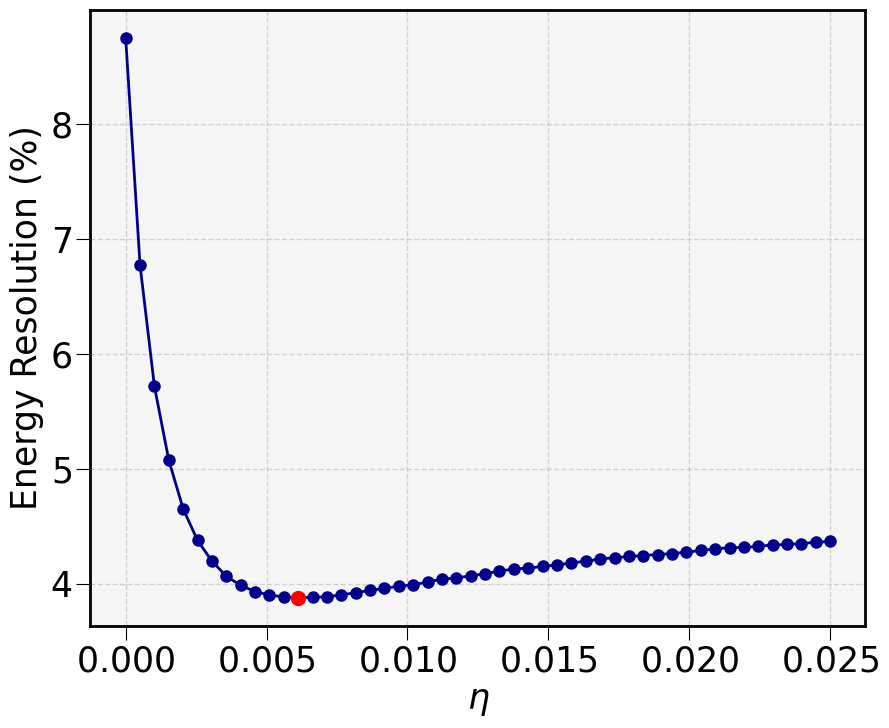

In [41]:
# Find the minimum energy resolution and corresponding eta value
min_index = np.argmin(E_resolution)
Best_eta = eta_values[min_index]
Best_res = E_resolution[min_index]

print(f"The minimum energy resolution is {Best_res:.2f}% at η = {Best_eta:.4f}")

# Store information
ANA_DATA['High_Rn']['eta_CV'] = Best_eta
ANA_DATA['Low_Rn']['eta_CV']  = Best_eta

# Plot
# plt.figure(figsize=(8, 6))
plt.plot(eta_values, E_resolution, c='darkblue', marker='o')
plt.scatter([Best_eta], [Best_res], c='red', zorder=3)
plt.xlabel('$\\eta$')
plt.ylabel('Energy Resolution (%)')
# plt.title('Weight Factor Determination')

plt.grid(True)
plt.gca().set_facecolor('whitesmoke')
plt.show()

## $\lambda$ Determination

### High-Rn

Dynamic Peak Finder: Found 222Rn peak near 6390 PE

High-Rn - Initial values:
222Rn: N_1 = 1128.00, μ_1 = 6390.18 PE, σ_1 = 45.37 PE

High-Rn - Fit values:
222Rn: N_1 = (1.07e+03 ± 1.04e+01), μ_1 = (6396.04 ± 0.85) PE, σ_1 = (107.75 ± 0.80) PE
222Rn: λ = 0.8740 keV/PE
χ² / ndof = 3.8509


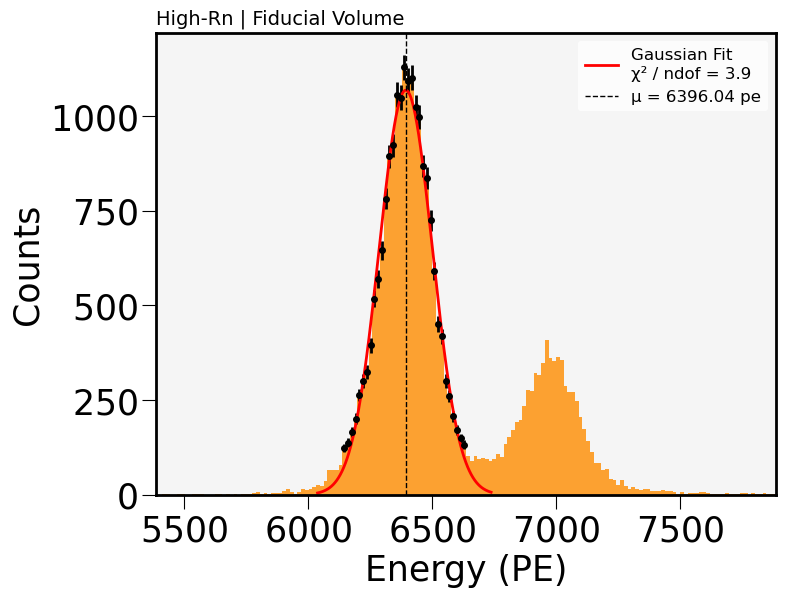

In [42]:
# Global
n_bins = 1000
E_Rn = 5590.3   # [keV] 222Rn energy peak

# High-Rn info
Rn_data = ANA_DATA['High_Rn']['df']
eta     = ANA_DATA['High_Rn']['eta_CV']

# Variables
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = E1_corr + (E2_corr * eta)  # Energy estimator

# Masking
FV_mask  = ANA_DATA['High_Rn']['FV_mask']
E_mask   = E_total[FV_mask]

# Histogram
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(0, E_total.max()))
bin_width = np.diff(E_edges).mean()
bin_centers = (E_edges[:-1] + E_edges[1:]) / 2

# Compute representative values for the ENTIRE histogram first
E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_mask, E_edges)

# --- Dynamic Peak Finding & Windowing
search_mask = (E_centers > 4000) & (y_errors > 0)
x_search = E_centers[search_mask]
y_search = E_values[search_mask]

peaks, _ = find_peaks(y_search, distance=5, prominence=0.05 * y_search.max())

if len(peaks) >= 1:
    top_peaks_idx = sorted(peaks, key=lambda i: y_search[i], reverse=True)[:2]
    left_peak_idx = sorted(top_peaks_idx)[0]
    
    mu_guess = x_search[left_peak_idx];     A_guess  = y_search[left_peak_idx]
    print(f"Dynamic Peak Finder: Found 222Rn peak near {mu_guess:.0f} PE")
else:
    print("Warning: Dynamic peak finding failed. Using fallback.")
    mu_guess = 6400;    A_guess  = 1500

sigma_guess = bin_width * 3

# Define dinamic fit window around the found peak
fit_window = 250 
E_min_fit = mu_guess - fit_window
E_max_fit = mu_guess + fit_window

# Filter data to fit
fit_region_mask = (E_centers >= E_min_fit) & (E_centers <= E_max_fit) & (y_errors > 0)
x_fit = E_centers[fit_region_mask]
y_fit = E_values[fit_region_mask]
y_err_fit = y_errors[fit_region_mask]

# --- Gaussian Fit

# Definte the cost function + initial guess using the dynamically found values
least_squares = LeastSquares(x_fit, y_fit, y_err_fit, crudo.ff.gauss_func)
init_guess    = [A_guess, mu_guess, sigma_guess]
print(f'\nHigh-Rn - Initial values:')
print(f"222Rn: N_1 = {init_guess[0]:.2f}, μ_1 = {init_guess[1]:.2f} PE, σ_1 = {init_guess[2]:.2f} PE")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2])

# Apply soft bounds to prevent negative sigma or crazy shifts
# Limit the mean to stay within our fit window, and force sigma to be positive
m.limits['mu1']    = (E_min_fit, E_max_fit)
m.limits['sigma1'] = (0.01, np.inf) 

# Minimization process
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'\nHigh-Rn - Fit values:')
print(f"222Rn: N_1 = ({popt[0]:.2e} ± {perr[0]:.2e}), μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) PE, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) PE")

# Lambda value (Calibration Constant)
High_lambda = E_Rn / popt[1]
print(f"222Rn: λ = {High_lambda:.4f} keV/PE")
ANA_DATA['High_Rn']['lambda_CV'] = High_lambda

# Reduced chi-square
chi2 = m.fval
ndof = len(x_fit) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data 
plt.bar(E_edges[:-1], E_counts, width=bin_width, align='edge',
        color=crudo.pt.hist_colors[2], alpha=0.8, lw=1.0)

plt.errorbar(x_fit, y_fit, yerr=y_err_fit, fmt='o', ms=4, c='black', ecolor='black')                                 

# Fit line
x_plot = np.linspace(E_min_fit - 100, E_max_fit + 100, 200)
y_plot = crudo.ff.gauss_func(x_plot, *popt)
plt.plot(x_plot, y_plot, color="red", lw=2.0, label=f'Gaussian Fit\nχ² / ndof = {chi2 / ndof:.1f}')

# Reference line
plt.axvline(x=popt[1], c='black', alpha=1, ls='--', lw=1.0, label=f'μ = {popt[1]:.2f} pe')

# Styling                      
plt.xlabel('Energy (PE)')
plt.xlim(mu_guess - 1e3, mu_guess + 1.5e3)
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'High-Rn | Fiducial Volume', fontsize=14, loc='left')
plt.legend(loc='upper right', fontsize=12)    
plt.gca().set_facecolor("whitesmoke")

plt.show()

### Low-Rn

Dynamic Peak Finder: Found 222Rn peak near 7094 PE

Low-Rn - Initial values:
222Rn: N_1 = 1299.00, μ_1 = 7093.93 PE, σ_1 = 130.16 PE

Low-Rn - Fit values:
222Rn: N_1 = (1.26e+03 ± 1.81e+01), μ_1 = (7102.58 ± 1.64) PE, σ_1 = (129.64 ± 1.78) PE
222Rn: λ = 0.7871 keV/PE
χ² / ndof = 1.8335


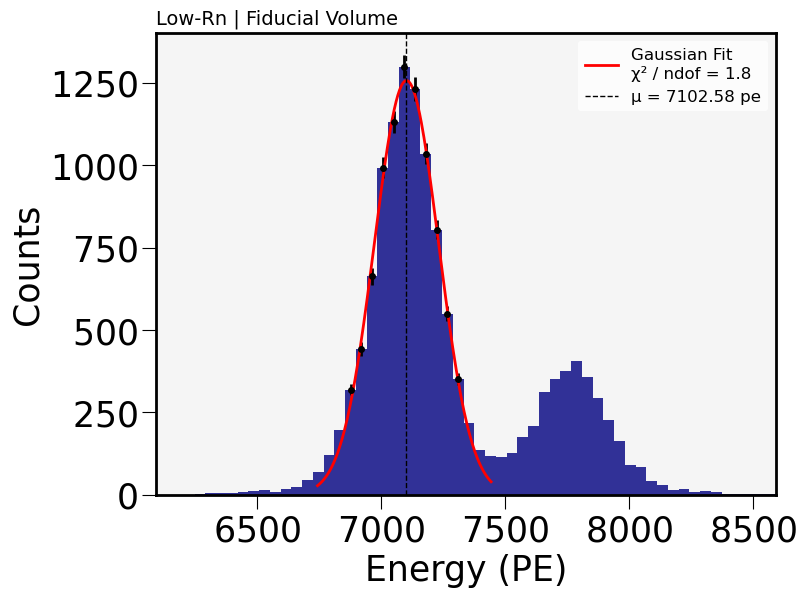

In [43]:
# Global
n_bins = 1000
E_Rn = 5590.3   # [keV] 222Rn energy peak

# High-Rn info
Rn_data = ANA_DATA['Low_Rn']['df']
eta     = ANA_DATA['Low_Rn']['eta_CV']

# Variables
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = E1_corr + (E2_corr * eta)  # Energy estimator

# Masking
FV_mask  = ANA_DATA['Low_Rn']['FV_mask']
E_mask   = E_total[FV_mask]

# Histogram
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(0, E_total.max()))
bin_width = np.diff(E_edges).mean()
bin_centers = (E_edges[:-1] + E_edges[1:]) / 2

# Compute representative values for the ENTIRE histogram first
E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_mask, E_edges)

# --- Dynamic Peak Finding & Windowing
search_mask = (E_centers > 4000) & (y_errors > 0)
x_search = E_centers[search_mask]
y_search = E_values[search_mask]

peaks, _ = find_peaks(y_search, distance=5, prominence=0.05 * y_search.max())

if len(peaks) >= 1:
    top_peaks_idx = sorted(peaks, key=lambda i: y_search[i], reverse=True)[:2]
    left_peak_idx = sorted(top_peaks_idx)[0]
    
    mu_guess = x_search[left_peak_idx];     A_guess  = y_search[left_peak_idx]
    print(f"Dynamic Peak Finder: Found 222Rn peak near {mu_guess:.0f} PE")
else:
    print("Warning: Dynamic peak finding failed. Using fallback.")
    mu_guess = 6400;    A_guess  = 1500

sigma_guess = bin_width * 3

# Define dinamic fit window around the found peak
fit_window = 250 
E_min_fit = mu_guess - fit_window
E_max_fit = mu_guess + fit_window

# Filter data to fit
fit_region_mask = (E_centers >= E_min_fit) & (E_centers <= E_max_fit) & (y_errors > 0)
x_fit = E_centers[fit_region_mask]
y_fit = E_values[fit_region_mask]
y_err_fit = y_errors[fit_region_mask]

# --- Gaussian Fit

# Definte the cost function + initial guess using the dynamically found values
least_squares = LeastSquares(x_fit, y_fit, y_err_fit, crudo.ff.gauss_func)
init_guess    = [A_guess, mu_guess, sigma_guess]
print(f'\nLow-Rn - Initial values:')
print(f"222Rn: N_1 = {init_guess[0]:.2f}, μ_1 = {init_guess[1]:.2f} PE, σ_1 = {init_guess[2]:.2f} PE")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2])

# Apply soft bounds to prevent negative sigma or crazy shifts
# Limit the mean to stay within our fit window, and force sigma to be positive
m.limits['mu1']    = (E_min_fit, E_max_fit)
m.limits['sigma1'] = (0.01, np.inf) 

# Minimization process
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'\nLow-Rn - Fit values:')
print(f"222Rn: N_1 = ({popt[0]:.2e} ± {perr[0]:.2e}), μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) PE, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) PE")

# Lambda value (Calibration Constant)
High_lambda = E_Rn / popt[1]
print(f"222Rn: λ = {High_lambda:.4f} keV/PE")
ANA_DATA['Low_Rn']['lambda_CV'] = High_lambda

# Reduced chi-square
chi2 = m.fval
ndof = len(x_fit) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data 
plt.bar(E_edges[:-1], E_counts, width=bin_width, align='edge',
        color=crudo.pt.hist_colors[5], alpha=0.8, lw=1.0)

plt.errorbar(x_fit, y_fit, yerr=y_err_fit, fmt='o', ms=4, c='black', ecolor='black')                                 

# Fit line
x_plot = np.linspace(E_min_fit - 100, E_max_fit + 100, 200)
y_plot = crudo.ff.gauss_func(x_plot, *popt)
plt.plot(x_plot, y_plot, color="red", lw=2.0, label=f'Gaussian Fit\nχ² / ndof = {chi2 / ndof:.1f}')

# Reference line
plt.axvline(x=popt[1], c='black', alpha=1, ls='--', lw=1.0, label=f'μ = {popt[1]:.2f} pe')

# Styling                      
plt.xlabel('Energy (PE)')
plt.xlim(mu_guess - 1e3, mu_guess + 1.5e3)
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Low-Rn | Fiducial Volume', fontsize=14, loc='left')
plt.legend(loc='upper right', fontsize=12)    
plt.gca().set_facecolor("whitesmoke")

plt.show()

# α-Producing Isotopes

### Configuration

In [44]:
# Choose your period of interest
PERIOD = 'Low_Rn'   # 'High_Rn' or 'Low_Rn'

# ----- Period Information ----- #
# Data information
Rn_data             = ANA_DATA[PERIOD]['df']
Rn_long             = ANA_DATA[PERIOD]['duration_CV']
Alpha_rate_CV       = ANA_DATA[PERIOD]['alpha_rate_CV']
Alpha_rate_err_stat = ANA_DATA[PERIOD]['alpha_rate_err_stat']
Alpha_rate_err_sys  = ANA_DATA[PERIOD]['alpha_rate_err_sys']

# Fiducial volume
FV_mask       = ANA_DATA[PERIOD]['FV_mask']
DT_stop_CV    = ANA_DATA[PERIOD]['DTstop_CV']
DT_stop_err   = ANA_DATA[PERIOD]['DTstop_err']
Drift_vel_CV  = ANA_DATA[PERIOD]['drift_vel_CV']
Drift_vel_err = ANA_DATA[PERIOD]['drift_vel_err']

# Energy Estimator
Eta_CV        = ANA_DATA[PERIOD]['eta_CV']
Lambda_CV     = ANA_DATA[PERIOD]['lambda_CV']

### Histogram

In [45]:
print(f'{PERIOD}:')
# Global
n_bins = 250

# S2 width check!
W2 = Rn_data['S2w']
print(f'\n--- These data has a min S2w of {W2.min()} μs ---')

# Variables
R = Rn_data['R']
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = Lambda_CV * (E1_corr + (E2_corr * Eta_CV))        # Energy estimator

# Masking
E_mask = E_total[FV_mask]

# Histogram: normalized by corrected DAQ data taking time
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(E_mask.min(), E_mask.max()))
E_rate  = E_counts / Rn_long
E_error = np.sqrt(E_counts) / Rn_long       # Only statistical error
bin_width = np.diff(E_edges).mean()

# ----- Selection Rate ----- #
sel_rate_CV  = np.sum(E_rate)                       
sel_rate_err = np.sqrt(np.sum(E_error**2))
print(f'\n Energy window  = [{E_mask.min():.2f}, {E_mask.max():.2f}] keV\n Selection rate = ({sel_rate_CV*1e3:.4f} ± {sel_rate_err*1e3:.4f}) mHz')

Low_Rn:

--- These data has a min S2w of 50.025 μs ---

 Energy window  = [585.86, 10419.86] keV
 Selection rate = (49.3186 ± 0.4233) mHz


### Tri-Gaussian Fit

In [46]:
# Filter the data for the fit
fit_region_mask = (E_mask >= E_min) & (E_mask <= E_max)
E_fit = E_mask[fit_region_mask]

# Compute representative values for the fit: remember, we're working with rates!
x_centers, x_errors, y_values, y_errors = crudo.ff.prefit_1D(E_mask, bins=E_edges)
y_values = y_values.astype(np.float64)      # We divide by a float: Rn_long
y_values /= Rn_long
y_errors /= Rn_long

# Filter out poitns with zero error
valid_points = y_errors > 0
x_centers = x_centers[valid_points];    x_errors = x_errors[valid_points]
y_values  = y_values[valid_points];     y_errors = y_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(x_centers, y_values, y_errors, crudo.ff.trigauss_func)
init_guess    = [1, 5600, bin_width, 1, 6100, bin_width, 1, 7850, bin_width]
print(f'{PERIOD} - Initial values:\n')
print(f"222Rn: N_1 = {init_guess[0]:.2f} Hz, μ_1 = {init_guess[1]:.2f} keV, σ_1 = {init_guess[2]:.2f} keV")
print(f"218Po: N_2 = {init_guess[3]:.2f} Hz, μ_2 = {init_guess[4]:.2f} keV, σ_2 = {init_guess[5]:.2f} keV")
print(f"214Po: N_3 = {init_guess[6]:.2f} Hz, μ_3 = {init_guess[7]:.2f} keV, σ_3 = {init_guess[8]:.2f} keV\n")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2],
                          A2=init_guess[3], mu2=init_guess[4], sigma2=init_guess[5],
                          A3=init_guess[6], mu3=init_guess[7], sigma3=init_guess[8])

# Apply soft bounds to the parameters
m.limits['mu1'] = (5400, 5800);  m.limits['sigma1'] = (0.5*bin_width, np.inf)
m.limits['mu2'] = (5900, 6300);  m.limits['sigma2'] = (0.5*bin_width, np.inf)
m.limits['mu3'] = (7550, 8150);  m.limits['sigma3'] = (0.5*bin_width, 1000 if PERIOD == 'Low_Rn' else np.inf)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'{PERIOD} - Fit values:\n')
print(f"222Rn: N_1 = ({popt[0]:.4e} ± {perr[0]:.4e}) Hz, μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) keV, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) keV")
print(f"218Po: N_2 = ({popt[3]:.4e} ± {perr[3]:.4e}) Hz, μ_2 = ({popt[4]:.2f} ± {perr[4]:.2f}) keV, σ_2 = ({popt[5]:.2f} ± {perr[5]:.2f}) keV")
print(f"214Po: N_3 = ({popt[6]:.4e} ± {perr[6]:.4e}) Hz, μ_3 = ({popt[7]:.2f} ± {perr[7]:.2f}) keV, σ_3 = ({popt[8]:.2f} ± {perr[8]:.2f}) keV")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Store Fit Results ----- #
Isotopes = {name: {key: val for key, val in zip(['N_CV', 'mu_CV', 'sigma_CV', 'N_err', 'mu_err', 'sigma_err'], popt[i:i+3] + perr[i:i+3])} 
            for i, name in zip(range(0, 9, 3), ['222Rn', '218Po', '214Po'])}
ANA_DATA[PERIOD]['Isotopes'] = Isotopes

Low_Rn - Initial values:

222Rn: N_1 = 1.00 Hz, μ_1 = 5600.00 keV, σ_1 = 39.34 keV
218Po: N_2 = 1.00 Hz, μ_2 = 6100.00 keV, σ_2 = 39.34 keV
214Po: N_3 = 1.00 Hz, μ_3 = 7850.00 keV, σ_3 = 39.34 keV

Low_Rn - Fit values:

222Rn: N_1 = (5.0149e-03 ± 6.9376e-05) Hz, μ_1 = (5587.53 ± 1.18) keV, σ_1 = (109.13 ± 1.10) keV
218Po: N_2 = (1.5560e-03 ± 3.6573e-05) Hz, μ_2 = (6110.90 ± 2.46) keV, σ_2 = (125.58 ± 2.37) keV
214Po: N_3 = (1.2911e-05 ± 4.6724e-06) Hz, μ_3 = (7841.77 ± 51.81) keV, σ_3 = (256.37 ± 143.70) keV
χ² / ndof = 3.7460


### Rn Activity

In [47]:
print(f'{PERIOD} Results:\n')
# Compute the integral of each gaussian + error
Fit_Rates   = {"222Rn": {"CV": 0.0, "Error": 0.0}, "218Po": {"CV": 0.0, "Error": 0.0}, "214Po": {"CV": 0.0, "Error": 0.0}}
Proportions = {"222Rn": {"CV": 0.0, "Error": 0.0}, "218Po": {"CV": 0.0, "Error": 0.0}, "214Po": {"CV": 0.0, "Error": 0.0}}
param_name_list = [['A1', 'mu1', 'sigma1'], ['A2', 'mu2', 'sigma2'], ['A3', 'mu3', 'sigma3']]

total_fit_rate_CV  = 0.0
total_fit_rate_err = 0.0
for i, (isotope, values) in enumerate(ANA_DATA[PERIOD]['Isotopes'].items()):

    print(f'Computing integral for {isotope}:')
    # Fit parameters name to use Minuit object
    param_names  = param_name_list[i]
    # Intregate within selected energy window
    integral_CV, integral_err = crudo.ff.gauss_int_err(values['N_CV'], values['mu_CV'], values['sigma_CV'], E_mask.min(), E_mask.max(), 
                                                 param_names, minuit_object=m)
    # IT'S AN AREA (Hz*keV): divide by bin width to get rate
    fit_rate_CV  = integral_CV / bin_width
    fit_rate_err = integral_err / bin_width
    Fit_Rates[isotope]['CV']    = fit_rate_CV
    Fit_Rates[isotope]['Error'] = fit_rate_err
    print(f"  Fit rate: R = ({fit_rate_CV*1e3:.5f} ± {fit_rate_err*1e3:.5f}) mHz")
    # Total fit rate
    total_fit_rate_CV  += fit_rate_CV
    total_fit_rate_err += fit_rate_err**2

    # Compute the proportions
    if isotope == '222Rn':
        rate_222_CV = fit_rate_CV;  rate_222_err = fit_rate_err      # For each isotope wrt 222Rn
        # Rn Fraction wrt Selection Rate
        Rn_Fraction_CV  = fit_rate_CV / sel_rate_CV
        Rn_Fraction_err = Rn_Fraction_CV * np.sqrt((fit_rate_err / fit_rate_CV)**2 + (sel_rate_err / sel_rate_CV)**2)
        print(f"  Fraction wrt sel. rate: F = {Rn_Fraction_CV:.4f} ± {Rn_Fraction_err:.4f}")

    # Store proportions
    Proportions[isotope]['CV']    = fit_rate_CV / rate_222_CV
    Proportions[isotope]['Error'] = Proportions[isotope]['CV'] * np.sqrt((fit_rate_err / fit_rate_CV)**2 + (rate_222_err / rate_222_CV)**2)
    print(f"  Proportion wrt 222Rn fit rate: α = {Proportions[isotope]['CV']:.4f} ± {Proportions[isotope]['Error']:.4f}")

# ----- Total Fit Rate ----- #
print(f"Total fit rate = ({total_fit_rate_CV*1e3:.4f} ± {np.sqrt(total_fit_rate_err)*1e3:.4f}) mHz")

# ----- 222Rn Total Rate ----- #
print(f"\nAlpha trigger rate = {Alpha_rate_CV:.4f} ± {Alpha_rate_err_stat:.4f} Hz")
Rn_rate_CV  = Alpha_rate_CV * Rn_Fraction_CV
Rn_rate_err = Rn_rate_CV * np.sqrt((Alpha_rate_err_stat / Alpha_rate_CV)**2 + (Rn_Fraction_err / Rn_Fraction_CV)**2)
print(f"222Rn trigger rate = {Rn_rate_CV:.4f} ± {Rn_rate_err:.4f} Hz")

# ----- 222Rn Activity ----- #
# Active volume (aka Drift Region)
print(f"\nActive volume = {DRIFT_VOLUME:.4f} m³")
# Total volume (aka TPC volume)
TPC_VOLUME = EL_GAP_VOLUME + DRIFT_VOLUME + BUFFER_VOLUME
VOL_PROP = TPC_VOLUME / DRIFT_VOLUME
print(f"TPC volume = {TPC_VOLUME:.4f} m³")
print(f"Volume proportion: TPC / AV = {VOL_PROP:.4f}")

# Compute the activity in Bq/m³
Rn_activity_CV  = Rn_rate_CV / DRIFT_VOLUME
Rn_activity_err = Rn_rate_err / DRIFT_VOLUME
print(f"\n222Rn activity = {Rn_activity_CV:.4f} ± {Rn_activity_err:.4f} Bq / m³")

Low_Rn Results:

Computing integral for 222Rn:
  Fit rate: R = (34.87445 ± 0.36119) mHz
  Fraction wrt sel. rate: F = 0.7071 ± 0.0095
  Proportion wrt 222Rn fit rate: α = 1.0000 ± 0.0146
Computing integral for 218Po:
  Fit rate: R = (12.45202 ± 0.22137) mHz
  Proportion wrt 222Rn fit rate: α = 0.3571 ± 0.0073
Computing integral for 214Po:
  Fit rate: R = (0.21093 ± 0.05999) mHz
  Proportion wrt 222Rn fit rate: α = 0.0060 ± 0.0017
Total fit rate = (47.5374 ± 0.4279) mHz

Alpha trigger rate = 1.1896 ± 0.0526 Hz
222Rn trigger rate = 0.8412 ± 0.0389 Hz

Active volume = 0.9014 m³
TPC volume = 1.0936 m³
Volume proportion: TPC / AV = 1.2133

222Rn activity = 0.9332 ± 0.0432 Bq / m³


### Bi @ Active Volume

In [48]:
Rn222_rate = Fit_Rates['222Rn']['CV'];      Rn222_rate_err = Fit_Rates['222Rn']['Error']
Po218_rate = Fit_Rates['218Po']['CV'];      Po218_rate_err = Fit_Rates['218Po']['Error']
Po214_rate = Fit_Rates['214Po']['CV'];      Po214_rate_err = Fit_Rates['214Po']['Error']

In [49]:
F_214_218_CV  = Po214_rate / Po218_rate
F_214_218_err = F_214_218_CV * np.sqrt((Po214_rate_err / Po214_rate)**2 + (Po218_rate_err / Po218_rate)**2)
print(f"\n218Po to 214Po fit rate fraction = {F_214_218_CV:.4f} ± {F_214_218_err:.4f}")

F_218_222_CV  = Po218_rate / Rn222_rate
F_218_222_err = F_218_222_CV * np.sqrt((Po218_rate_err / Po218_rate)**2 + (Rn222_rate_err / Rn222_rate)**2)
print(f"222Rn to 218Po fit rate fraction = {F_218_222_CV:.4f} ± {F_218_222_err:.4f}")

# Bi activity in active volume
Bi_CV = F_214_218_CV / F_218_222_CV
Bi_err = Bi_CV * np.sqrt((F_214_218_err / F_214_218_CV)**2 + (F_218_222_err / F_218_222_CV)**2)
print(f"Bi fraction in active volume: {Bi_CV:.4%} ± {Bi_err:.4%}")


218Po to 214Po fit rate fraction = 0.0169 ± 0.0048
222Rn to 218Po fit rate fraction = 0.3571 ± 0.0073
Bi fraction in active volume: 4.7443% ± 1.3553%


### Bi @ Cathode

In [50]:
frac_cathode_CV  = (1 - Bi_CV)
frac_cathode_err = Bi_err
print(f"\nBi fraction at cathode: {frac_cathode_CV:.2%} ± {frac_cathode_err:.4%}")

# Bi rate @ cathode
Bi_rate_CV  = Rn_rate_CV * frac_cathode_CV
Bi_rate_err = Bi_rate_CV * np.sqrt((Rn_rate_err / Rn_rate_CV)**2 + (frac_cathode_err / frac_cathode_CV)**2)
print(f"Bi rate @ cathode = {Bi_rate_CV:.4f} ± {Bi_rate_err:.4f} Hz")

# Total Bi rate @ cathode
Bi_rate_final_CV  = Bi_rate_CV * VOL_PROP
Bi_rate_final_err = Bi_rate_err * VOL_PROP
print(f"Bi rate @ cathode + EL/Buffer contribution = {Bi_rate_final_CV:.4f} ± {Bi_rate_final_err:.4f} Hz")

# ---
Bi_EL_buffer_CV  = Bi_rate_final_CV - Bi_rate_CV
Bi_EL_buffer_err = np.sqrt(Bi_rate_final_err**2 + Bi_rate_err**2)
print(f"Bi rate contribution from EL and Buffer = {Bi_EL_buffer_CV:.4f} ± {Bi_EL_buffer_err:.4f} Hz")


Bi fraction at cathode: 95.26% ± 1.3553%
Bi rate @ cathode = 0.8013 ± 0.0388 Hz
Bi rate @ cathode + EL/Buffer contribution = 0.9722 ± 0.0470 Hz
Bi rate contribution from EL and Buffer = 0.1709 ± 0.0609 Hz


### Plot

In [51]:
Rn222_perc = Proportions['222Rn']['CV']
Po218_perc = Proportions['218Po']['CV']
Po214_perc = Proportions['214Po']['CV']

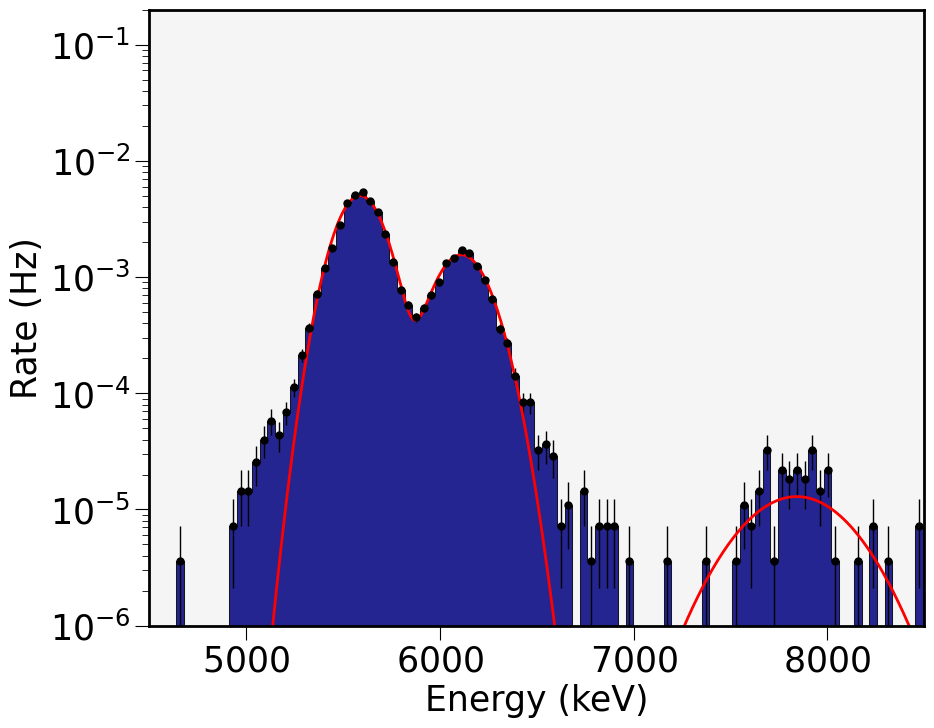

In [52]:
# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
color_hist = crudo.pt.hist_colors[2] if PERIOD == 'High_Rn' else crudo.pt.hist_colors[5]
plt.stairs(E_rate, E_edges, fill=True, color=color_hist, alpha=0.85, ec='black', lw=0.75)

# Fit
x_fit = np.linspace(x_centers.min(), x_centers.max(), 1000)
y_fit = crudo.ff.trigauss_func(x_fit, *popt)
plt.plot(x_fit, y_fit, color="red", label=f"Tri-Gaussian Fit\nχ² / ndof = {chi2 / ndof:.2f}")
plt.errorbar(x_centers, y_values, xerr=x_errors, yerr=y_errors, fmt='o', c='black', ms=5, ecolor='black', elinewidth=1.0)

# ----- Styling ----- #
# # Important text
# y_text = [1.75e-1, 1e-1, 3.5e-2, 1.75e-3] if PERIOD == 'High_Rn' else [1.25e-2, 6e-3, 1.75e-3, 4e-5]
# plt.text(8.40e3, y_text[0], r'A($^{222}$Rn)'f' = ({Rn_activity_CV:.2f} ± {Rn_activity_err:.2f}) Bq / m³', va='center', ha='right')
# plt.text(5590, y_text[1], r'$^{222}$Rn'f' ({Rn222_perc:.1%})', va='bottom', ha='center')
# plt.text(6115, y_text[2], r'$^{218}$Po'f' ({Po218_perc:.1%})', va='bottom', ha='center')
# plt.text(7834, y_text[3], r'$^{214}$Po'f' ({Po214_perc:.1%})', va='bottom', ha='center')

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (E_max, E_rate.max())
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(-85, 50 if PERIOD == 'High_Rn' else 60), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (keV)')
plt.xlim(4.5e3, 8.5e3)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-6, 2e-1)
# plt.ylim(y_values.min()-(y_errors.min()/2), 2e-1 if PERIOD == 'High_Rn' else 2e-1)
plt.yscale('log')
# plt.title(f'{PERIOD} (AV)')   
# plt.legend(loc='upper right')

plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Radon_LPR/images/{PERIOD}_Energy.pdf')
# plt.savefig(f'/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/{PERIOD}_Energy.pdf')
plt.show()